Metadata columns: ['Number', 'Cell', 'Slice', 'Date', 'Sample', 'Mouse', 'Mouse date of birth', 'Mouse age', 'Mouse gender', 'Mouse genotype', 'Targeted layer', 'Inferred layer', 'Cre', 'Exon reads', 'Intron reads', 'Intergenic reads', 'Sequencing batch', 'Number of genes detected', 'RNA family', 'RNA type', 'RNA type confidence', 'RNA type top-3', 'ALM/VISp top-3', 'Length (bp)', 'Yield (pg/µl)', 'User', 'Hold Time (min)', 'Soma depth (µm)', 'Soma depth (4x)', 'Cortical thickness (4x)', 'Cortical thickness (µm)', 'Traced', 'Exclusion reasons']
Using RNA family column: RNA family

=== RNA family distribution (neuron types) ===
             count  percent
RNA family                 
Pvalb          289    21.75
Sst            272    20.47
IT             254    19.11
Vip            153    11.51
CT             106     7.98
low quality     97     7.30
Lamp5           91     6.85
ET              49     3.69
Sncg            13     0.98
NP               5     0.38

Saved distribution to: rna_f

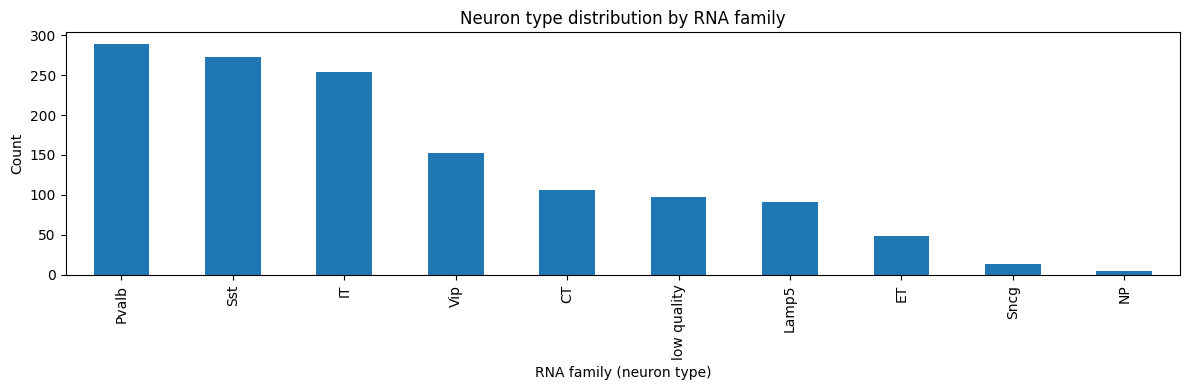

In [ ]:
import pandas as pd

# ---------------------------------------------
# 1) Load RNA metadata
# (Use ONE of these paths depending on your environment)
META_PATH = "/content/m1_patchseq_meta_data (1).csv"      # Colab
# META_PATH = "/mnt/data/m1_patchseq_meta_data (1).csv"   # Local (this chat environment)

meta = pd.read_csv(META_PATH, sep="\t")
print("Metadata columns:", list(meta.columns))

# ---------------------------------------------
# 2) Ensure short_id exists (old scripts used 'Cell')
if "Cell" not in meta.columns and "short_id" not in meta.columns:
    raise ValueError("Metadata must contain either 'Cell' or 'short_id' column.")

if "short_id" not in meta.columns:
    meta = meta.rename(columns={"Cell": "short_id"})

meta["short_id"] = meta["short_id"].astype(str).str.strip()

# ---------------------------------------------
# 3) Find RNA family column robustly
rna_family_col = None
for c in meta.columns:
    if c.strip().lower().replace(" ", "").replace("_", "") == "rnafamily":
        rna_family_col = c
        break

if rna_family_col is None:
    # fallback: try partial match
    candidates = [c for c in meta.columns if "rna" in c.lower() and "family" in c.lower()]
    if len(candidates) == 1:
        rna_family_col = candidates[0]
    else:
        raise ValueError(f"Could not uniquely find RNA family column. Candidates: {candidates}")

print("Using RNA family column:", rna_family_col)

# ---------------------------------------------
# 4) Distribution (counts + percentages)
meta[rna_family_col] = meta[rna_family_col].astype(str).str.strip()

dist_counts = meta[rna_family_col].value_counts(dropna=False)
dist_percent = (dist_counts / dist_counts.sum() * 100).round(2)

dist_df = pd.DataFrame({
    "count": dist_counts,
    "percent": dist_percent
})

print("\n=== RNA family distribution (neuron types) ===")
print(dist_df)

# ---------------------------------------------
# 5) Optional: save as CSV
out_path = "rna_family_distribution.csv"
dist_df.to_csv(out_path)
print(f"\nSaved distribution to: {out_path}")

# ---------------------------------------------
# 6) Optional: plot (works in notebooks)
try:
    import matplotlib.pyplot as plt

    ax = dist_counts.plot(kind="bar", figsize=(12, 4))
    ax.set_xlabel("RNA family (neuron type)")
    ax.set_ylabel("Count")
    ax.set_title("Neuron type distribution by RNA family")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Plotting skipped (matplotlib not available or backend issue):", e)


In [1]:
!pip install dandi

# Download the entire dataset into the Colab environment
!dandi download DANDI:000008/0.211014.0809 --output-dir /content/dandi_000008

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.9/370.9 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.0/70.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━

In [2]:
!mkdir -p /content/dandi_000008
!dandi download DANDI:000008/0.211014.0809 --output-dir /content/dandi_000008

PATH                                                                                                                      SIZE      DONE            DONE% CHECKSUM STATUS          MESSAGE   
000008/dandiset.yaml                                                                                                                                               done            updated   
000008/sub-mouse-AAYYT/sub-mouse-AAYYT_ses-20180420-sample-2_slice-20180420-slice-2_cell-20180420-sample-2_icephys.nwb    9.3 MB    9.3 MB           100%    ok    done                      
000008/sub-mouse-AAYYT/sub-mouse-AAYYT_ses-20180420-sample-3_slice-20180420-slice-3_cell-20180420-sample-3_icephys.nwb    9.3 MB    9.3 MB           100%    ok    done                      
000008/sub-mouse-AAYYT/sub-mouse-AAYYT_ses-20180420-sample-4_slice-20180420-slice-4_cell-20180420-sample-4_icephys.nwb    9.5 MB    9.5 MB           100%    ok    done                      
000008/sub-mouse-AEJGZ/sub-mouse-AEJGZ_ses-2018031

In [3]:
import os
import h5py
import numpy as np
import pandas as pd

ROOT = "/content/dandi_000008"
SWEEP_IDX = 20
SWEEP_NAME = f"CurrentClampSeries{SWEEP_IDX:03d}"

# ---------- 1) Find all NWB files ----------
nwb_files = []
for dirpath, dirnames, filenames in os.walk(ROOT):
    for fn in filenames:
        if fn.endswith(".nwb"):
            nwb_files.append(os.path.join(dirpath, fn))

print(f"Found {len(nwb_files)} NWB files")

# ---------- 2) Collect traces for this sweep + lengths ----------
traces = []
cell_names = []
lengths = []

for fp in nwb_files:
    try:
        f = h5py.File(fp, "r")
    except Exception as e:
        print("Error opening", fp, ":", e)
        continue

    acq = f.get("acquisition", None)
    if acq is None or SWEEP_NAME not in acq:
        f.close()
        continue

    v = acq[SWEEP_NAME]["data"][:]       # 1D voltage trace
    traces.append(v)
    lengths.append(len(v))

    cell_id = os.path.basename(fp).replace(".nwb", "")
    cell_names.append(f"{cell_id}_sweep{SWEEP_IDX}")

    f.close()

print(f"Cells with sweep {SWEEP_IDX}: {len(traces)}")
if len(traces) == 0:
    raise RuntimeError("No cells had this sweep, check SWEEP_IDX or paths.")

lengths = np.array(lengths)

# ---------- 3) Find the most common length (mode) ----------
# Count how many cells have each length
unique_lengths, counts = np.unique(lengths, return_counts=True)
mode_idx = np.argmax(counts)
L_mode = unique_lengths[mode_idx]
n_mode = counts[mode_idx]

print("All unique lengths and counts:")
for L, c in zip(unique_lengths, counts):
    print(f"  length {L}: {c} cells")
print(f"\nUsing most common length L_mode = {L_mode} (cells = {n_mode})")

# ---------- 4) Keep only cells with length == L_mode ----------
selected_indices = [i for i, L in enumerate(lengths) if L == L_mode]

traces_sel = [traces[i] for i in selected_indices]
names_sel  = [cell_names[i] for i in selected_indices]

print(f"Selected {len(traces_sel)} cells with length {L_mode}")

# Stack into array (N_cells_mode, L_mode)
traces_arr = np.stack(traces_sel, axis=0).astype(np.float32)   # (N_cells_mode, L_mode)

# ---------- 5) Build DataFrame in WST format ----------
# rows = time samples, columns = cells → shape (L_mode, N_cells_mode)
traces_arr_T = traces_arr.T   # (L_mode, N_cells_mode)

t_vec = np.arange(L_mode)
df = pd.DataFrame(traces_arr_T, index=t_vec, columns=names_sel)
df.index.name = "time"

CSV_PATH = "voltage___traces2345.csv"
df.to_csv(CSV_PATH)
print("✅ Saved:", CSV_PATH, "with shape", df.shape)


Found 1328 NWB files
Cells with sweep 20: 1328
All unique lengths and counts:
  length 22500: 538 cells
  length 25000: 790 cells

Using most common length L_mode = 25000 (cells = 790)
Selected 790 cells with length 25000
✅ Saved: voltage___traces2345.csv with shape (25000, 790)


In [5]:
!pip install kymatio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 5.9 MB/s eta 0:00:00


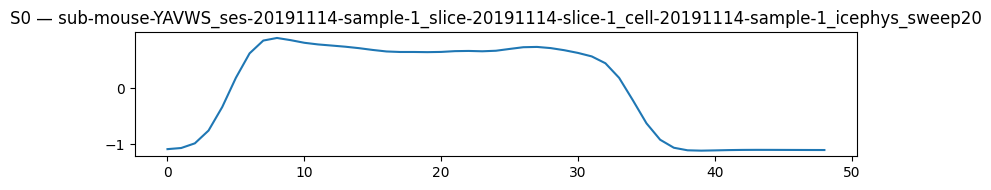

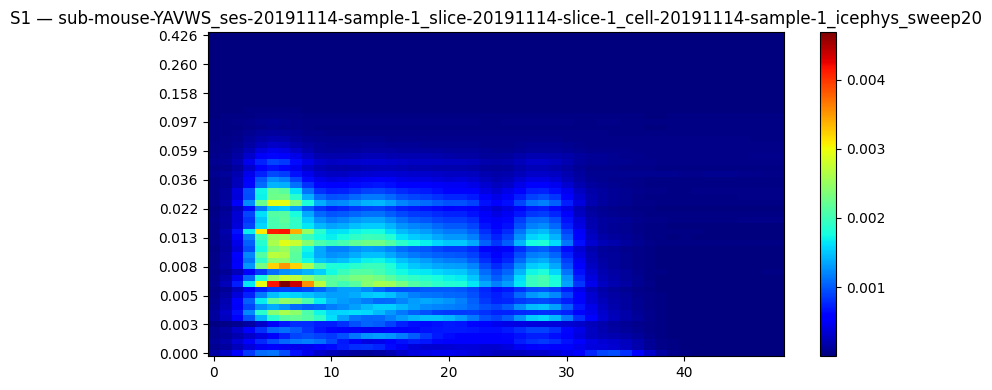

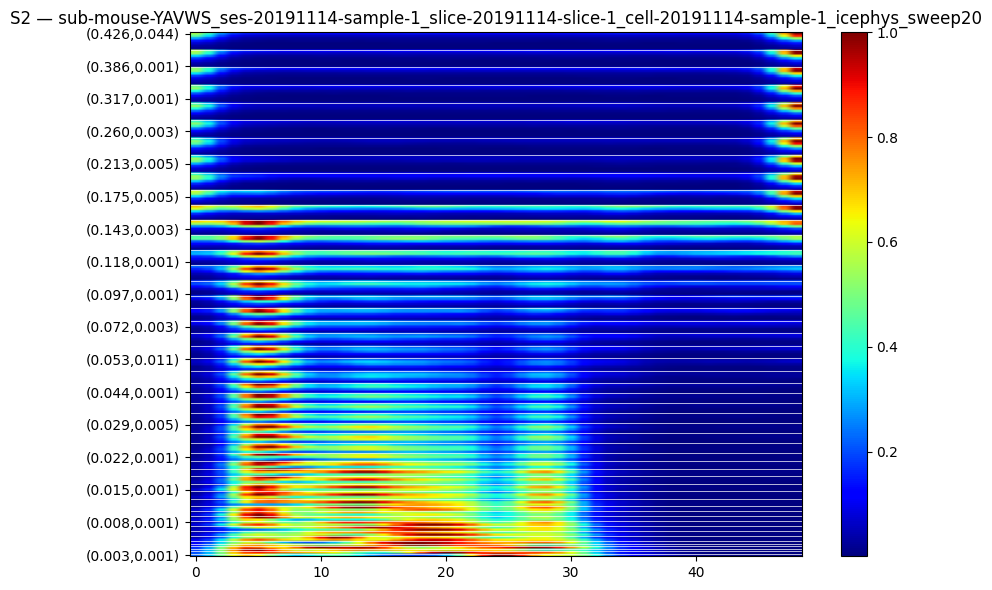

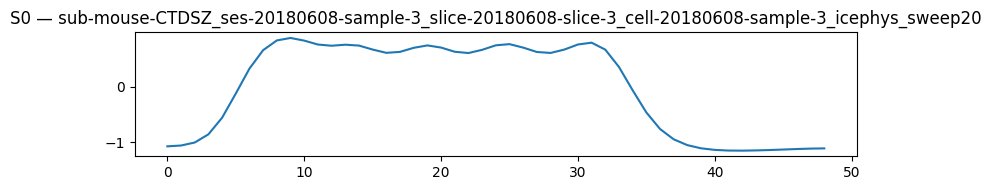

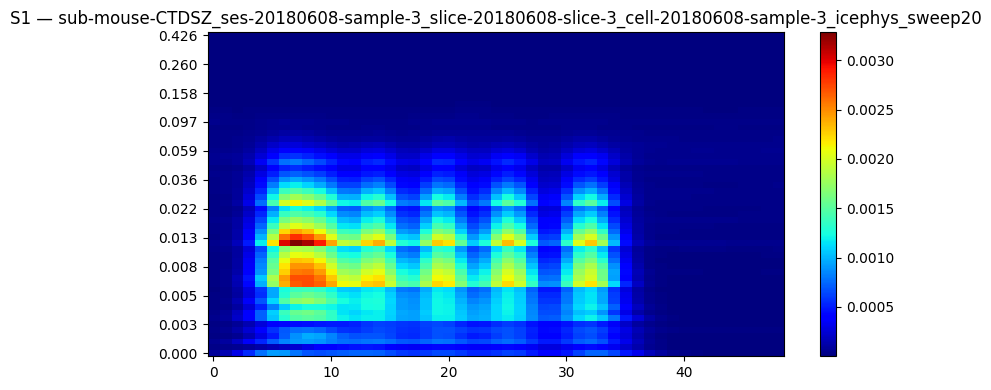

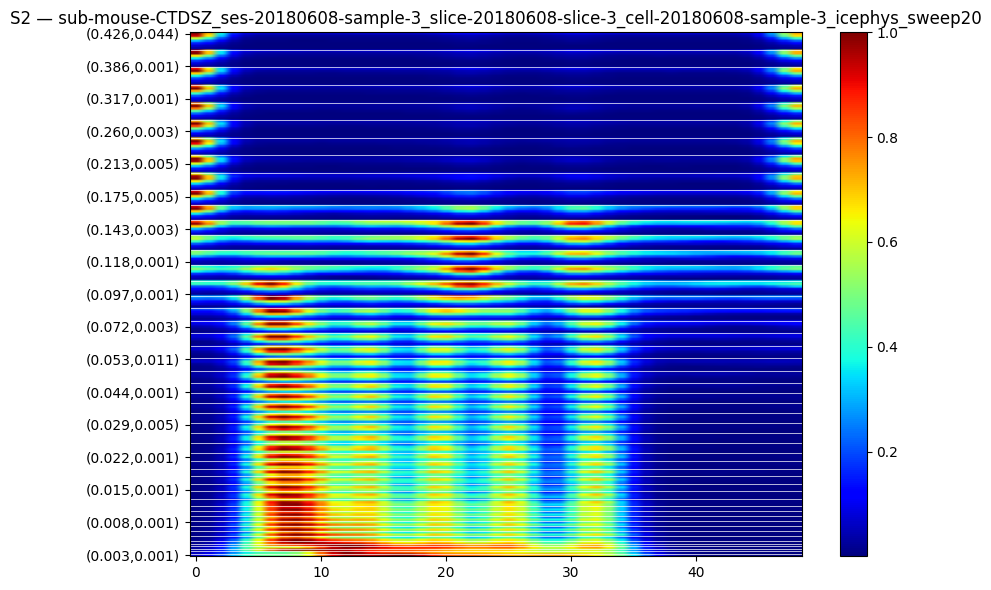

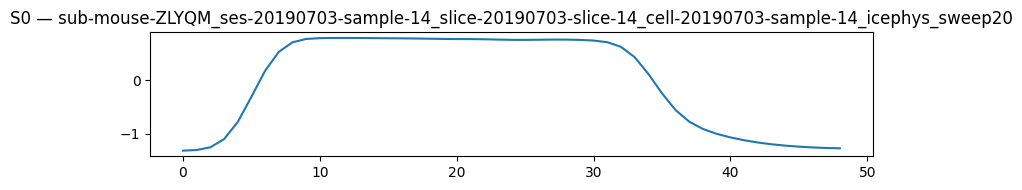

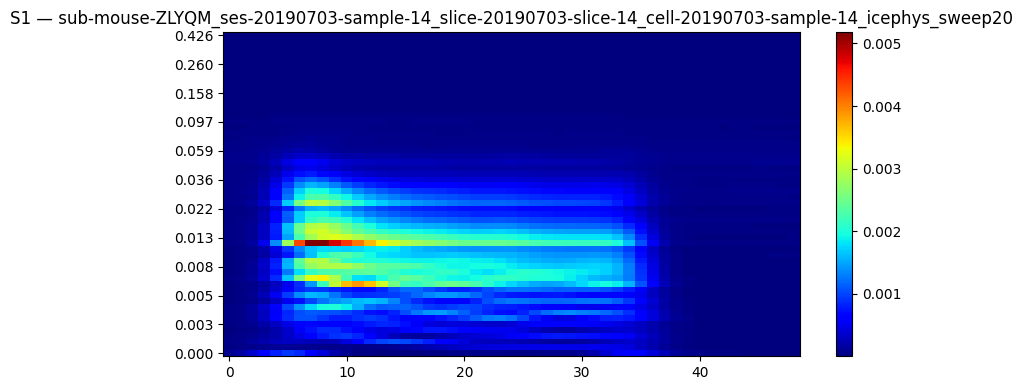

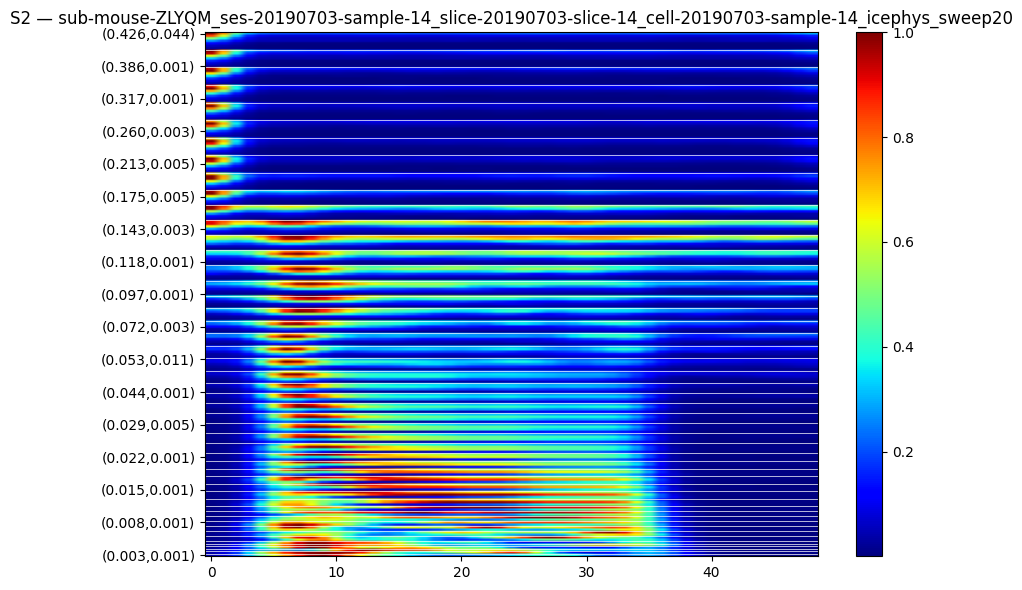

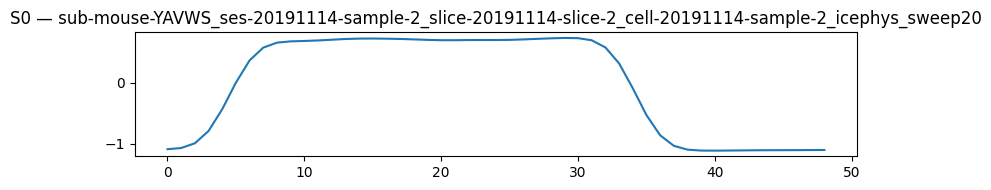

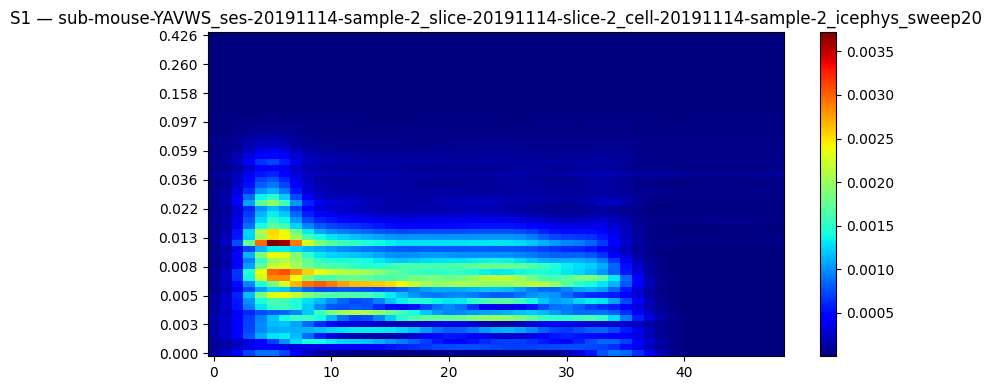

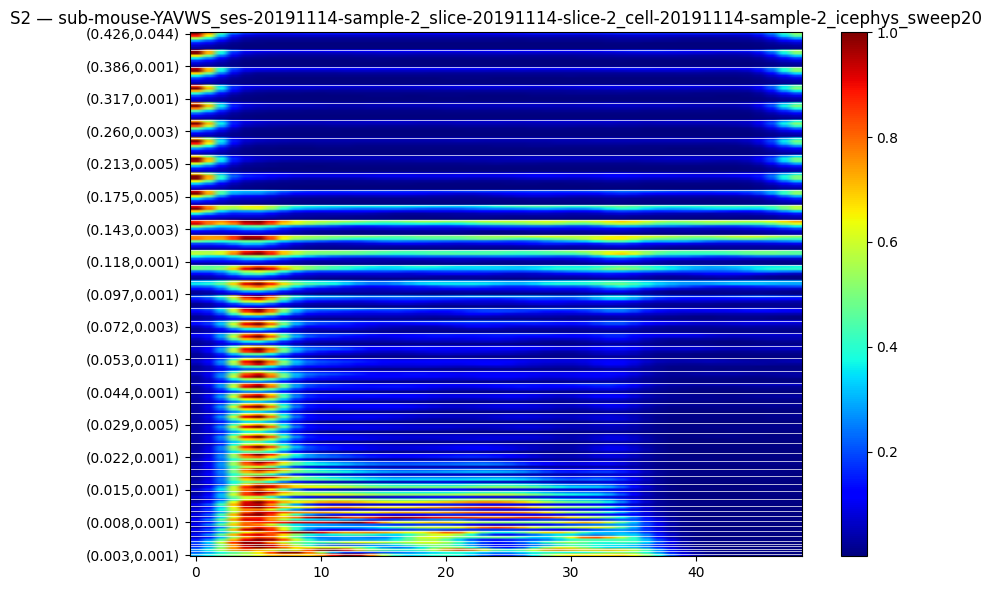

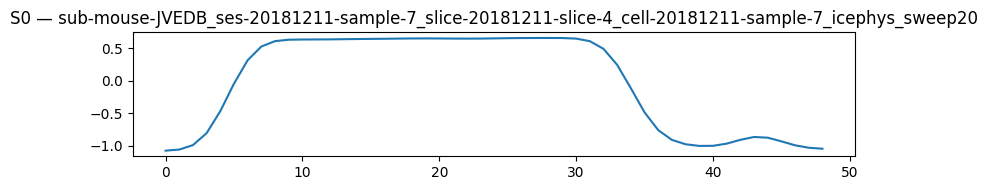

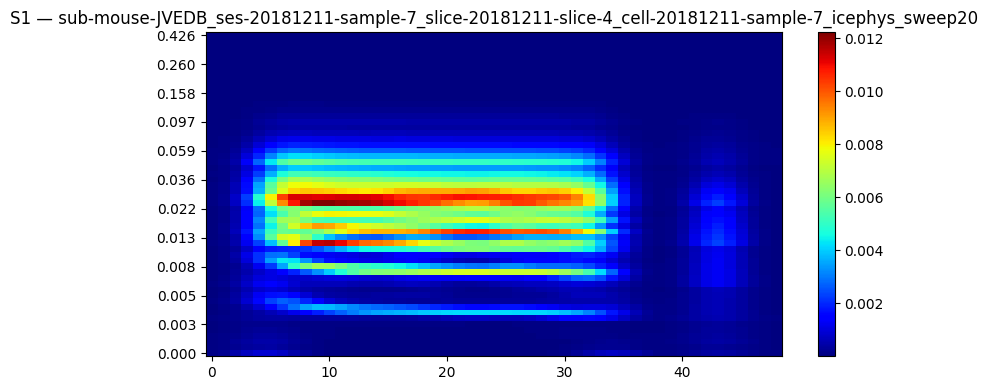

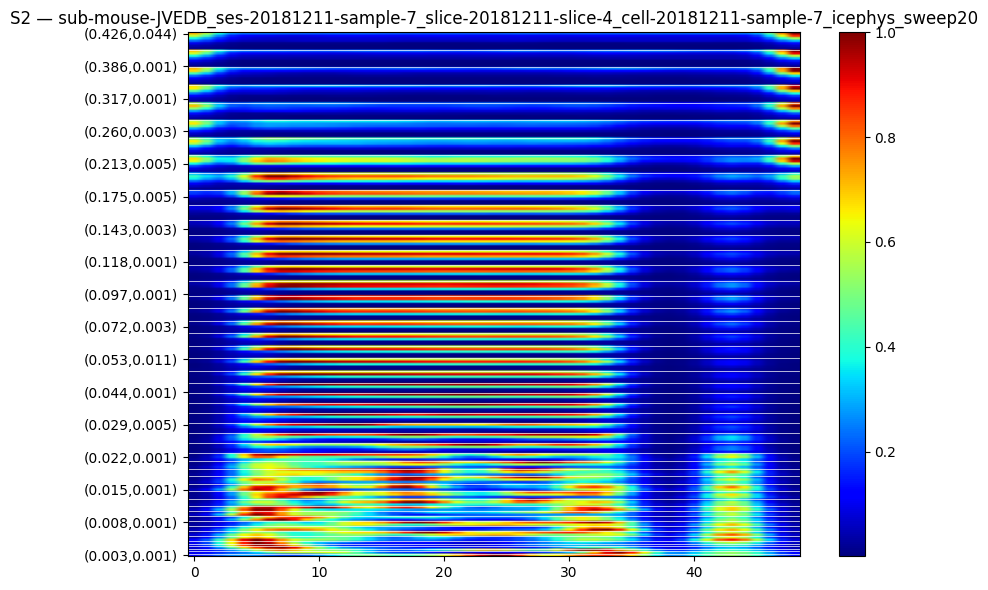

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from kymatio.torch import Scattering1D
import random

CSV_PATH = "voltage___traces2345.csv"
J = 9
Q = 7
OVERSAMPLING = 0
MAX_ORDER = 2
N_PLOTS = 5

df = pd.read_csv(CSV_PATH)
names = df.columns[1:]
data = df[names].T.to_numpy().astype(np.float32)

N, L = data.shape
means = data.mean(axis=1, keepdims=True)
stds = data.std(axis=1, keepdims=True)
stds[stds == 0] = 1
data = (data - means) / stds

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

scattering = Scattering1D(J=J, shape=L, Q=Q, oversampling=OVERSAMPLING, max_order=MAX_ORDER).to(device)
meta = scattering.meta()

order = meta["order"]
j_all = meta["j"]
xi_all = meta["xi"]

order0 = np.where(order == 0)[0]
order1 = np.where(order == 1)[0]
order2 = np.where(order == 2)[0]

xi1 = xi_all[order1, 0]
sort1 = np.argsort(xi1)[::-1]
xi1_sorted = xi1[sort1]

xi_pairs = xi_all[order2]
perm_S2 = np.lexsort((-xi_pairs[:, 1], -xi_pairs[:, 0]))
order2_sorted = order2[perm_S2]
xi_pairs_sorted = xi_pairs[perm_S2]

parent_change_rows = np.where(np.diff(xi_pairs_sorted[:, 0]) != 0)[0] + 1

x_torch = torch.from_numpy(data).unsqueeze(1).float().to(device)
with torch.no_grad():
    Sx = scattering(x_torch)

Sx = Sx.cpu().numpy()
if Sx.ndim == 4:
    Sx = Sx[:, 0]
if Sx.shape[1] != len(order):
    Sx = np.transpose(Sx, (0, 2, 1))

S0 = Sx[:, order0, :]
S1_unsorted = Sx[:, order1, :]
S2_unsorted = Sx[:, order2, :]

S1 = S1_unsorted[:, sort1, :]
S2 = S2_unsorted[:, perm_S2, :]

np.save("GPU_WST_full.npy", Sx)
np.save("GPU_WST_S1.npy", S1)
np.save("GPU_WST_S2.npy", S2)

np.savez(
    "GPU_WST_S1S2_both.npz",
    names=np.array(names),
    S1=S1,
    S2=S2,
    xi1=xi1_sorted,
    xi_pairs=xi_pairs_sorted
)

rand_indices = random.sample(range(N), min(N_PLOTS, N))

for idx in rand_indices:
    name = names[idx]

    plt.figure(figsize=(8, 2))
    plt.plot(S0[idx, 0])
    plt.title(f"S0 — {name}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.imshow(S1[idx], aspect="auto", origin="upper", cmap="jet")
    ax = plt.gca()
    K = len(xi1_sorted)
    step = max(1, K // 10)
    tick_pos = np.arange(0, K, step)
    ax.set_yticks(tick_pos)
    ax.set_yticklabels([f"{xi1_sorted[p]:.3f}" for p in tick_pos])
    plt.title(f"S1 — {name}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    S2n = S2[idx].copy()
    start = 0
    for brk in list(parent_change_rows) + [S2n.shape[0]]:
        block = S2n[start:brk]
        d = np.max(block)
        if d > 0:
            S2n[start:brk] = block / d
        start = brk

    plt.figure(figsize=(9, 6))
    plt.imshow(S2n, aspect="auto", origin="upper", cmap="jet")
    ax = plt.gca()
    for r in parent_change_rows:
        ax.axhline(y=r - 0.5, color="white", linewidth=0.5)
    npaths = S2n.shape[0]
    step = max(1, npaths // 15)
    ticks = np.arange(0, npaths, step)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"({xi_pairs_sorted[r,0]:.3f},{xi_pairs_sorted[r,1]:.3f})" for r in ticks])
    plt.title(f"S2 — {name}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


Loaded S1: (790, 56, 49)
Flattened S1: (790, 2744)
Standardized feature matrix: (790, 2744)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding: (790, 2)


/tmp/ipykernel_5096/1824628717.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


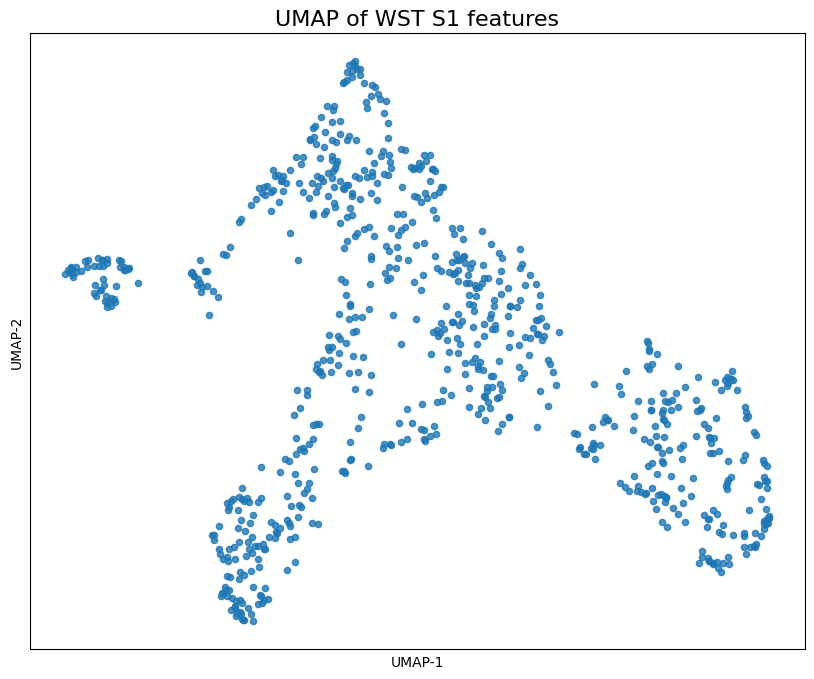

Loaded S2: (790, 209, 49)
Flattened S2: (790, 10241)
Standardized feature matrix: (790, 10241)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding: (790, 2)


/tmp/ipykernel_5096/1824628717.py:111: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


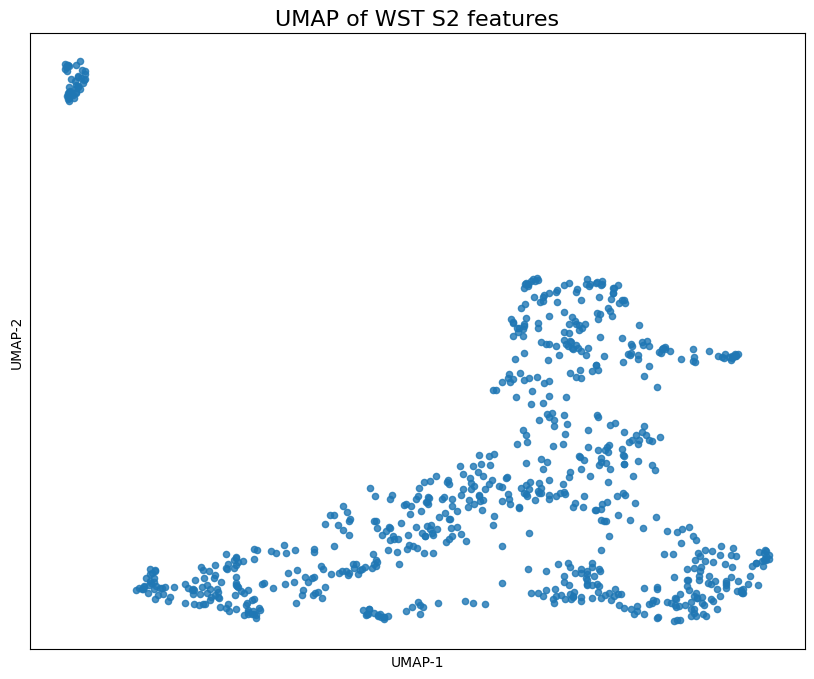

Loaded S1: (790, 56, 49)
Loaded S2: (790, 209, 49)
Flattened S1: (790, 2744)
Flattened S2: (790, 10241)
Concatenated feature matrix: (790, 12985)
Standardized: (790, 12985)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding S1+S2: (790, 2)


/tmp/ipykernel_5096/1824628717.py:188: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


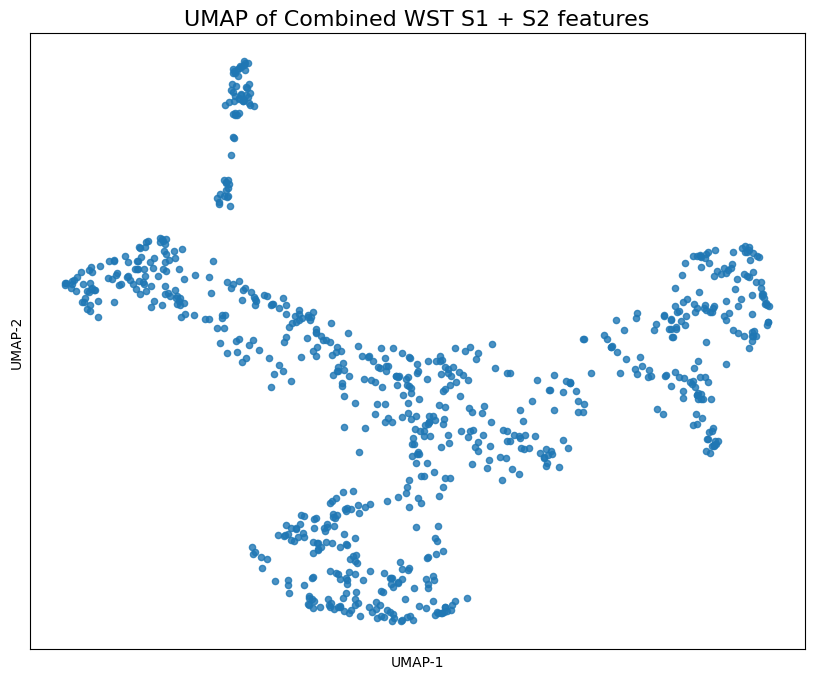

Embedding shape: (790, 2)
Number of names: 790
                                                name            short_id  \
0  sub-mouse-SQHCC_ses-20180313-sample-9_slice-20...   20180313_sample_9   
1  sub-mouse-WYKLJ_ses-20190415-sample-4_slice-20...   20190415_sample_4   
2  sub-mouse-WYKLJ_ses-20190415-sample-10_slice-2...  20190415_sample_10   
3  sub-mouse-WYKLJ_ses-20190415-sample-6_slice-20...   20190415_sample_6   
4  sub-mouse-WYKLJ_ses-20190415-sample-8_slice-20...   20190415_sample_8   

      UMAP1     UMAP2  
0  7.686379  2.291552  
1  0.944154 -2.451550  
2  1.825954 -2.962457  
3  0.487387  2.206901  
4  1.361035 -2.635862  
Metadata columns: ['Number', 'Cell', 'Slice', 'Date', 'Sample', 'Mouse', 'Mouse date of birth', 'Mouse age', 'Mouse gender', 'Mouse genotype', 'Targeted layer', 'Inferred layer', 'Cre', 'Exon reads', 'Intron reads', 'Intergenic reads', 'Sequencing batch', 'Number of genes detected', 'RNA family', 'RNA type', 'RNA type confidence', 'RNA type top-3', '

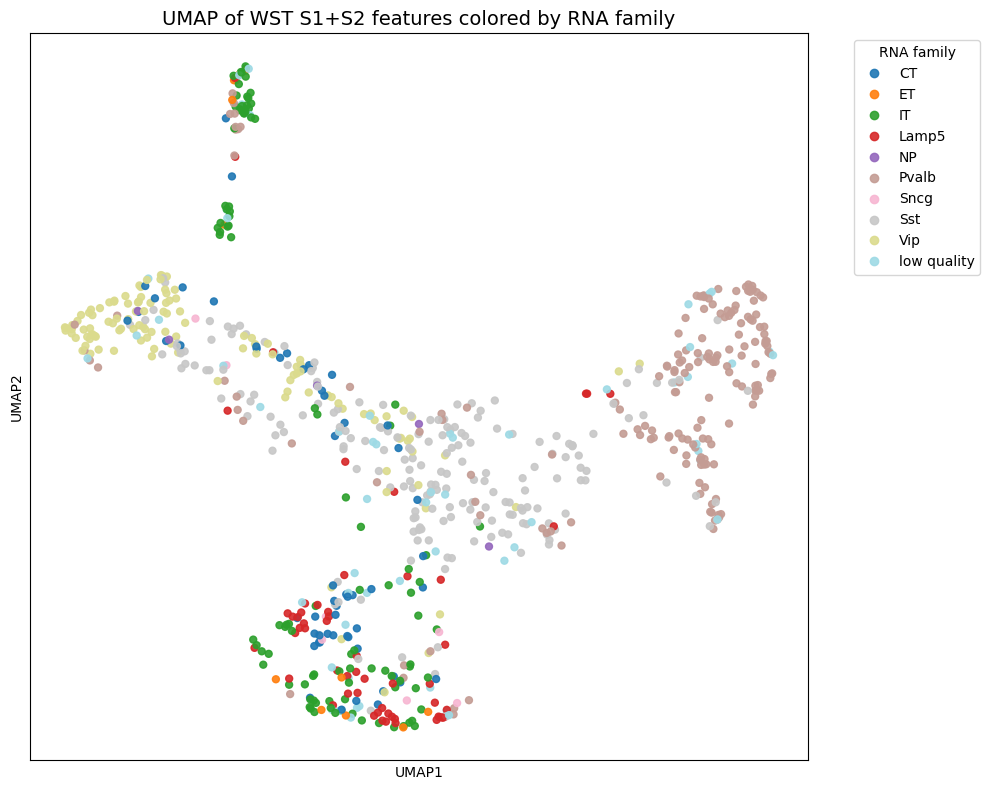

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap

# -------------------------------------------------------
# 1) Load S1 from saved .npz
# -------------------------------------------------------
npz = np.load("/content/GPU_WST_S1S2_both.npz", allow_pickle=True)

S1 = npz["S1"]      # shape (N, n1, T)
names = npz["names"]

print("Loaded S1:", S1.shape)

# -------------------------------------------------------
# 2) Flatten S1 per cell  → shape (N, n1*T)
# -------------------------------------------------------
N, n1, T = S1.shape
S_flat = S1.reshape(N, n1 * T)

print("Flattened S1:", S_flat.shape)

# -------------------------------------------------------
# 3) Standardize features (recommended before UMAP)
# -------------------------------------------------------
scaler = StandardScaler()
S_std = scaler.fit_transform(S_flat)

print("Standardized feature matrix:", S_std.shape)

# -------------------------------------------------------
# 4) Run UMAP
# -------------------------------------------------------
reducer = umap.UMAP(
    n_neighbors=25,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding_S1 = reducer.fit_transform(S_std)

print("UMAP embedding:", embedding_S1.shape)

# -------------------------------------------------------
# 5) Plot
# -------------------------------------------------------
plt.figure(figsize=(10, 8))
plt.scatter(
    embedding_S1[:, 0],
    embedding_S1[:, 1],
    s=20,
    alpha=0.8,
    cmap="Spectral"
)

plt.title("UMAP of WST S1 features", fontsize=16)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.xticks([])
plt.yticks([])
plt.show()

from sklearn.preprocessing import StandardScaler

# -------------------------------------------------------
# 1) Load S2 representation from saved .npz
# -------------------------------------------------------
npz = np.load("/content/GPU_WST_S1S2_both.npz", allow_pickle=True)

S2 = npz["S2"]      # shape (N, n2, T)
names = npz["names"]

print("Loaded S2:", S2.shape)

# -------------------------------------------------------
# 2) Flatten S2 per cell  → shape (N, n2*T)
# -------------------------------------------------------
N, n2, T = S2.shape
S_flat = S2.reshape(N, n2 * T)

print("Flattened S2:", S_flat.shape)

# -------------------------------------------------------
# 3) Standardize features (recommended before UMAP)
# -------------------------------------------------------
scaler = StandardScaler()
S_std = scaler.fit_transform(S_flat)

print("Standardized feature matrix:", S_std.shape)

# -------------------------------------------------------
# 4) Run UMAP
# -------------------------------------------------------
reducer = umap.UMAP(
    n_neighbors=25,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding = reducer.fit_transform(S_std)   # shape (N, 2)

print("UMAP embedding:", embedding.shape)

# -------------------------------------------------------
# 5) Plot
# -------------------------------------------------------
plt.figure(figsize=(10, 8))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=20,
    alpha=0.8,
    cmap="Spectral"
)

plt.title("UMAP of WST S2 features", fontsize=16)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.xticks([])
plt.yticks([])
plt.show()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap

# -------------------------------------------------------
# 1) Load S1 and S2 from saved .npz
# -------------------------------------------------------
npz = np.load("/content/GPU_WST_S1S2_both.npz", allow_pickle=True)

S1 = npz["S1"]      # (N, n1, T)
S2 = npz["S2"]      # (N, n2, T)
names = npz["names"]

print("Loaded S1:", S1.shape)
print("Loaded S2:", S2.shape)

# -------------------------------------------------------
# 2) Flatten feature tensors
# -------------------------------------------------------
N, n1, T1 = S1.shape
_, n2, T2 = S2.shape

flat_S1 = S1.reshape(N, n1 * T1)   # (N, n1*T)
flat_S2 = S2.reshape(N, n2 * T2)   # (N, n2*T)

print("Flattened S1:", flat_S1.shape)
print("Flattened S2:", flat_S2.shape)

# -------------------------------------------------------
# 3) Concatenate S1 + S2
# -------------------------------------------------------
S_concat = np.concatenate([flat_S1, flat_S2], axis=1)  # shape (N, total_features)

print("Concatenated feature matrix:", S_concat.shape)

# -------------------------------------------------------
# 4) Standardize
# -------------------------------------------------------
scaler = StandardScaler()
S_std = scaler.fit_transform(S_concat)

print("Standardized:", S_std.shape)

# -------------------------------------------------------
# 5) Run UMAP
# -------------------------------------------------------
reducer = umap.UMAP(
    n_neighbors=25,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding_S1S2 = reducer.fit_transform(S_std)

print("UMAP embedding S1+S2:", embedding_S1S2.shape)

# -------------------------------------------------------
# 6) Plot
# -------------------------------------------------------
plt.figure(figsize=(10, 8))
plt.scatter(
    embedding_S1S2[:, 0],
    embedding_S1S2[:, 1],
    s=20,
    alpha=0.8,
    cmap="Spectral"
)

plt.title("UMAP of Combined WST S1 + S2 features", fontsize=16)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.xticks([])
plt.yticks([])
plt.show()

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


N = len(names)
print("Embedding shape:", embedding_S1S2.shape)
print("Number of names:", N)



def long_id_to_short_id(cid: str):
    """
    Example:
    'sub-mouse-XXX_ses-20180420-sample-2_icephys_sweep20'
    --> '20180420_sample_2'
    """
    if not isinstance(cid, str):
        return None
    cid = cid.strip()
    m = re.search(r"ses-(\d+)-sample-(\d+)", cid)
    if m:
        date = m.group(1)
        samp = m.group(2)
        return f"{date}_sample_{samp}"
    return None

short_ids_umap = [long_id_to_short_id(n) for n in names]

# ---------------------------------------------
# 3) Build a DataFrame for the UMAP embedding
# ---------------------------------------------
df_umap = pd.DataFrame({
    "name": names,
    "short_id": short_ids_umap,
    "UMAP1": embedding_S1S2[:, 0],
    "UMAP2": embedding_S1S2[:, 1],
})

print(df_umap.head())

# ---------------------------------------------
# 4) Load RNA metadata (same file as in your DMD scri
META_PATH = "/content/m1_patchseq_meta_data (1).csv"

meta = pd.read_csv(META_PATH, sep="\t")
print("Metadata columns:", list(meta.columns))

# In your old script, 'Cell' contained short_id like '20171204_sample_2'
if "Cell" not in meta.columns:
    raise ValueError("Metadata file must contain a 'Cell' column with short_id.")

meta = meta.rename(columns={"Cell": "short_id"})
meta["short_id"] = meta["short_id"].astype(str).str.strip()

# Find the correct 'RNA family' column (handle small variations in name)
rna_family_col = None
for c in meta.columns:
    if c.strip().lower().replace(" ", "") == "rnafamily":
        rna_family_col = c
        break

if rna_family_col is None:
    raise ValueError("Could not find an 'RNA family' column in metadata.")

print("Using RNA family column:", rna_family_col)

# ---------------------------------------------
# 5) Merge UMAP with metadata on 'short_id'
# ---------------------------------------------
merged = df_umap.merge(
    meta[["short_id", rna_family_col]],
    on="short_id",
    how="left"
)

merged = merged.rename(columns={rna_family_col: "RNA_family"})

print("Merged shape:", merged.shape)
print("Unlabeled cells:", merged["RNA_family"].isna().sum())
print(merged[["name", "short_id", "RNA_family"]].head())

# ---------------------------------------------
# 6) Plot UMAP colored by RNA family
#    (labeled cells in color, unlabeled in light gray)
# ---------------------------------------------
plt.figure(figsize=(10, 8))

# Mask for labeled vs unlabeled
mask_labeled = merged["RNA_family"].notna()
mask_unlabeled = ~mask_labeled

# Labeled cells: map categories to integer codes
cat = merged.loc[mask_labeled, "RNA_family"].astype("category")
codes = cat.cat.codes

# Plot unlabeled in gray
plt.scatter(
    merged.loc[mask_unlabeled, "UMAP1"],
    merged.loc[mask_unlabeled, "UMAP2"],
    s=15,
    alpha=0.3,
    color="lightgray",
    label="No RNA label"
)

# Plot labeled with colormap
scatter = plt.scatter(
    merged.loc[mask_labeled, "UMAP1"],
    merged.loc[mask_labeled, "UMAP2"],
    c=codes,
    s=25,
    alpha=0.9,
    cmap="tab20"
)

plt.title("UMAP of WST S1+S2 features colored by RNA family", fontsize=14)
plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.xticks([]); plt.yticks([])

# Build legend from categories
handles, _ = scatter.legend_elements()
legend_labels = cat.cat.categories
plt.legend(handles, legend_labels, title="RNA family", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


Embedding S1 shape: (790, 2)
Number of names: 790
Preview embedding table:
                                                name            short_id  \
0  sub-mouse-SQHCC_ses-20180313-sample-9_slice-20...   20180313_sample_9   
1  sub-mouse-WYKLJ_ses-20190415-sample-4_slice-20...   20190415_sample_4   
2  sub-mouse-WYKLJ_ses-20190415-sample-10_slice-2...  20190415_sample_10   
3  sub-mouse-WYKLJ_ses-20190415-sample-6_slice-20...   20190415_sample_6   
4  sub-mouse-WYKLJ_ses-20190415-sample-8_slice-20...   20190415_sample_8   

       UMAP1     UMAP2  
0  11.457750 -1.110138  
1   3.270828  2.813550  
2   4.039853  3.491718  
3   3.147281 -0.324831  
4   4.028804  2.054701  
Metadata columns:
['Number', 'Cell', 'Slice', 'Date', 'Sample', 'Mouse', 'Mouse date of birth', 'Mouse age', 'Mouse gender', 'Mouse genotype', 'Targeted layer', 'Inferred layer', 'Cre', 'Exon reads', 'Intron reads', 'Intergenic reads', 'Sequencing batch', 'Number of genes detected', 'RNA family', 'RNA type', 'RNA typ

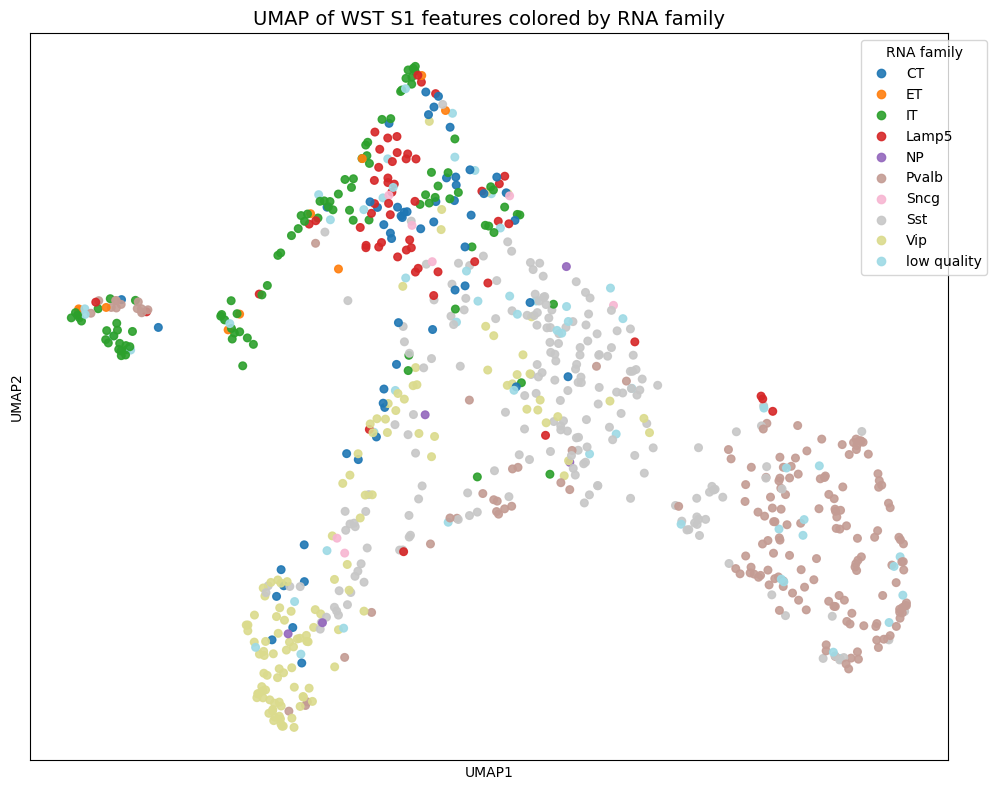

In [8]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
N = len(names)
print("Embedding S1 shape:", embedding_S1.shape)
print("Number of names:", N)

# ---------------------------------------------------
# 2) Convert long IDs → short_id
# ---------------------------------------------------
def long_id_to_short_id(cid: str):
    """
    Example:
    'sub-xxx_ses-20180420-sample-2_icephys_sweep20'
      →  '20180420_sample_2'
    """
    if not isinstance(cid, str):
        return None
    cid = cid.strip()
    m = re.search(r"ses-(\d+)-sample-(\d+)", cid)
    if m:
        date = m.group(1)
        samp = m.group(2)
        return f"{date}_sample_{samp}"
    return None

short_ids_S1 = [long_id_to_short_id(n) for n in names]

# ---------------------------------------------------
# 3) Build dataframe for UMAP S1
# ---------------------------------------------------
df_S1 = pd.DataFrame({
    "name": names,
    "short_id": short_ids_S1,
    "UMAP1": embedding_S1[:, 0],
    "UMAP2": embedding_S1[:, 1]
})

print("Preview embedding table:")
print(df_S1.head())

# ---------------------------------------------------
# ---------------------------------------------------
META_PATH = "/content/m1_patchseq_meta_data (1).csv"
meta = pd.read_csv(META_PATH, sep="\t")

print("Metadata columns:")
print(list(meta.columns))

# rename metadata column to match
if "Cell" not in meta.columns:
    raise ValueError("Metadata file missing required 'Cell' column.")

meta = meta.rename(columns={"Cell": "short_id"})
meta["short_id"] = meta["short_id"].astype(str).str.strip()

# detect correct RNA family column
rna_family_col = None
for c in meta.columns:
    if c.strip().lower().replace(" ", "") == "rnafamily":
        rna_family_col = c
        break

if rna_family_col is None:
    raise ValueError("No RNA family column found in metadata!")

print("Using RNA family column:", rna_family_col)

# ---------------------------------------------------
# 5) Merge UMAP embedding with metadata using short_id
# ---------------------------------------------------
merged_S1 = df_S1.merge(
    meta[["short_id", rna_family_col]],
    on="short_id",
    how="left"
)

merged_S1 = merged_S1.rename(columns={rna_family_col: "RNA_family"})

print("Merged shape:", merged_S1.shape)
print("Unlabeled cells:", merged_S1["RNA_family"].isna().sum())
print(merged_S1.head())

# ---------------------------------------------------
# 6) Plot UMAP colored by RNA family labels
# ---------------------------------------------------
plt.figure(figsize=(10, 8))

mask_labeled   = merged_S1["RNA_family"].notna()
mask_unlabeled = ~mask_labeled

# unlabeled = gray
plt.scatter(
    merged_S1.loc[mask_unlabeled, "UMAP1"],
    merged_S1.loc[mask_unlabeled, "UMAP2"],
    s=15,
    alpha=0.3,
    color="lightgray",
    label="No label"
)

# labeled = colors
cat  = merged_S1.loc[mask_labeled, "RNA_family"].astype("category")
codes = cat.cat.codes

scatter = plt.scatter(
    merged_S1.loc[mask_labeled, "UMAP1"],
    merged_S1.loc[mask_labeled, "UMAP2"],
    c=codes,
    cmap="tab20",
    s=30,
    alpha=0.9
)

plt.title("UMAP of WST S1 features colored by RNA family", fontsize=14)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.xticks([]); plt.yticks([])

# legend
handles, _ = scatter.legend_elements()
legend_labels = cat.cat.categories
plt.legend(handles, legend_labels, title="RNA family", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


S2 tensor: (790, 209, 49)
Names loaded: 790
Flattened S2: (790, 10241)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP S2 computed: (790, 2)
                                                name            short_id  \
0  sub-mouse-SQHCC_ses-20180313-sample-9_slice-20...   20180313_sample_9   
1  sub-mouse-WYKLJ_ses-20190415-sample-4_slice-20...   20190415_sample_4   
2  sub-mouse-WYKLJ_ses-20190415-sample-10_slice-2...  20190415_sample_10   
3  sub-mouse-WYKLJ_ses-20190415-sample-6_slice-20...   20190415_sample_6   
4  sub-mouse-WYKLJ_ses-20190415-sample-8_slice-20...   20190415_sample_8   

      UMAP1     UMAP2  
0  7.979366  4.541434  
1  7.172111 -3.214926  
2  8.945868 -3.824626  
3  4.393831 -2.739170  
4  8.142921 -3.334608  
Merged: (790, 5)
Unlabeled cells: 0


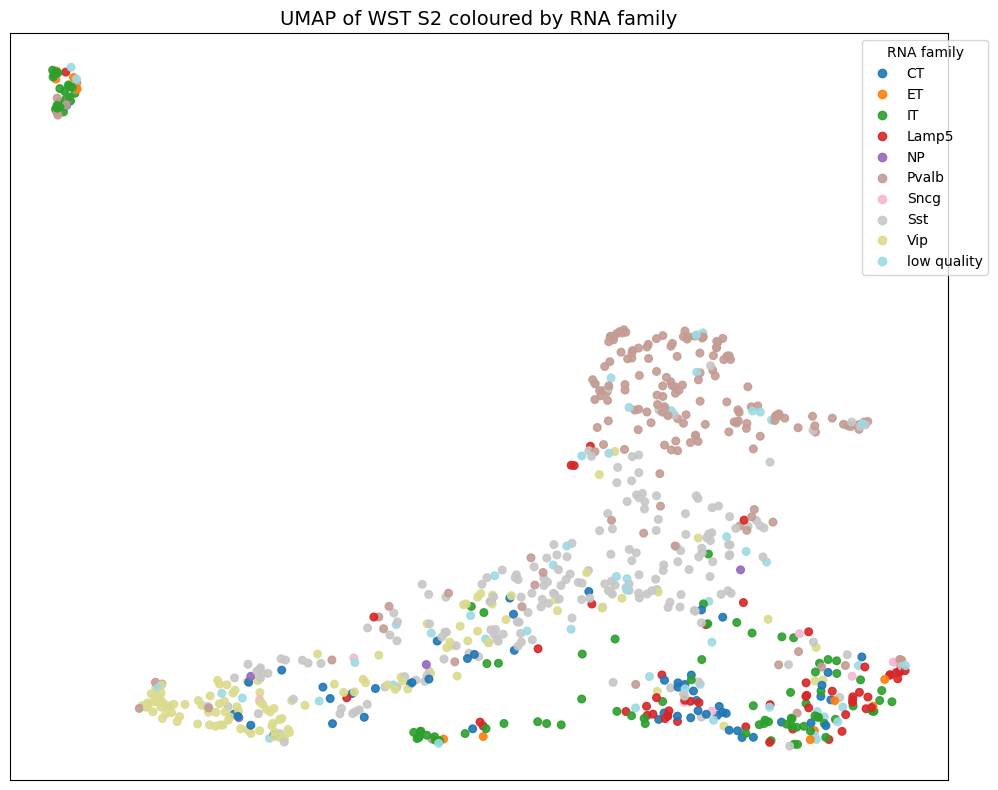

In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from sklearn.preprocessing import StandardScaler
import re


# ---------------------------------------------------
# 1) Check S2 exists
# ---------------------------------------------------
try:
    S2
except NameError:
    raise RuntimeError("❌ S2 is NOT loaded. Load your GPU_WST_S1S2_both.npz first!!")

print("S2 tensor:", S2.shape)
print("Names loaded:", len(names))

# ---------------------------------------------------
# 2) Flatten S2 features (N, n2*T)
# ---------------------------------------------------
N, n2, T = S2.shape
flat_S2 = S2.reshape(N, n2 * T)

print("Flattened S2:", flat_S2.shape)

# ---------------------------------------------------
# 3) Normalize features
# ---------------------------------------------------
scaler = StandardScaler()
S2_std = scaler.fit_transform(flat_S2)

# ---------------------------------------------------
# 4) Run UMAP
# ---------------------------------------------------
reducer = umap.UMAP(
    n_neighbors=25,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding_S2 = reducer.fit_transform(S2_std)

print("UMAP S2 computed:", embedding_S2.shape)

# ---------------------------------------------------
# 5) Convert names → short_id
# ---------------------------------------------------
def long_id_to_short_id(cid: str):
    cid = str(cid).strip()
    m = re.search(r"ses-(\d+)-sample-(\d+)", cid)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"
    return None

short_id_S2 = [long_id_to_short_id(n) for n in names]

df_S2 = pd.DataFrame({
    "name": names,
    "short_id": short_id_S2,
    "UMAP1": embedding_S2[:, 0],
    "UMAP2": embedding_S2[:, 1]
})

print(df_S2.head())

# ---------------------------------------------------
# 6) Load metadata
# ---------------------------------------------------
META_PATH = "/content/m1_patchseq_meta_data (1).csv"
meta = pd.read_csv(META_PATH, sep="\t")

meta = meta.rename(columns={"Cell": "short_id"})
meta["short_id"] = meta["short_id"].astype(str).str.strip()

# detect RNA family column
rna_family_col = None
for c in meta.columns:
    if c.strip().lower().replace(" ", "") == "rnafamily":
        rna_family_col = c
        break

if rna_family_col is None:
    raise ValueError("❌ RNA family column missing in metadata")

# ---------------------------------------------------
# 7) Merge S2 UMAP with metadata
# ---------------------------------------------------
merged_S2 = df_S2.merge(
    meta[["short_id", rna_family_col]],
    on="short_id",
    how="left"
).rename(columns={rna_family_col: "RNA_family"})

print("Merged:", merged_S2.shape)
print("Unlabeled cells:", merged_S2["RNA_family"].isna().sum())

# ---------------------------------------------------
# 8) Plot colouring by RNA family
# ---------------------------------------------------
plt.figure(figsize=(10, 8))

mask_labeled   = merged_S2["RNA_family"].notna()
mask_unlabeled = ~mask_labeled

# unlabeled = grey
plt.scatter(
    merged_S2.loc[mask_unlabeled, "UMAP1"],
    merged_S2.loc[mask_unlabeled, "UMAP2"],
    s=15,
    alpha=0.3,
    color="lightgray"
)

# labeled = coloured
cat = merged_S2.loc[mask_labeled, "RNA_family"].astype("category")
codes = cat.cat.codes

scatter = plt.scatter(
    merged_S2.loc[mask_labeled, "UMAP1"],
    merged_S2.loc[mask_labeled, "UMAP2"],
    c=codes,
    cmap="tab20",
    s=30,
    alpha=0.9
)

plt.title("UMAP of WST S2 coloured by RNA family", fontsize=14)
plt.xticks([]); plt.yticks([])

# add legend
handles, _ = scatter.legend_elements()
legend_labels = cat.cat.categories
plt.legend(handles, legend_labels, bbox_to_anchor=(1.05, 1), title="RNA family")

plt.tight_layout()
plt.show()


## 🔗 Matching WST and EPHYS Cells

This step aligns cells between the WST dataset and the EPHYS dataset.

### 🔹 Problem
- WST and EPHYS use **different naming formats** for the same cells.
- Direct matching is not possible.

**Example:**
- WST: `sub-..._ses-20190516-sample-5_...`
- EPHYS: `20190516_sample_5`

---

### 🔹 Solution
We extract a **common identifier (`short_id`)** from both datasets:


In [9]:
import re
import numpy as np
import pandas as pd

# ===============================
# 1) Load WST names
# ===============================
CSV_WST = "voltage___traces2345.csv"
df_wst = pd.read_csv(CSV_WST)

wst_names = df_wst.columns[1:].astype(str).values
print("WST cells:", len(wst_names))
print("Example WST:", wst_names[:3])

# ===============================
# 2) Load EPHYS features
# ===============================
EPHYS_PATH = "/content/m1_patchseq_ephys_features.csv"
ephys = pd.read_csv(EPHYS_PATH)

ephys["cell id"] = ephys["cell id"].astype(str)
print("EPHYS rows:", ephys.shape[0], "| unique:", ephys["cell id"].nunique())
print("Example EPHYS cell id:", ephys["cell id"].unique()[:3])

# ===============================
# 3) Canonical key builders
# ===============================
def wst_to_key(name):
    """
    sub-mouse-XXX_ses-20190516-sample-5_slice-..._icephys_sweep20
    -> 20190516_sample_5
    """
    m = re.search(r"ses-(\d+)-sample-(\d+)", name)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"
    return None

def ephys_to_key(name):
    """
    20190516_sample_5 -> 20190516_sample_5
    """
    m = re.search(r"(\d+)_sample_(\d+)", name)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"
    return None

# ===============================
# 4) Build key arrays
# ===============================
wst_keys = np.array([wst_to_key(n) for n in wst_names])
ephys_keys = np.array([ephys_to_key(n) for n in ephys["cell id"].values])

# remove None
mask_wst = np.array([k is not None for k in wst_keys])
mask_eph = np.array([k is not None for k in ephys_keys])

wst_keys = wst_keys[mask_wst]
wst_names = wst_names[mask_wst]

ephys_keys = ephys_keys[mask_eph]
ephys = ephys.loc[mask_eph].reset_index(drop=True)

print("Valid WST keys:", len(wst_keys))
print("Valid EPHYS keys:", len(ephys_keys))

# ===============================
# 5) Intersection
# ===============================
common_keys = np.intersect1d(wst_keys, ephys_keys)
print("✅ common cells:", len(common_keys))

if len(common_keys) == 0:
    raise RuntimeError("No overlap — key logic is wrong")

# ===============================
# 6) Build lookup tables
# ===============================
wst_key_to_name = {}
for k, n in zip(wst_keys, wst_names):
    wst_key_to_name.setdefault(k, n)

ephys_key_to_row = {}
for i, k in enumerate(ephys_keys):
    ephys_key_to_row.setdefault(k, i)

# ===============================
# 7) Build ephys_common
# ===============================
rows = []
for k in common_keys:
    row = ephys.iloc[ephys_key_to_row[k]].copy()
    row["wst_name"] = wst_key_to_name[k]
    row["short_id"] = k
    rows.append(row)

ephys_common = pd.DataFrame(rows).reset_index(drop=True)

print("✅ ephys_common shape:", ephys_common.shape)
print(ephys_common[["cell id", "short_id"]].head())


WST cells: 790
Example WST: ['sub-mouse-SQHCC_ses-20180313-sample-9_slice-20180313-slice-9_cell-20180313-sample-9_icephys_sweep20'
 'sub-mouse-WYKLJ_ses-20190415-sample-4_slice-20190415-slice-4_cell-20190415-sample-4_icephys_sweep20'
 'sub-mouse-WYKLJ_ses-20190415-sample-10_slice-20190415-slice-10_cell-20190415-sample-10_icephys_sweep20']
EPHYS rows: 1328 | unique: 1328
Example EPHYS cell id: ['20180918_sample_1' '20180918_sample_2' '20180918_sample_3']
Valid WST keys: 790
Valid EPHYS keys: 1328
✅ common cells: 790
✅ ephys_common shape: (790, 32)
             cell id           short_id
0  20180313_sample_9  20180313_sample_9
1  20180315_sample_2  20180315_sample_2
2  20180321_sample_2  20180321_sample_2
3  20180321_sample_4  20180321_sample_4
4  20180321_sample_8  20180321_sample_8


ephys_common shape: (790, 32)
Raw feature matrix: (790, 29)
Cells with any missing feature: 7
Clean feature matrix: (783, 29)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (783, 2)
Cells without RNA family: 0


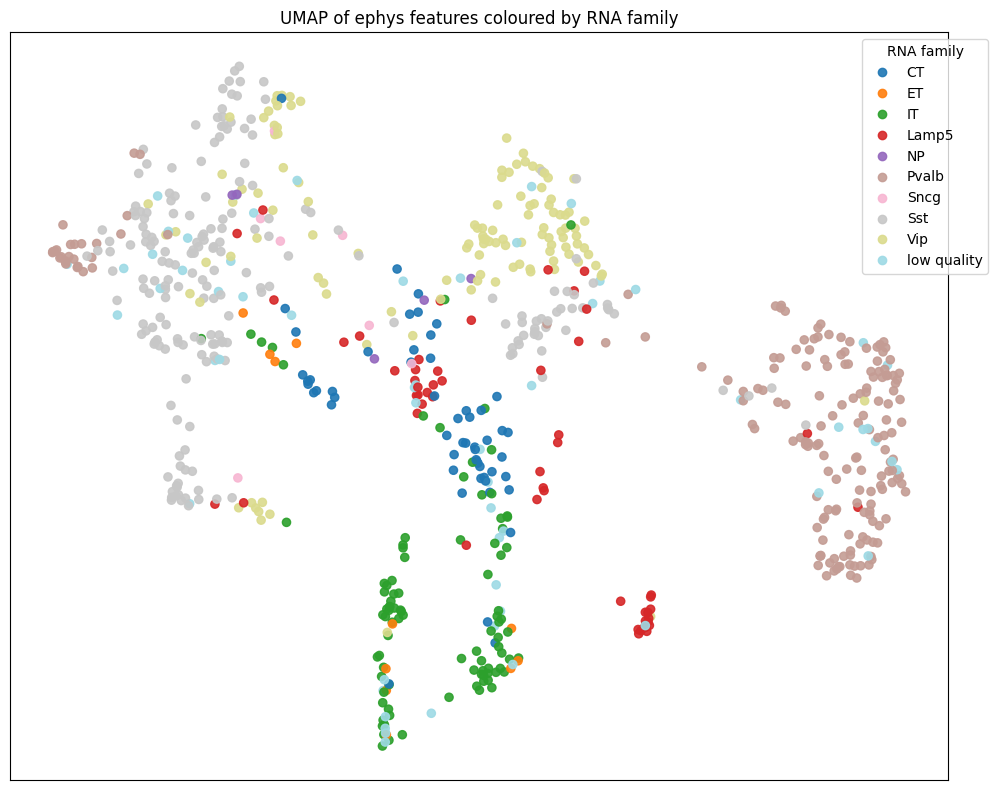

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from sklearn.preprocessing import StandardScaler

# =========================
# check
# =========================
print("ephys_common shape:", ephys_common.shape)

# =========================
# numeric features only
# =========================
X_df = ephys_common.select_dtypes(include=[np.number]).copy()
print("Raw feature matrix:", X_df.shape)

mask = ~X_df.isna().any(axis=1)
print("Cells with any missing feature:", (~mask).sum())

X_df = X_df[mask]
short_ids = ephys_common.loc[mask, "short_id"].values
print("Clean feature matrix:", X_df.shape)

# =========================
# standardize
# =========================
X = X_df.values.astype(float)
X = StandardScaler().fit_transform(X)

# =========================
# UMAP
# =========================
emb = umap.UMAP(
    n_neighbors=25,
    min_dist=0.1,
    n_components=2,
    random_state=42
).fit_transform(X)

print("UMAP embedding shape:", emb.shape)

# =========================
# RNA metadata
# =========================
meta = pd.read_csv("/content/m1_patchseq_meta_data (1).csv", sep="\t")
meta = meta.rename(columns={"Cell": "short_id"})
meta["short_id"] = meta["short_id"].astype(str).str.strip()

rna_col = None
for c in meta.columns:
    if c.strip().lower().replace(" ", "") == "rnafamily":
        rna_col = c
        break
if rna_col is None:
    raise RuntimeError("RNA family column not found")

# =========================
# merge
# =========================
plot_df = pd.DataFrame({
    "short_id": short_ids,
    "UMAP1": emb[:, 0],
    "UMAP2": emb[:, 1]
})

plot_df = plot_df.merge(
    meta[["short_id", rna_col]],
    on="short_id",
    how="left"
).rename(columns={rna_col: "RNA_family"})

print("Cells without RNA family:", plot_df["RNA_family"].isna().sum())

# =========================
# plot
# =========================
plt.figure(figsize=(10, 8))

mask_lab = plot_df["RNA_family"].notna()
mask_un  = ~mask_lab

plt.scatter(
    plot_df.loc[mask_un, "UMAP1"],
    plot_df.loc[mask_un, "UMAP2"],
    s=18, alpha=0.3, color="lightgray"
)

cats = plot_df.loc[mask_lab, "RNA_family"].astype("category")
codes = cats.cat.codes

sc = plt.scatter(
    plot_df.loc[mask_lab, "UMAP1"],
    plot_df.loc[mask_lab, "UMAP2"],
    c=codes, cmap="tab20", s=35, alpha=0.9
)

plt.xticks([]); plt.yticks([])
plt.title("UMAP of ephys features coloured by RNA family")

handles, _ = sc.legend_elements()
plt.legend(handles, cats.cat.categories, bbox_to_anchor=(1.05, 1), title="RNA family")

plt.tight_layout()
plt.show()


Number of voltage traces: 790
Loaded WST data:
  S1 shape: (790, 56, 49)
  S2 shape: (790, 209, 49)
  names   : (790,)
  xi1     : (56,)
  xi_pairs: (209, 2)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (790, 2)
Merged UMAP + RNA metadata: (790, 5)
Unlabeled cells: 0
Common cells between WST and manual ephys: 790
Labeled common cells: 790
Labeled common cells with all modalities: 790


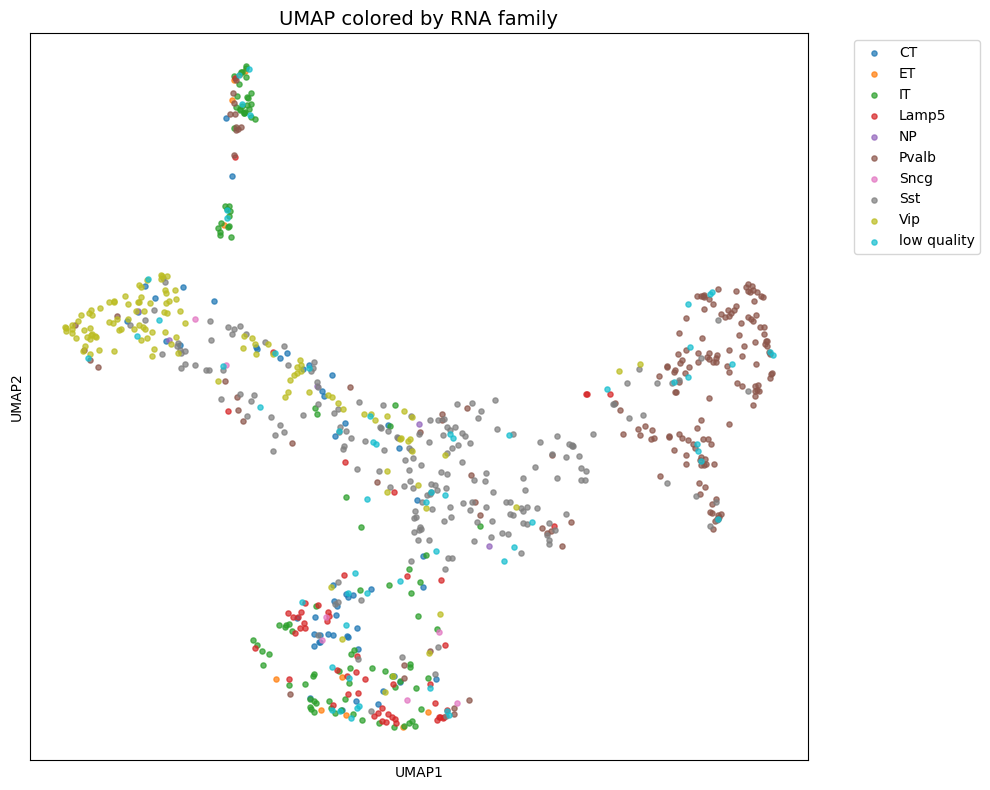

Saved: /content/umap_selected_cells_plots/UMAP_by_RNA_family.png
Families present: ['CT', 'ET', 'IT', 'Lamp5', 'NP', 'Pvalb', 'Sncg', 'Sst', 'Vip', 'low quality']
Minimum spatial separation on UMAP: 1.5021847

Selected representatives:
           pick_type RNA_family            short_id  \
0           PURE_BIN        Vip   20190528_sample_8   
1           PURE_BIN      Pvalb   20180404_sample_2   
2           PURE_BIN        Sst   20190801_sample_4   
3           PURE_BIN         IT   20180425_sample_4   
4          MIXED_BIN         CT  20190409_sample_10   
5          MIXED_BIN      Lamp5   20190917_sample_2   
6  FALLBACK_ANYWHERE         ET   20190926_sample_4   
7  FALLBACK_ANYWHERE         NP   20190911_sample_3   
8  FALLBACK_ANYWHERE       Sncg  20190611_sample_14   

                                            wst_name     UMAP1     UMAP2  \
0  sub-mouse-RBROS_ses-20190528-sample-8_slice-20... -2.048451  2.676493   
1  sub-mouse-ZWNGI_ses-20180404-sample-2_slice-20...  7.58076

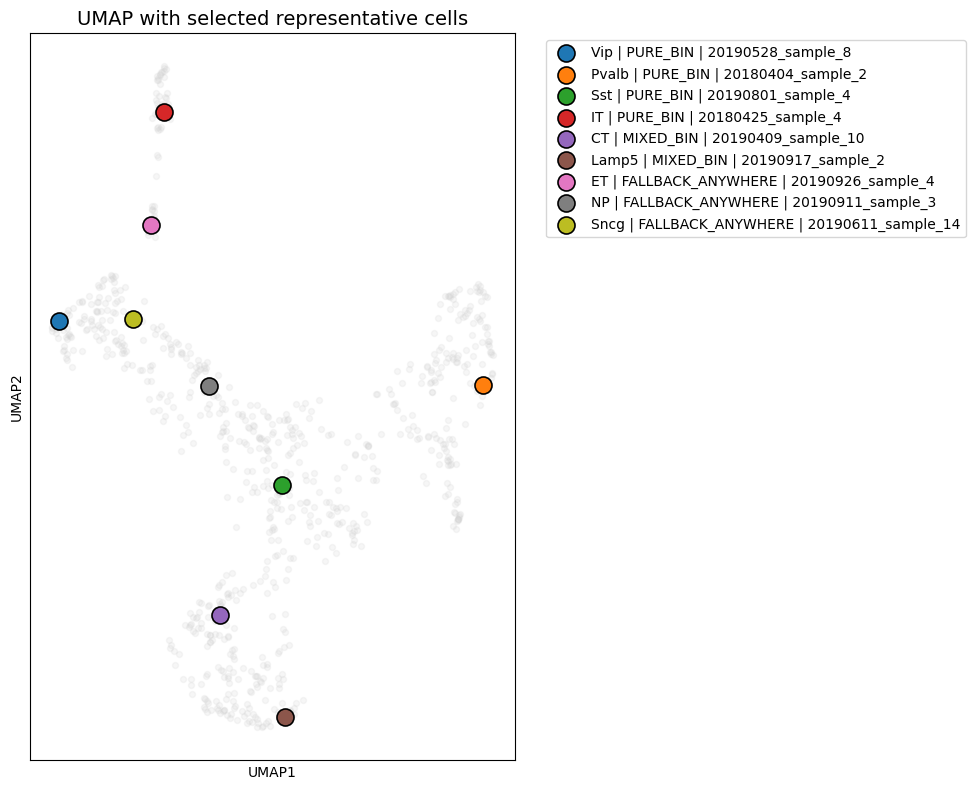

Saved: /content/umap_selected_cells_plots/UMAP_selected_representatives.png

Number of numeric manual ephys features: 29
Fixed x-axis range for manual-feature bar charts: (np.float64(-22.31896546588951), np.float64(22.31896546588951))


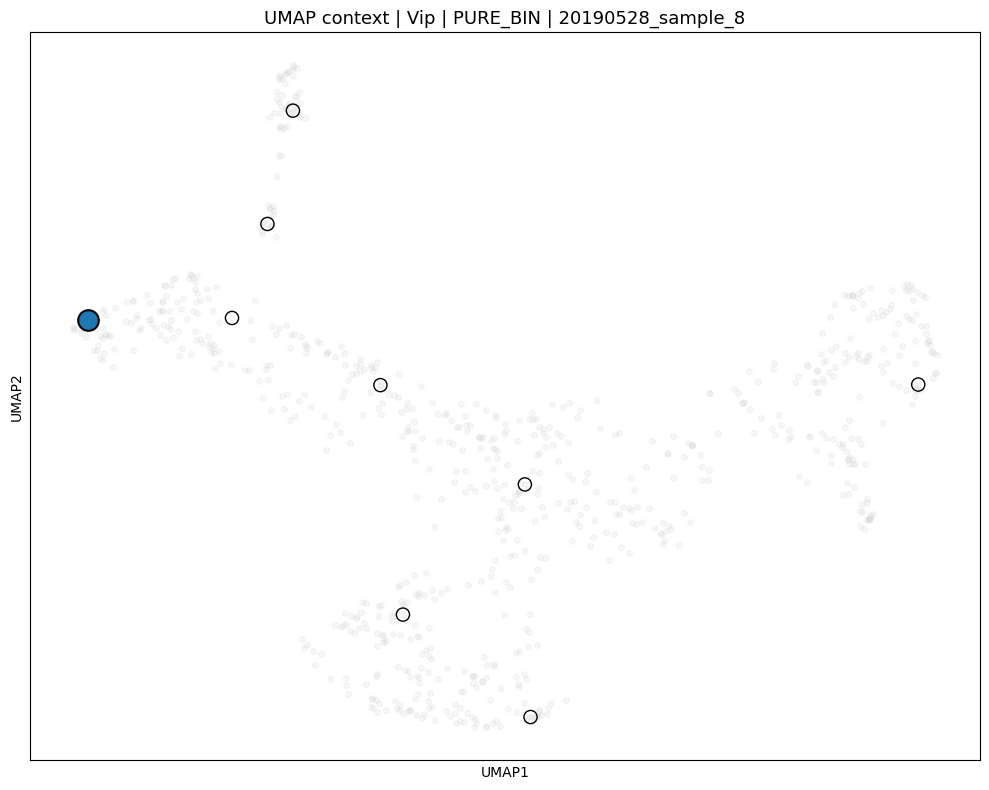

Saved: /content/umap_selected_cells_plots/Vip/PURE_BIN__20190528_sample_8/UMAP_selected_cell.png


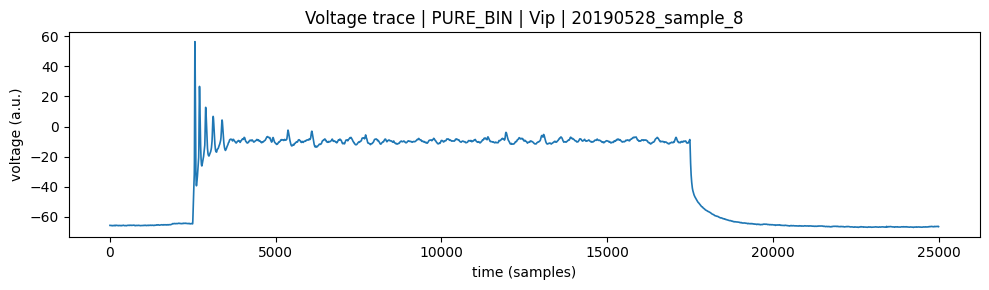

Saved: /content/umap_selected_cells_plots/Vip/PURE_BIN__20190528_sample_8/voltage.png


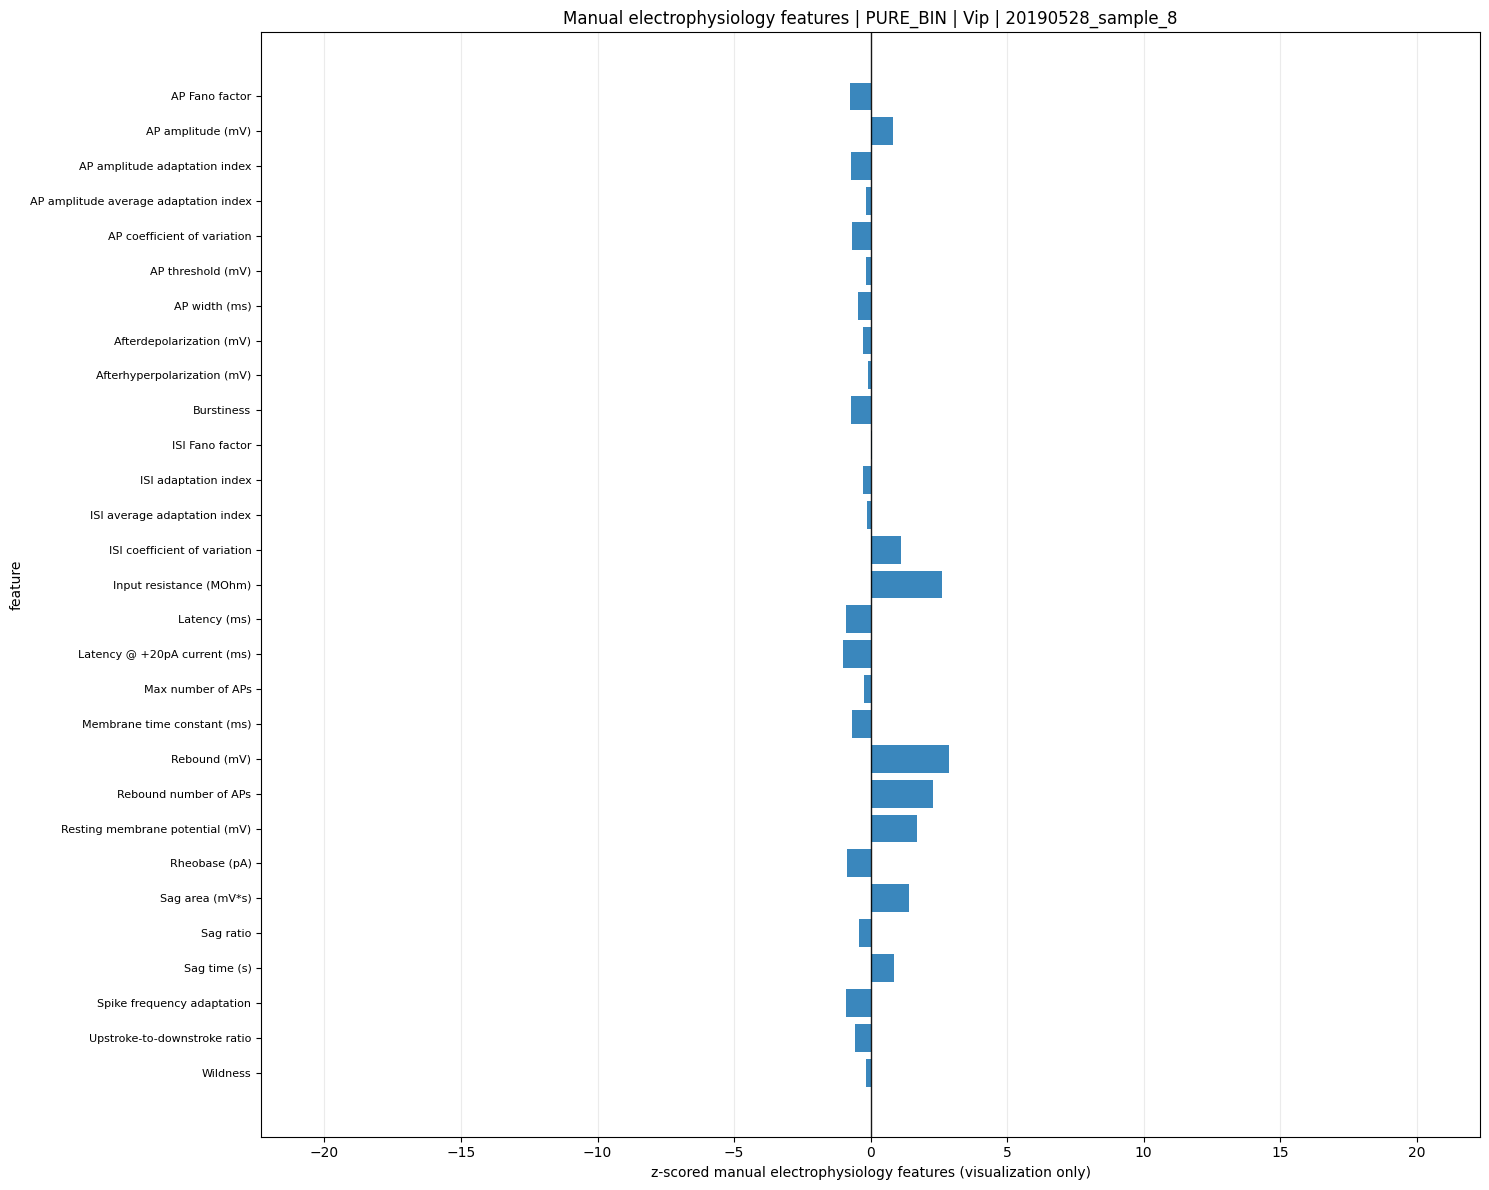

Saved: /content/umap_selected_cells_plots/Vip/PURE_BIN__20190528_sample_8/EPHYS_all_features_zscore.png


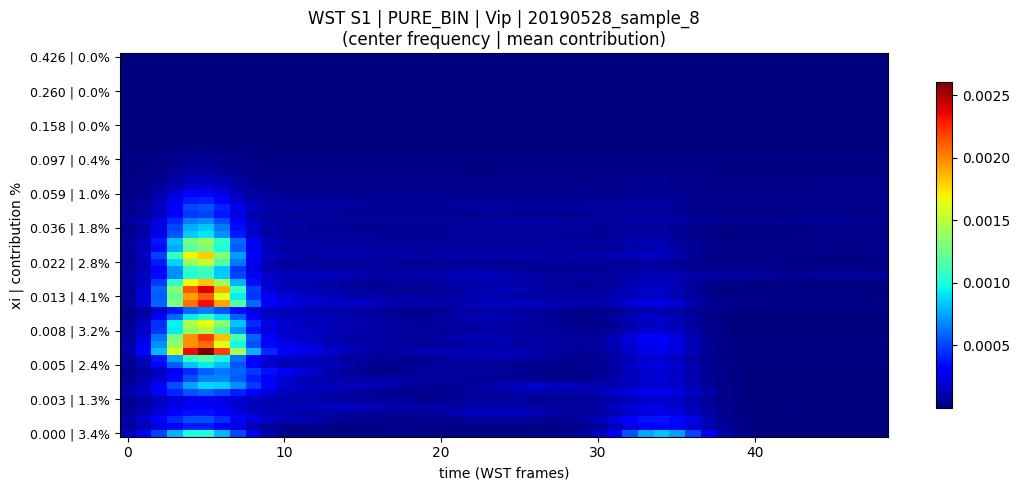

Saved: /content/umap_selected_cells_plots/Vip/PURE_BIN__20190528_sample_8/WST_S1.png


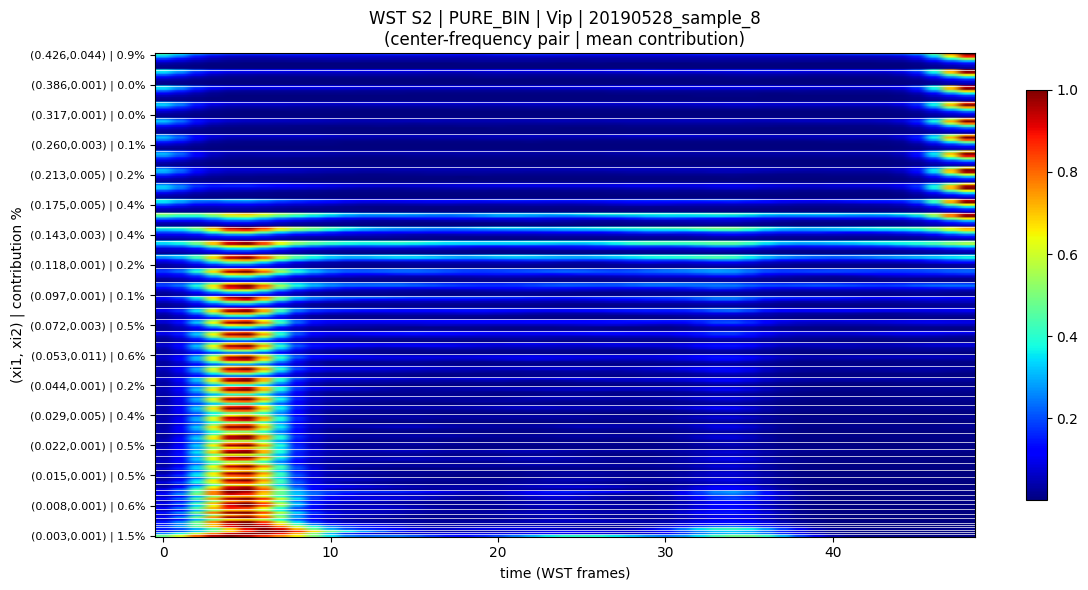

Saved: /content/umap_selected_cells_plots/Vip/PURE_BIN__20190528_sample_8/WST_S2.png
Completed cell folder: /content/umap_selected_cells_plots/Vip/PURE_BIN__20190528_sample_8


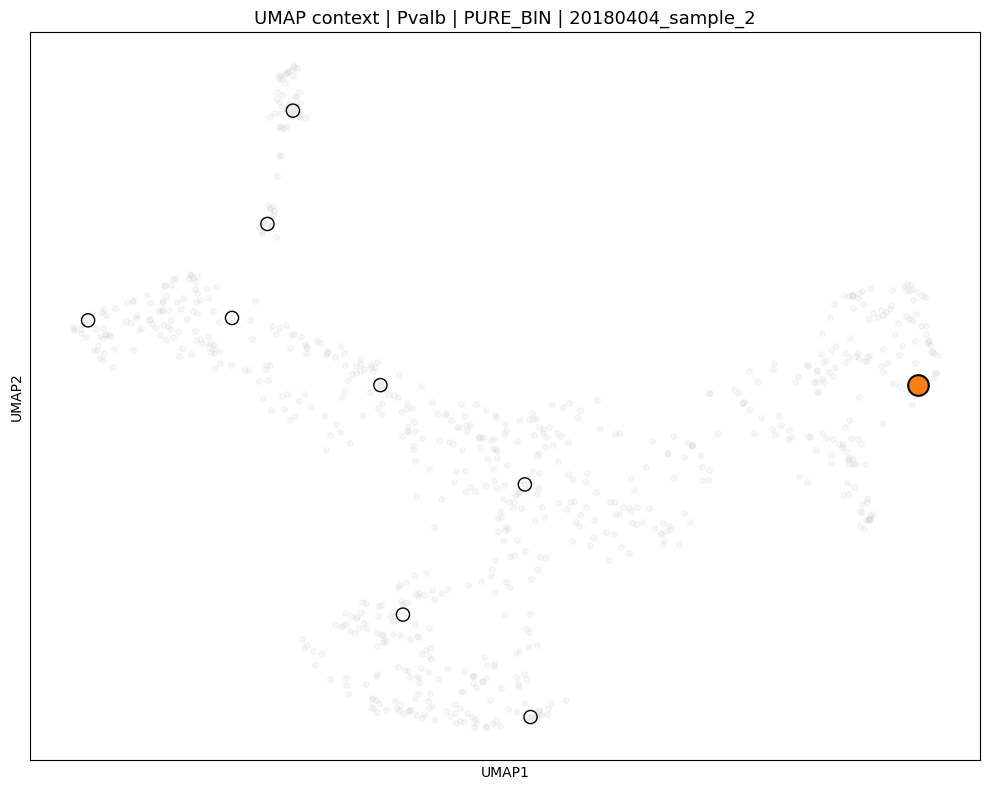

Saved: /content/umap_selected_cells_plots/Pvalb/PURE_BIN__20180404_sample_2/UMAP_selected_cell.png


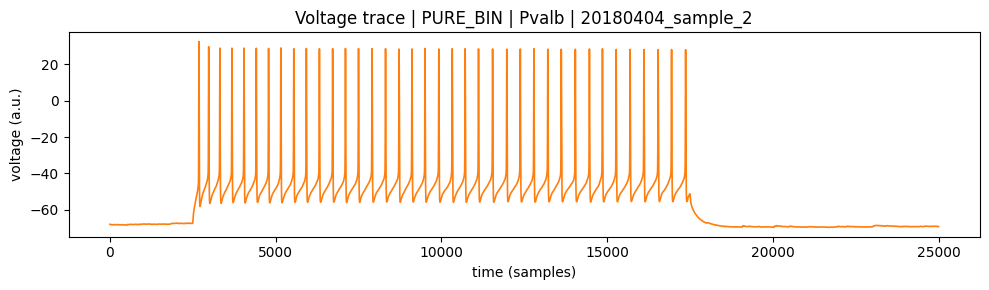

Saved: /content/umap_selected_cells_plots/Pvalb/PURE_BIN__20180404_sample_2/voltage.png


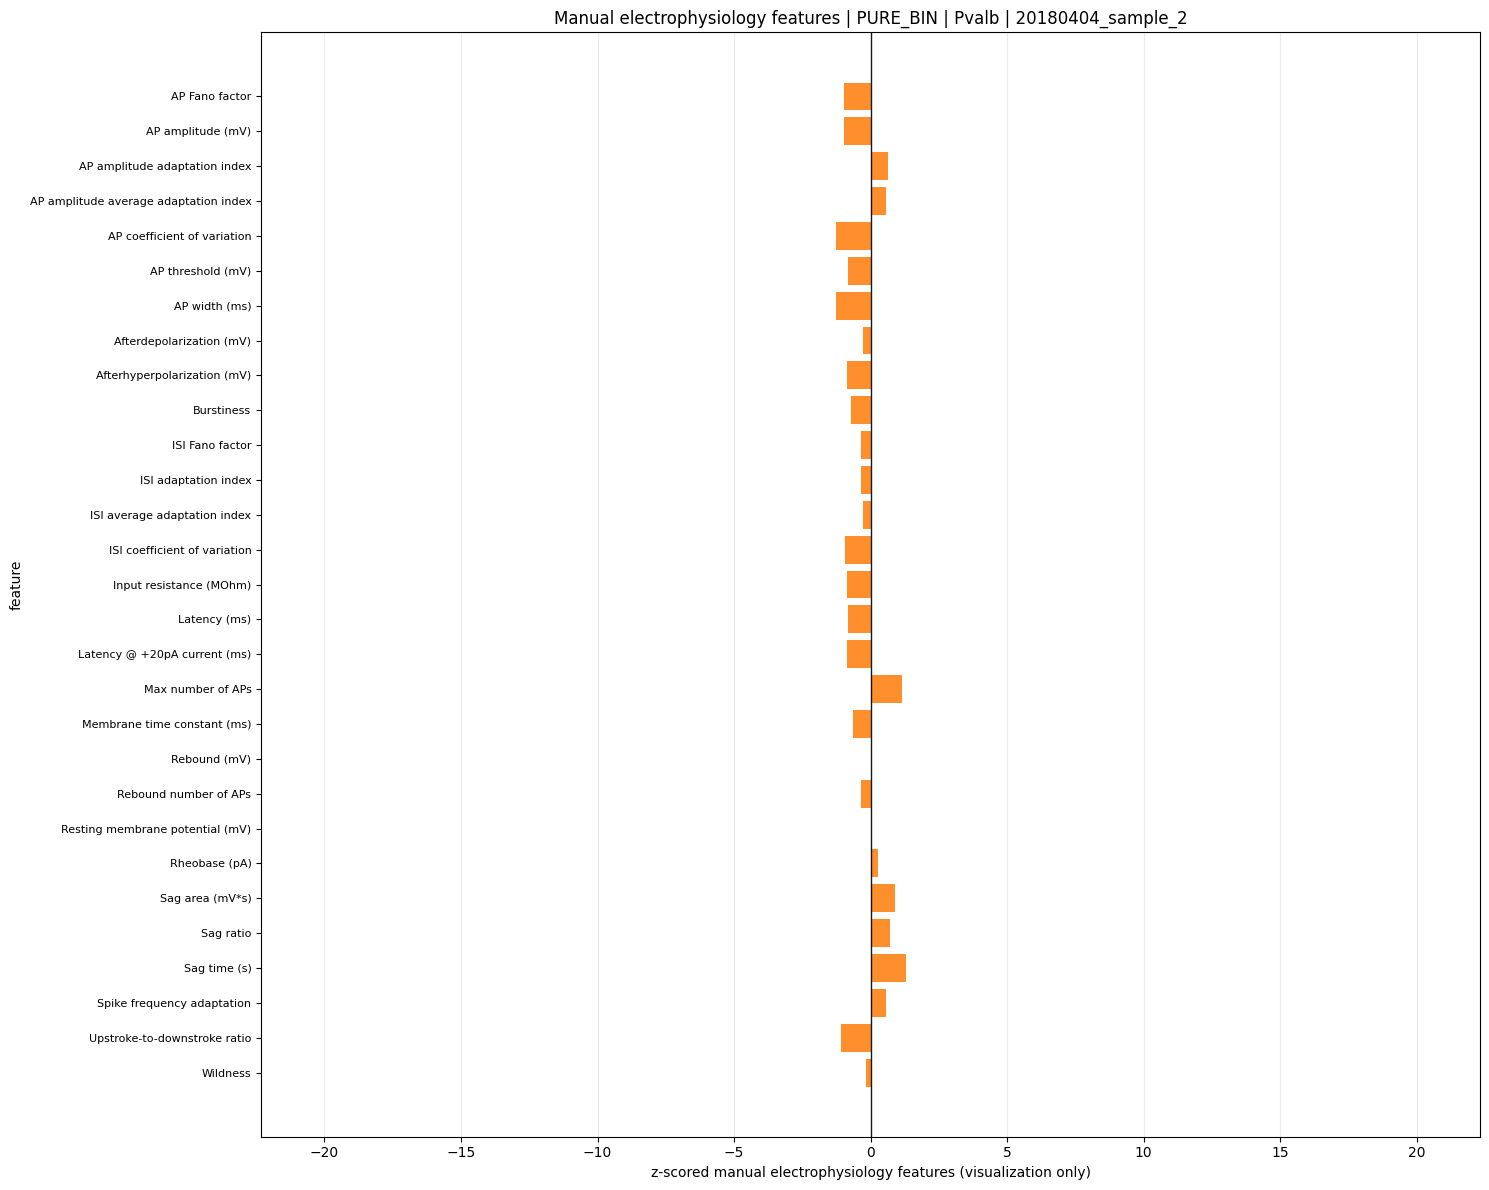

Saved: /content/umap_selected_cells_plots/Pvalb/PURE_BIN__20180404_sample_2/EPHYS_all_features_zscore.png


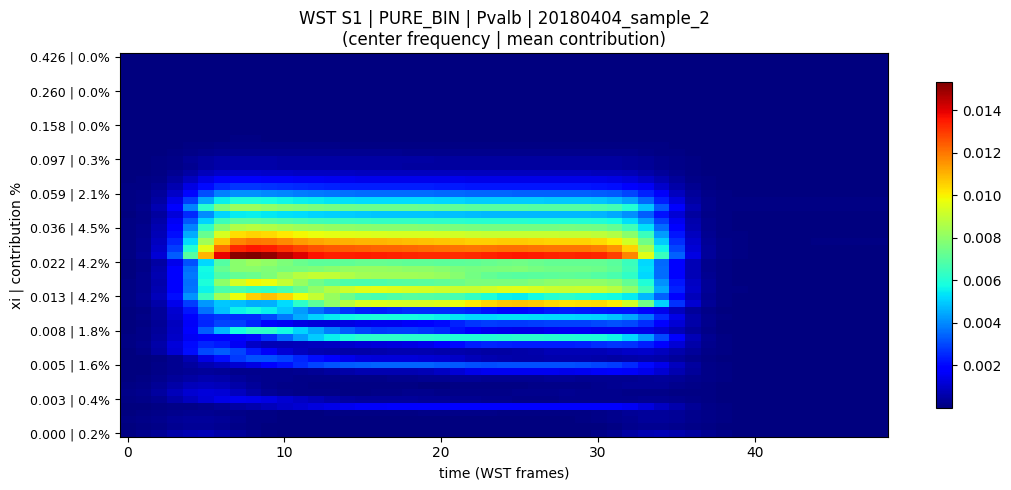

Saved: /content/umap_selected_cells_plots/Pvalb/PURE_BIN__20180404_sample_2/WST_S1.png


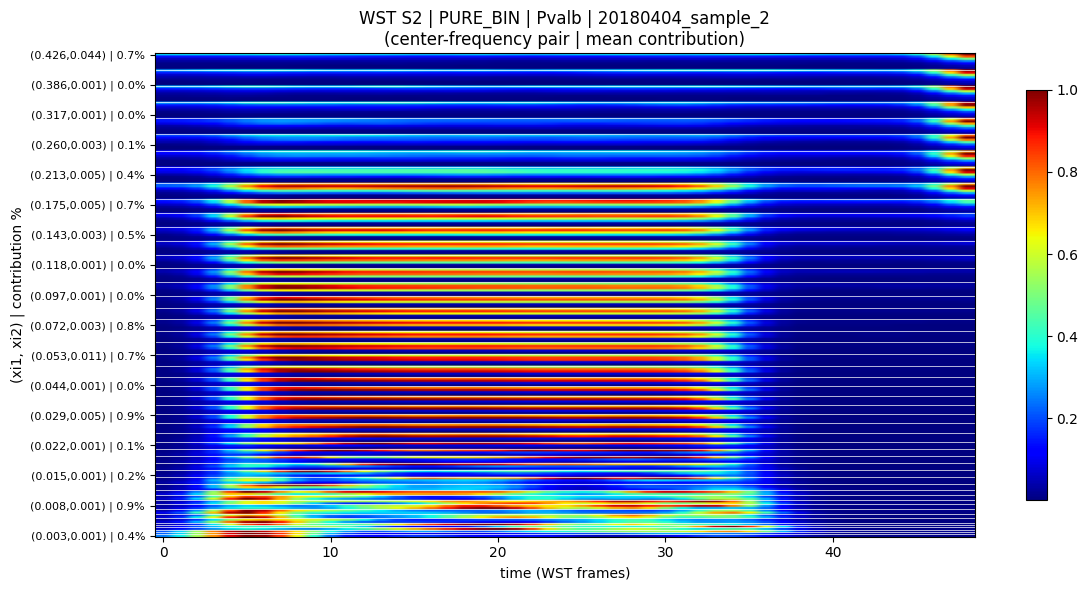

Saved: /content/umap_selected_cells_plots/Pvalb/PURE_BIN__20180404_sample_2/WST_S2.png
Completed cell folder: /content/umap_selected_cells_plots/Pvalb/PURE_BIN__20180404_sample_2


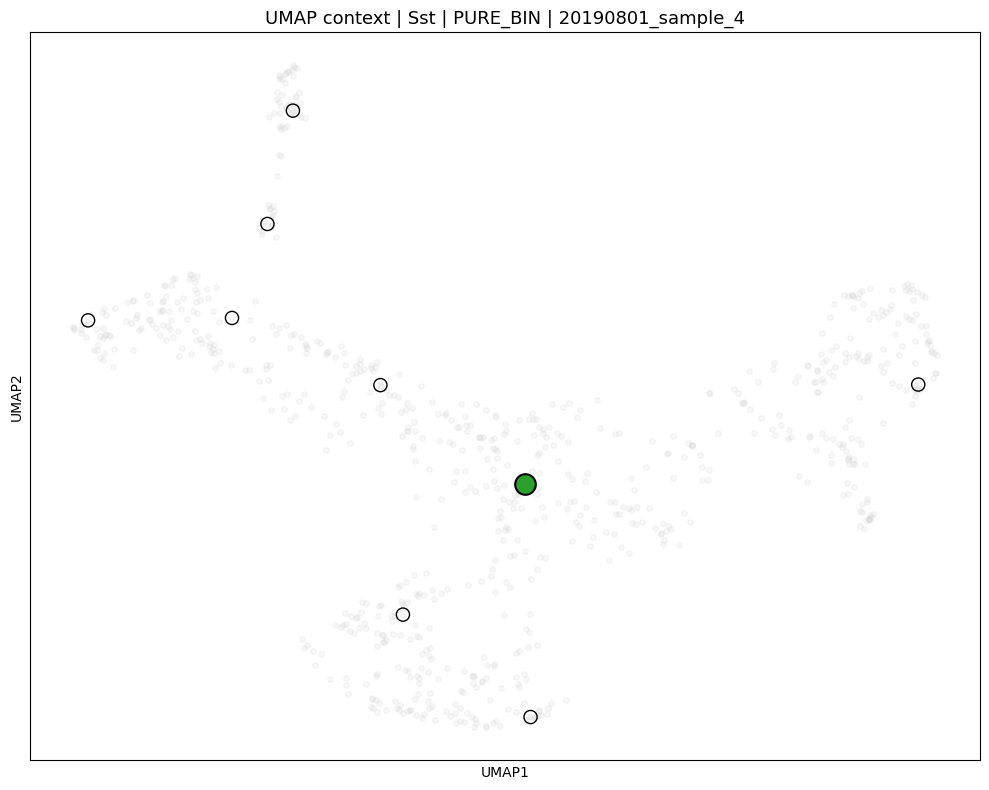

Saved: /content/umap_selected_cells_plots/Sst/PURE_BIN__20190801_sample_4/UMAP_selected_cell.png


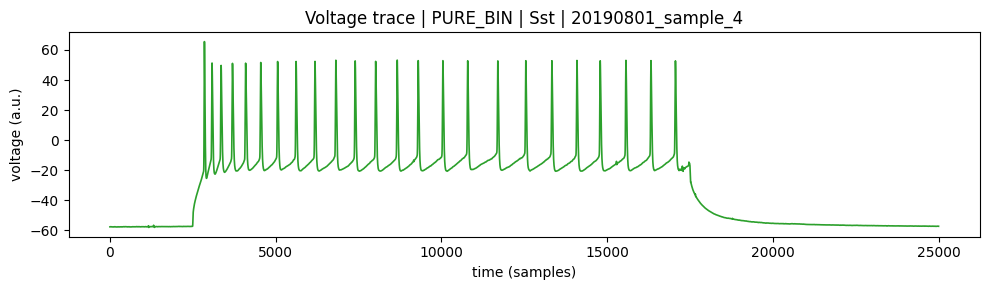

Saved: /content/umap_selected_cells_plots/Sst/PURE_BIN__20190801_sample_4/voltage.png


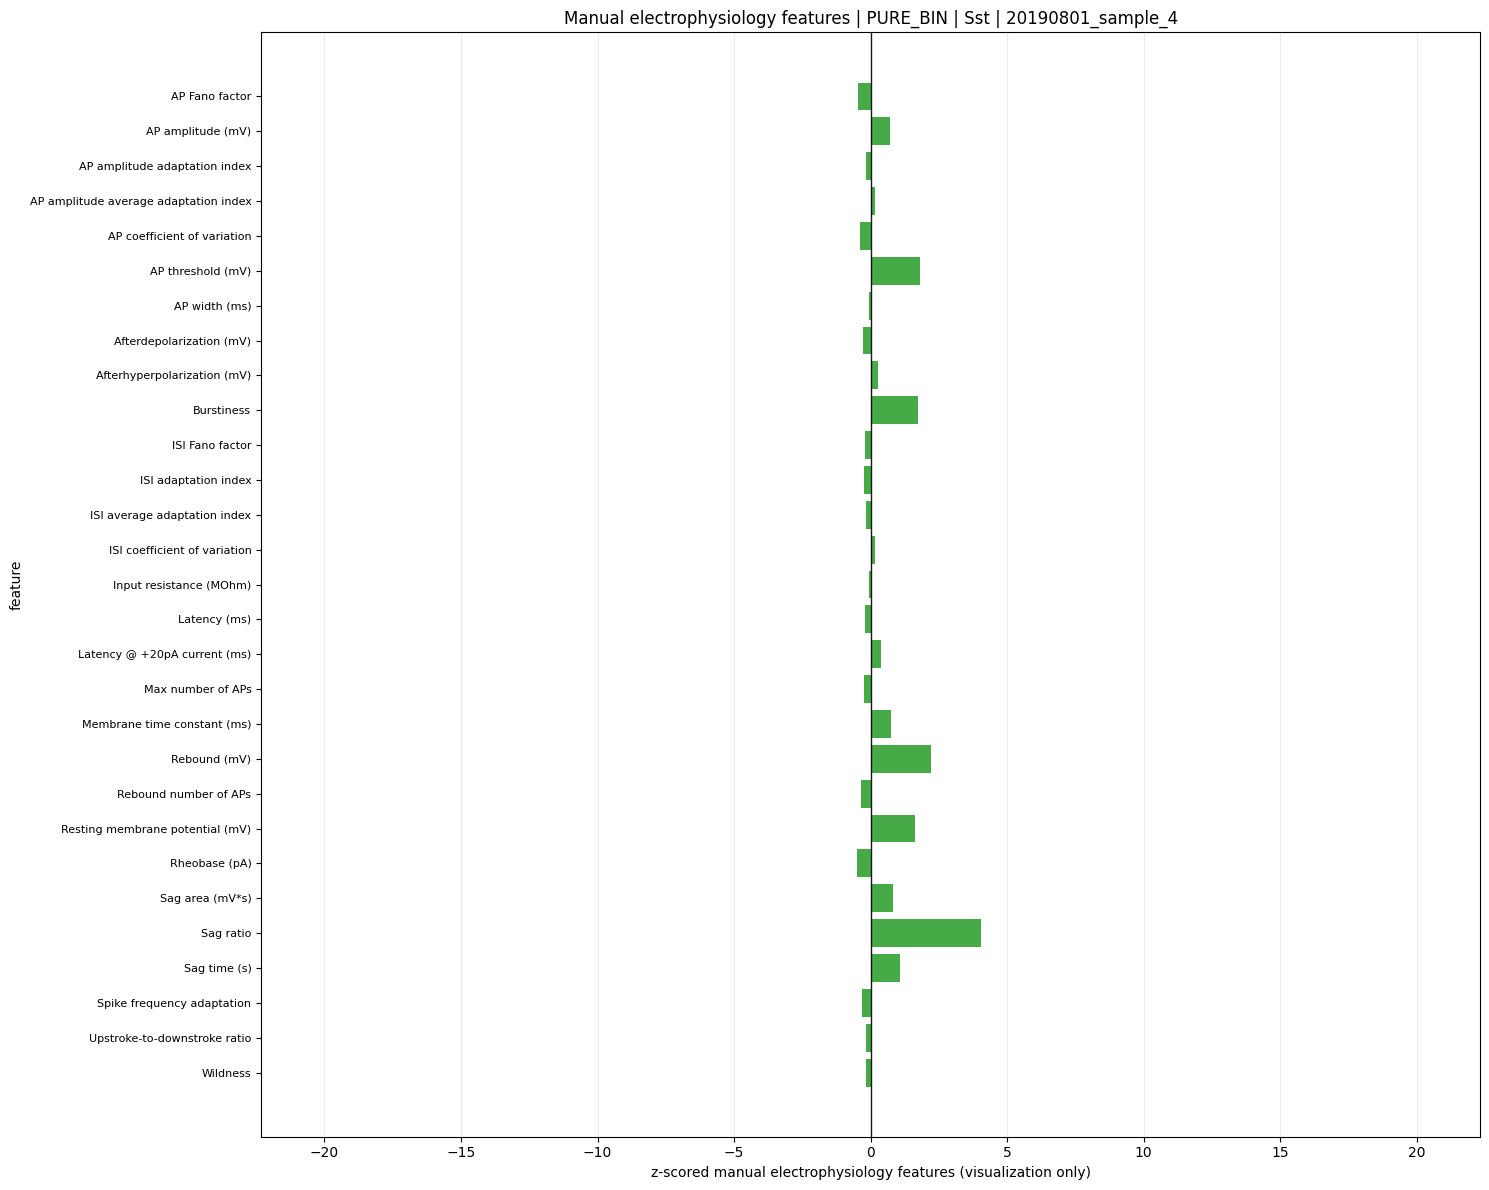

Saved: /content/umap_selected_cells_plots/Sst/PURE_BIN__20190801_sample_4/EPHYS_all_features_zscore.png


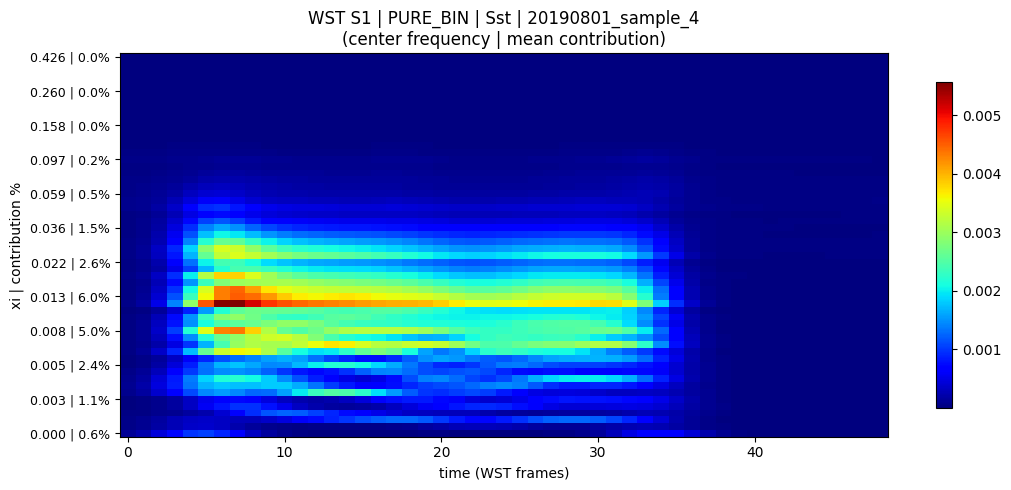

Saved: /content/umap_selected_cells_plots/Sst/PURE_BIN__20190801_sample_4/WST_S1.png


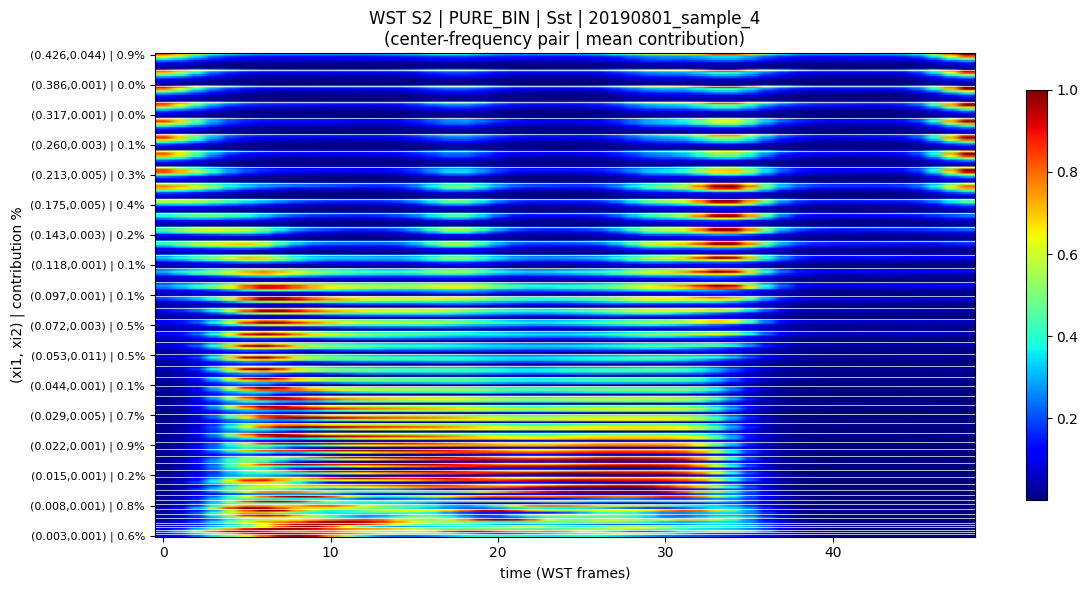

Saved: /content/umap_selected_cells_plots/Sst/PURE_BIN__20190801_sample_4/WST_S2.png
Completed cell folder: /content/umap_selected_cells_plots/Sst/PURE_BIN__20190801_sample_4


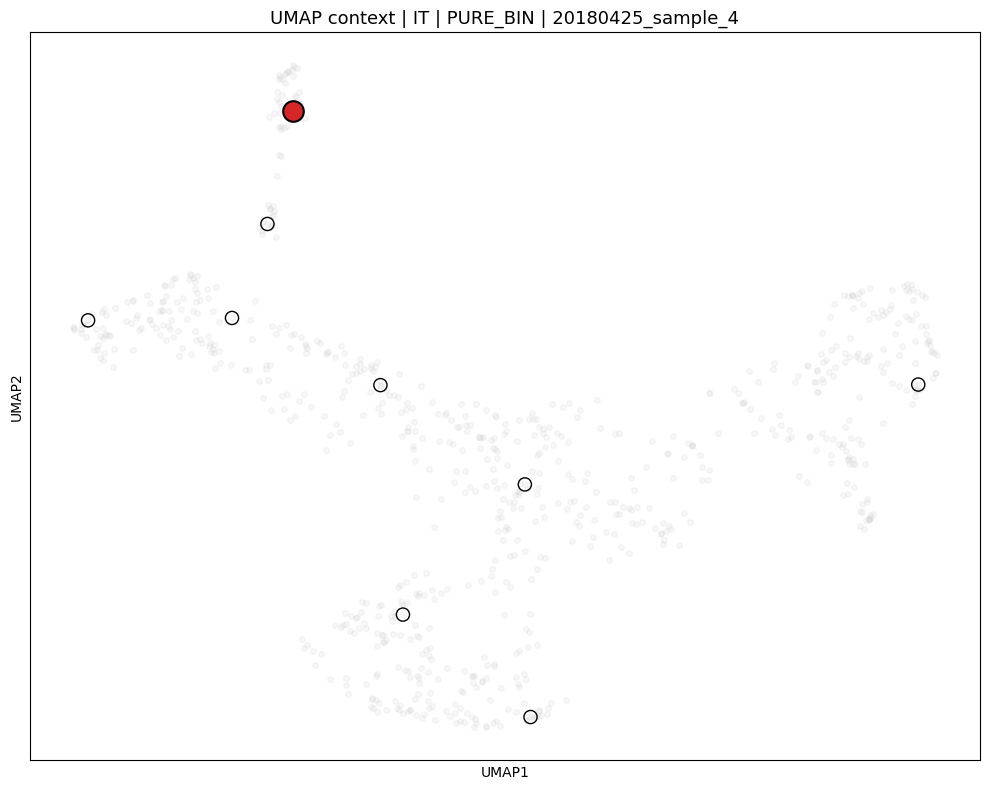

Saved: /content/umap_selected_cells_plots/IT/PURE_BIN__20180425_sample_4/UMAP_selected_cell.png


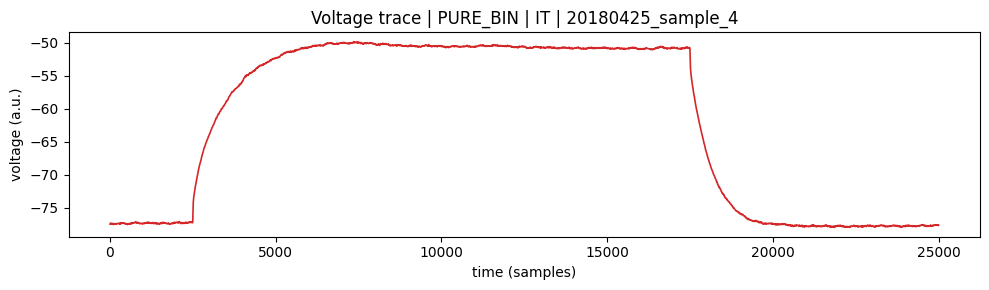

Saved: /content/umap_selected_cells_plots/IT/PURE_BIN__20180425_sample_4/voltage.png


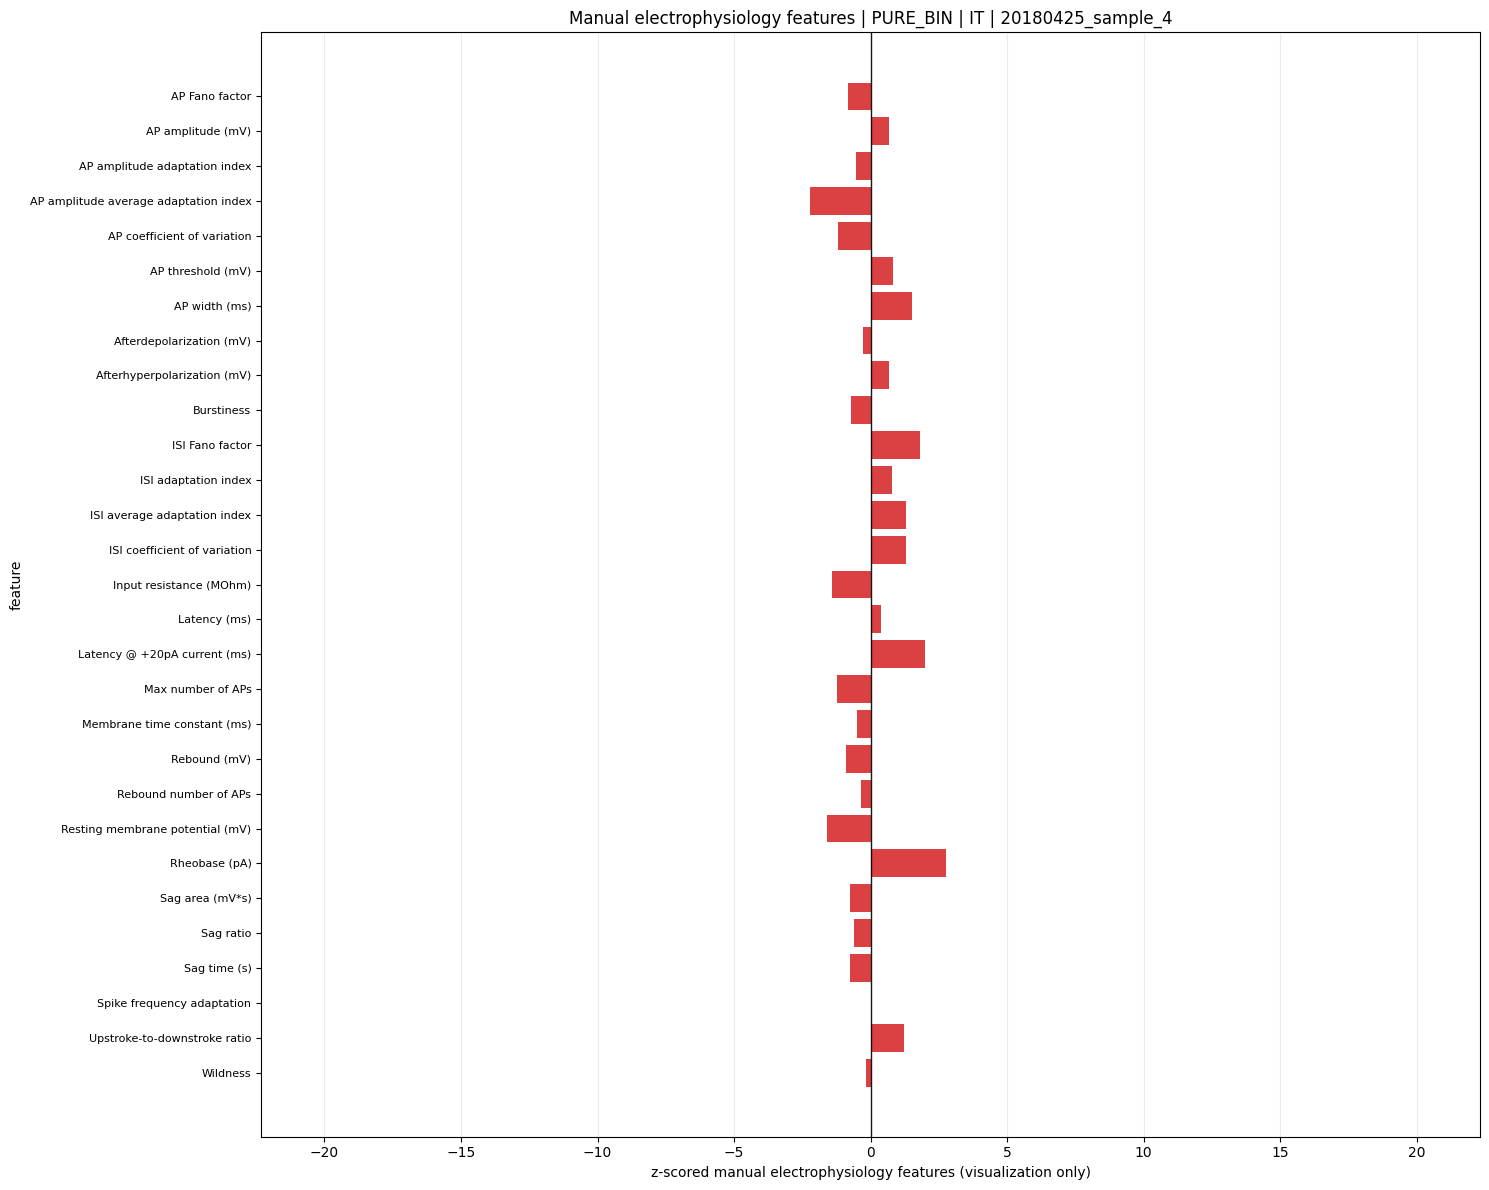

Saved: /content/umap_selected_cells_plots/IT/PURE_BIN__20180425_sample_4/EPHYS_all_features_zscore.png


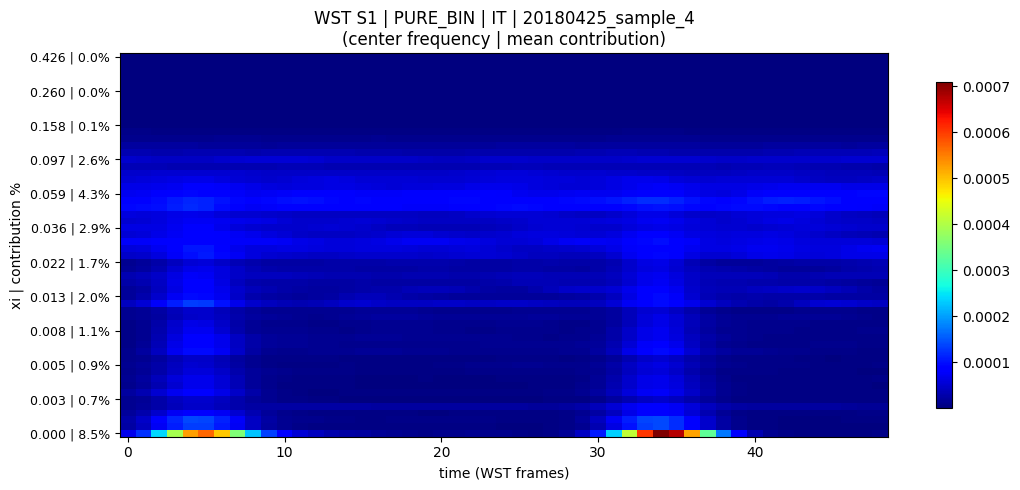

Saved: /content/umap_selected_cells_plots/IT/PURE_BIN__20180425_sample_4/WST_S1.png


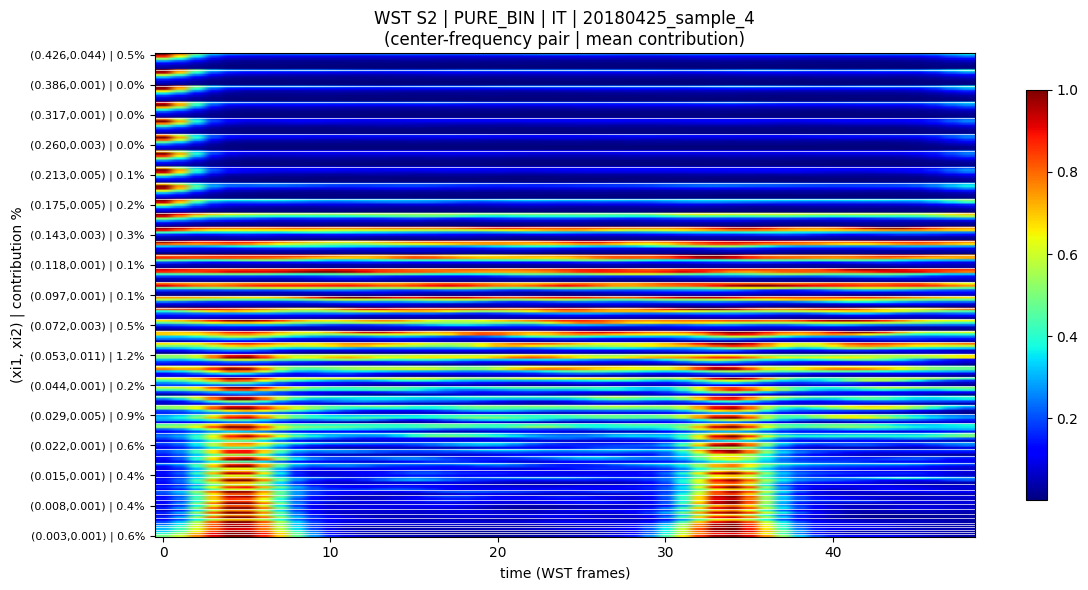

Saved: /content/umap_selected_cells_plots/IT/PURE_BIN__20180425_sample_4/WST_S2.png
Completed cell folder: /content/umap_selected_cells_plots/IT/PURE_BIN__20180425_sample_4


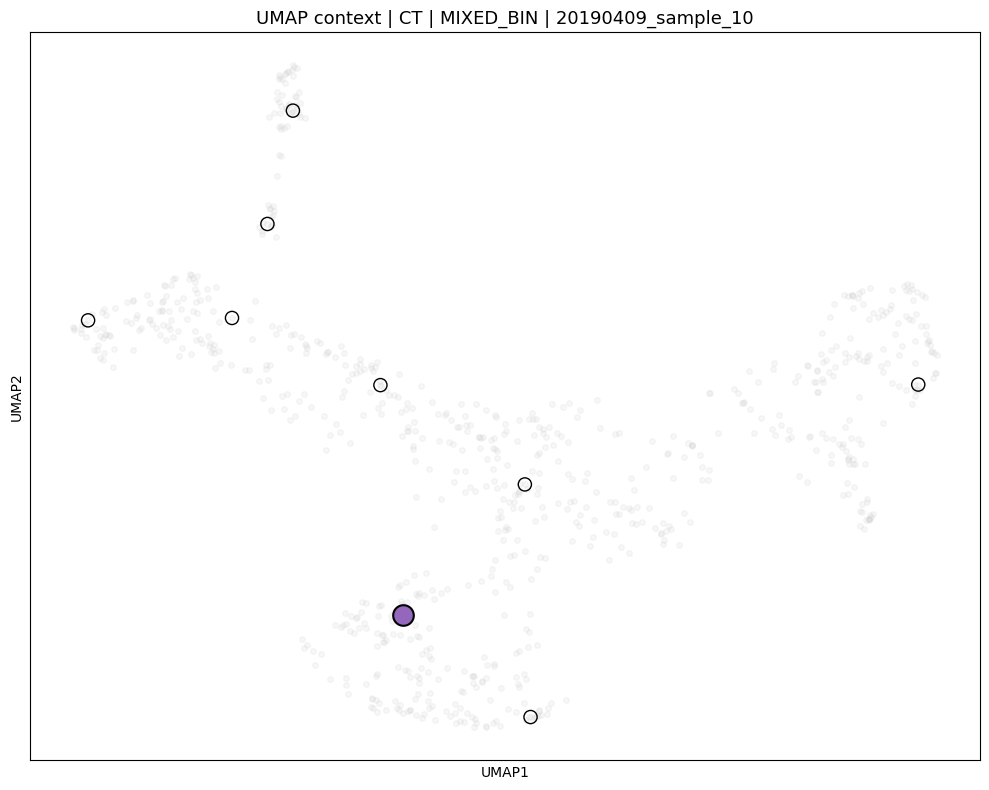

Saved: /content/umap_selected_cells_plots/CT/MIXED_BIN__20190409_sample_10/UMAP_selected_cell.png


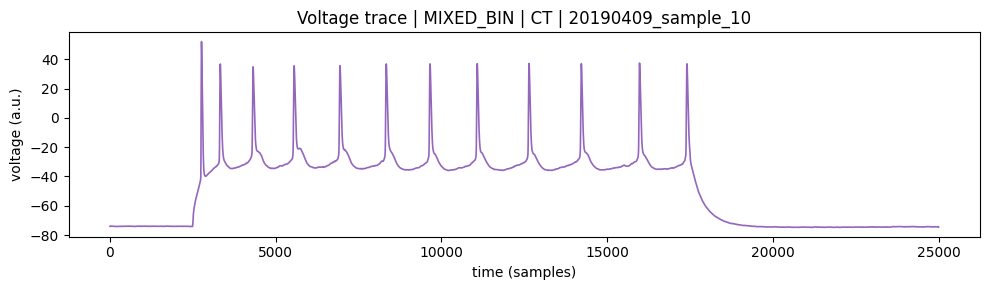

Saved: /content/umap_selected_cells_plots/CT/MIXED_BIN__20190409_sample_10/voltage.png


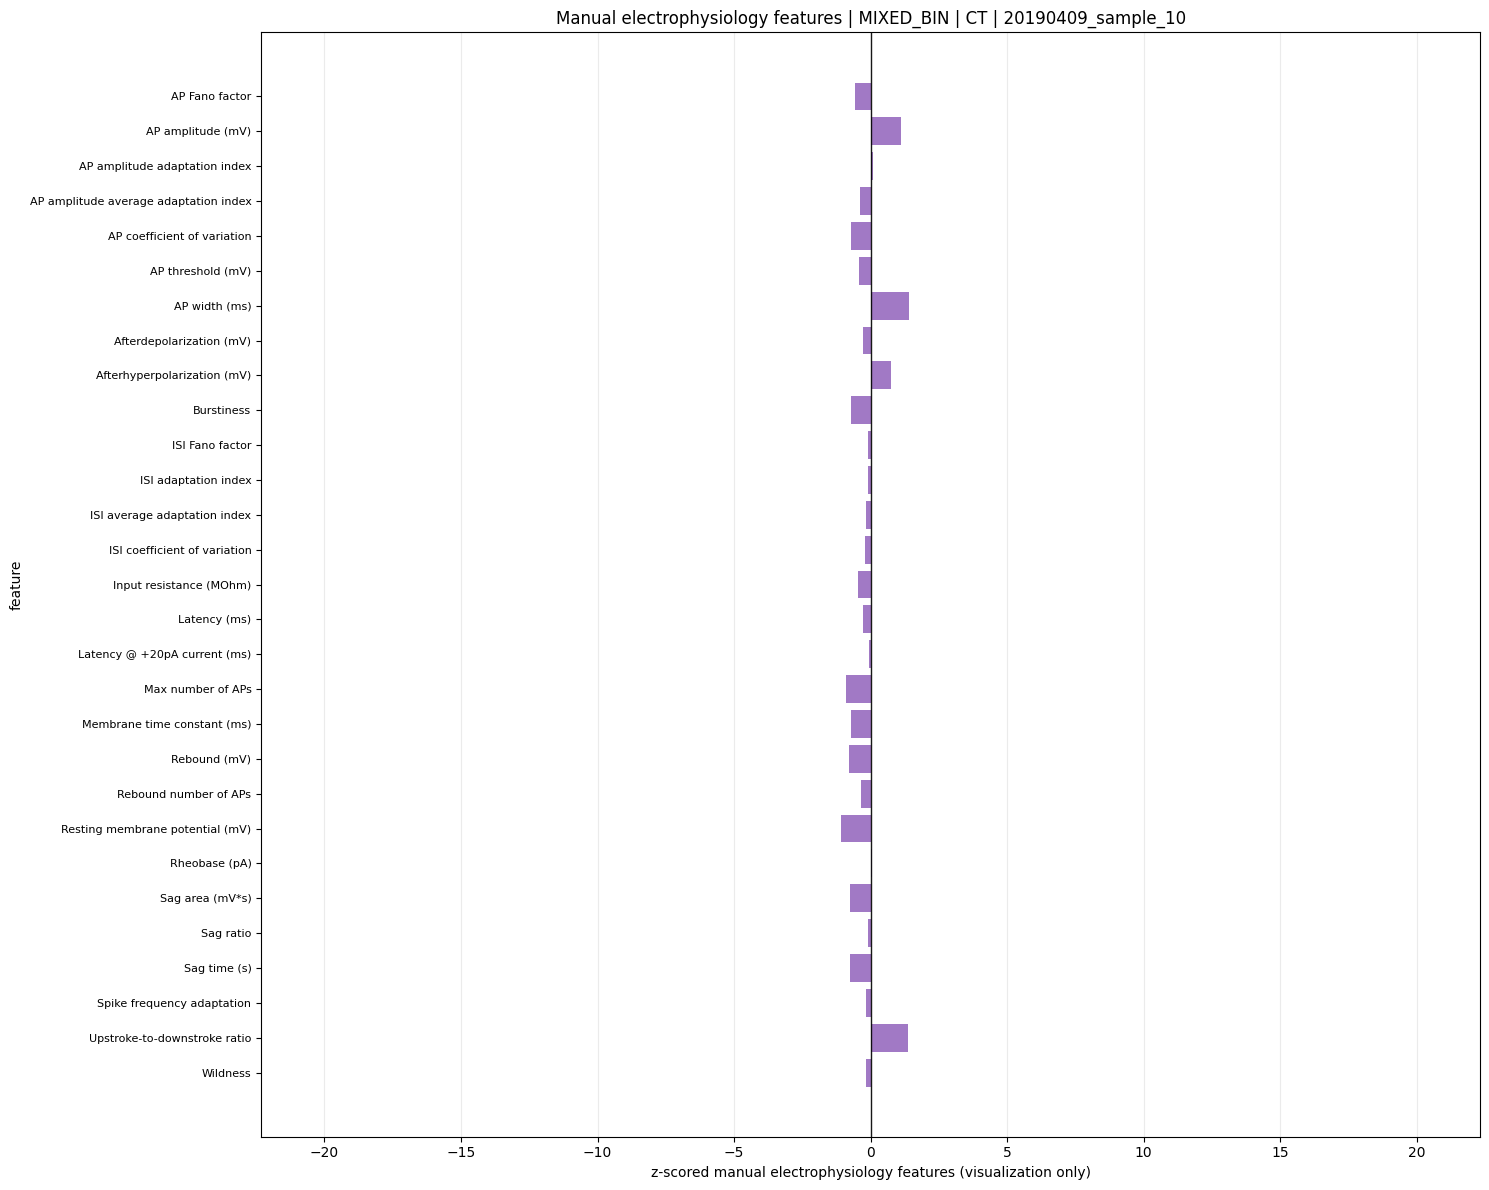

Saved: /content/umap_selected_cells_plots/CT/MIXED_BIN__20190409_sample_10/EPHYS_all_features_zscore.png


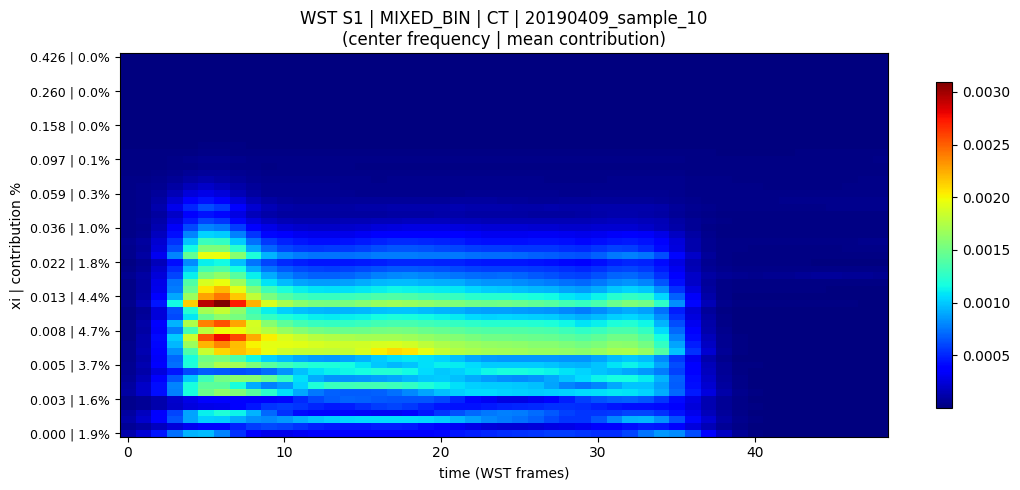

Saved: /content/umap_selected_cells_plots/CT/MIXED_BIN__20190409_sample_10/WST_S1.png


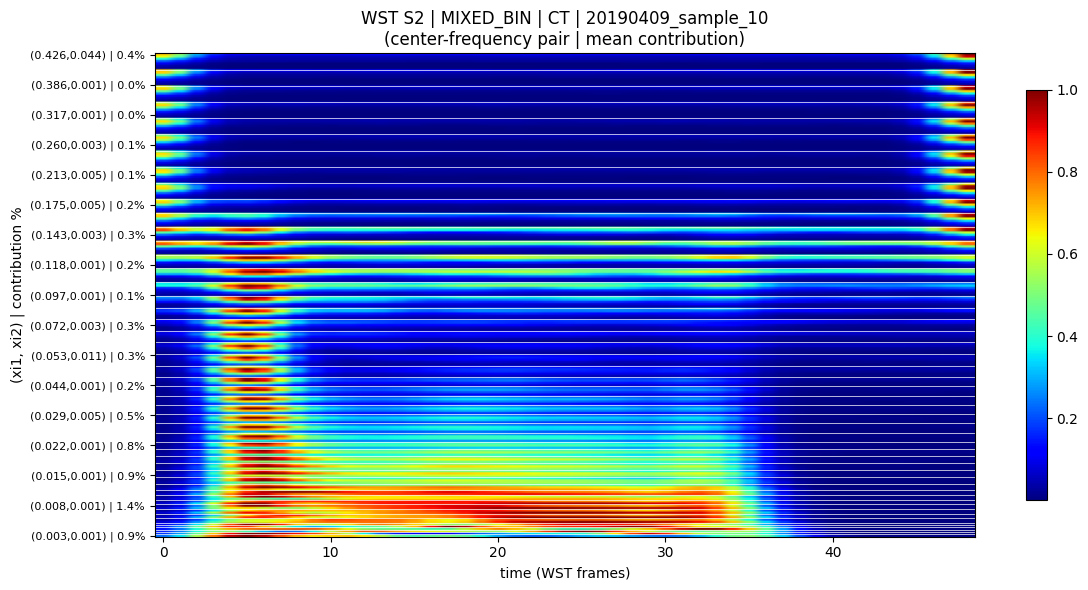

Saved: /content/umap_selected_cells_plots/CT/MIXED_BIN__20190409_sample_10/WST_S2.png
Completed cell folder: /content/umap_selected_cells_plots/CT/MIXED_BIN__20190409_sample_10


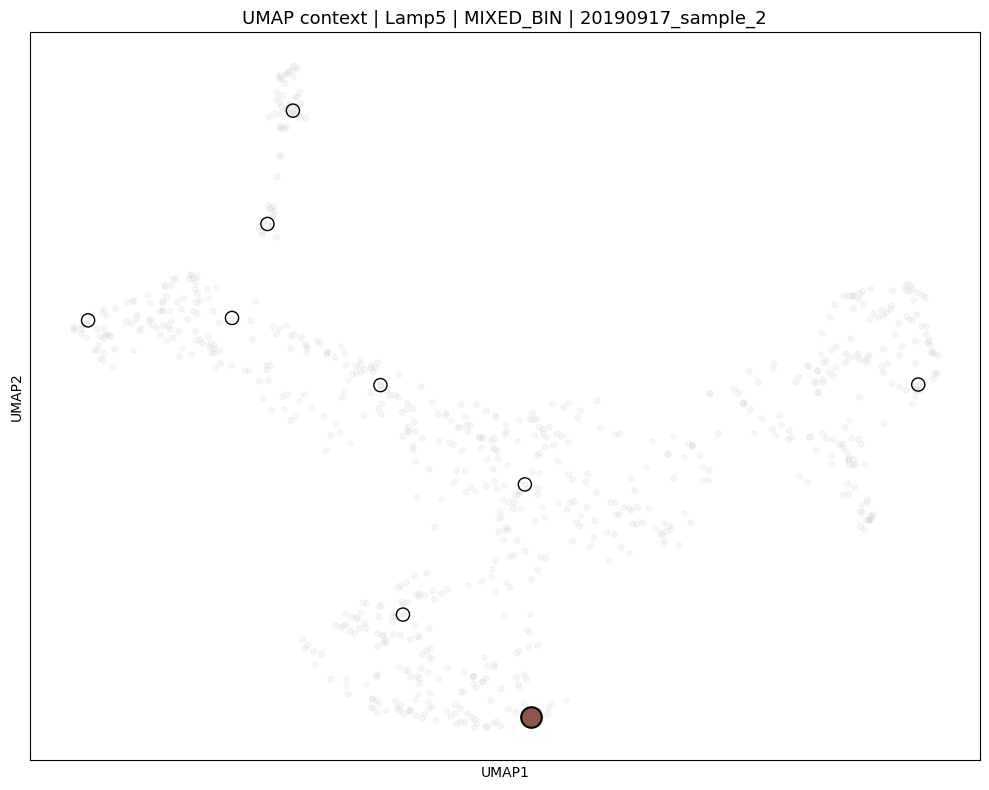

Saved: /content/umap_selected_cells_plots/Lamp5/MIXED_BIN__20190917_sample_2/UMAP_selected_cell.png


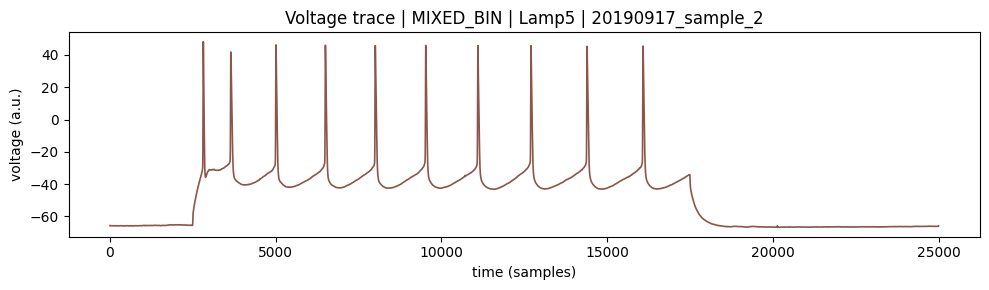

Saved: /content/umap_selected_cells_plots/Lamp5/MIXED_BIN__20190917_sample_2/voltage.png


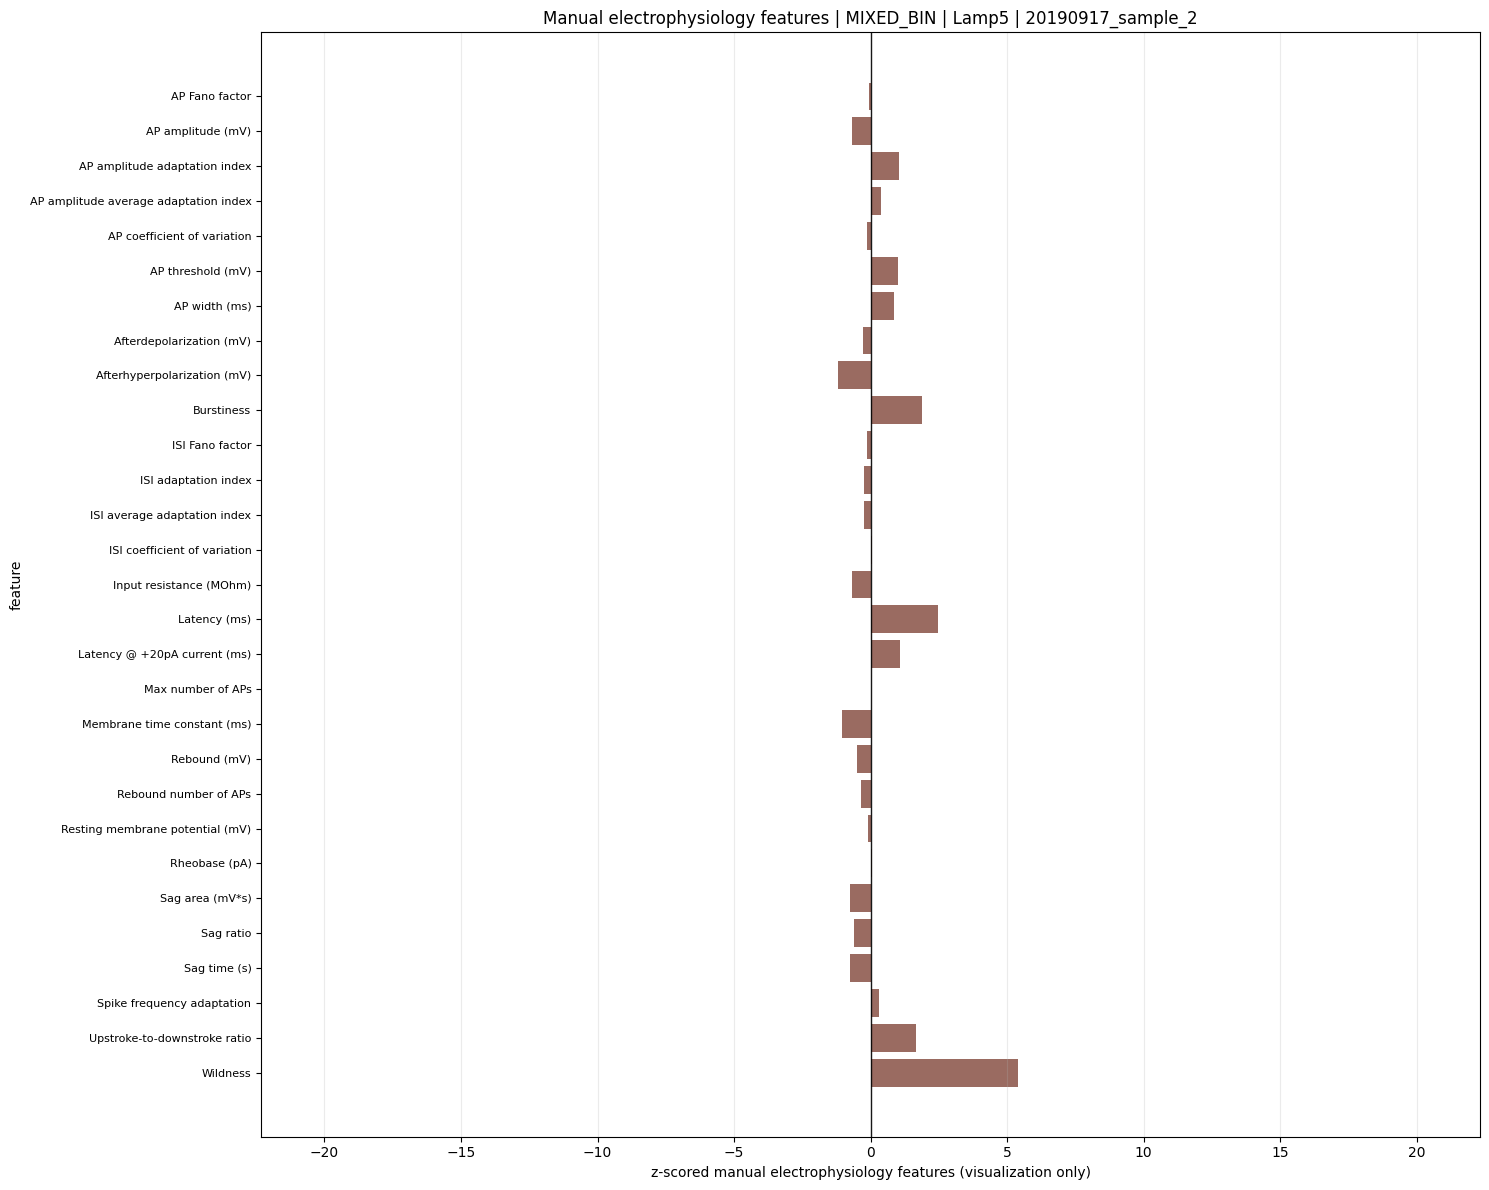

Saved: /content/umap_selected_cells_plots/Lamp5/MIXED_BIN__20190917_sample_2/EPHYS_all_features_zscore.png


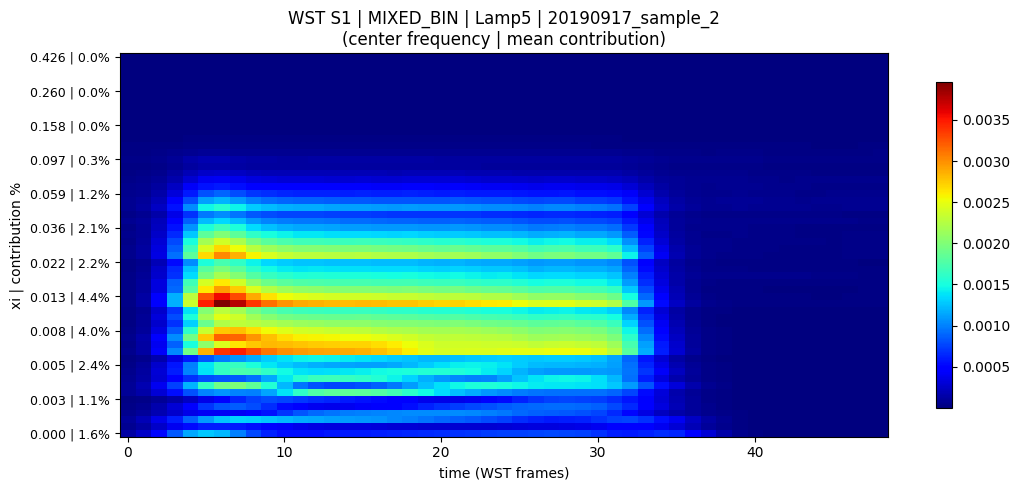

Saved: /content/umap_selected_cells_plots/Lamp5/MIXED_BIN__20190917_sample_2/WST_S1.png


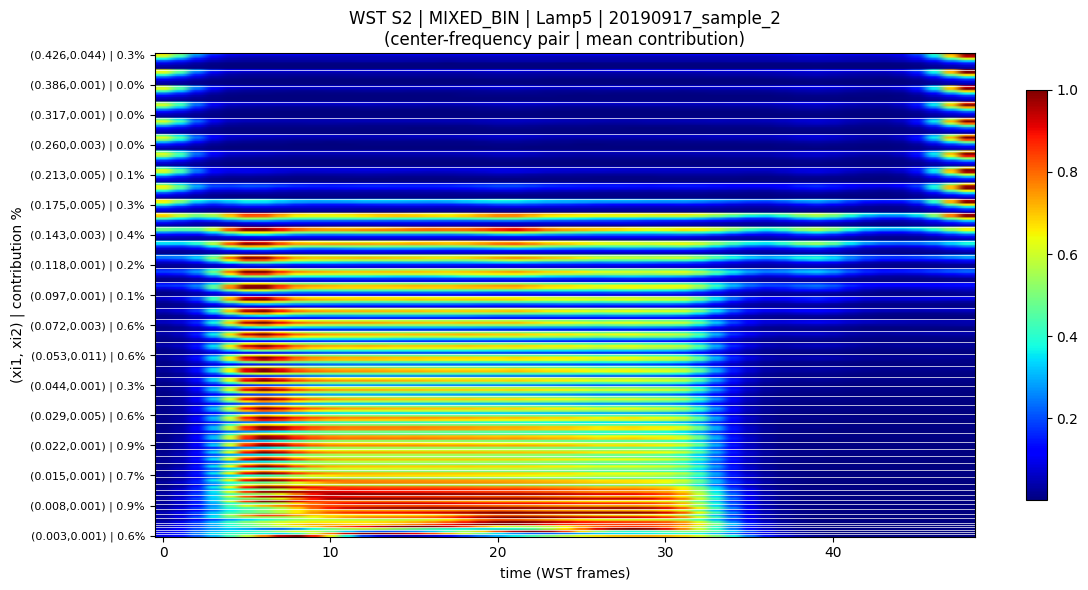

Saved: /content/umap_selected_cells_plots/Lamp5/MIXED_BIN__20190917_sample_2/WST_S2.png
Completed cell folder: /content/umap_selected_cells_plots/Lamp5/MIXED_BIN__20190917_sample_2


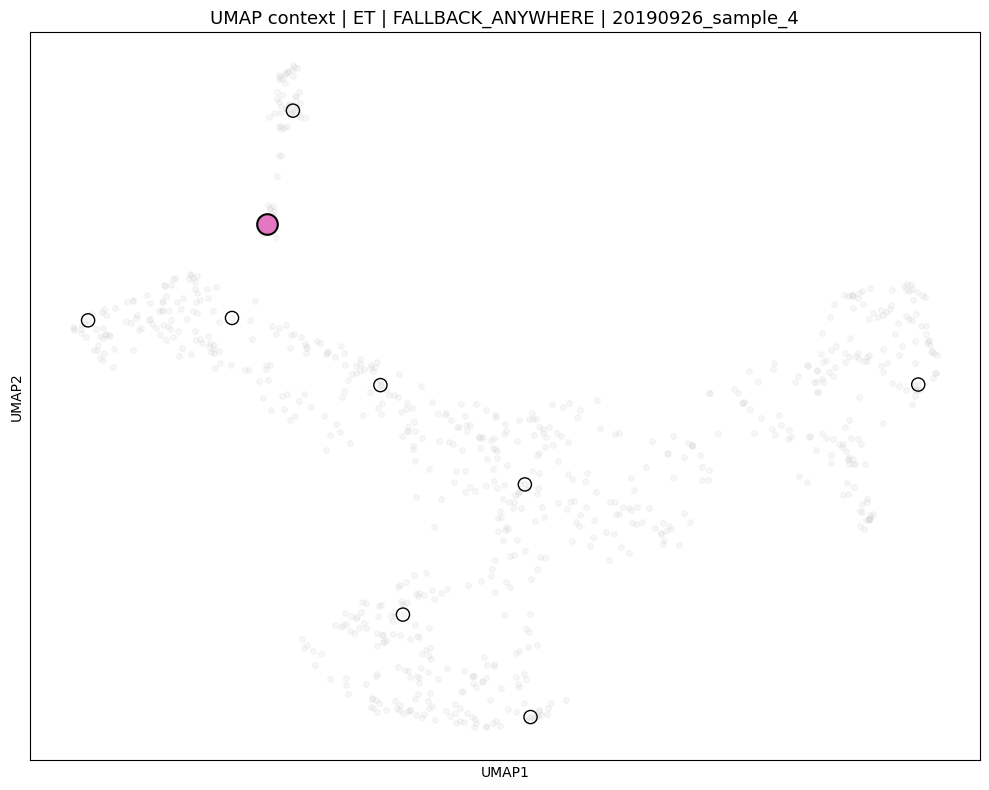

Saved: /content/umap_selected_cells_plots/ET/FALLBACK_ANYWHERE__20190926_sample_4/UMAP_selected_cell.png


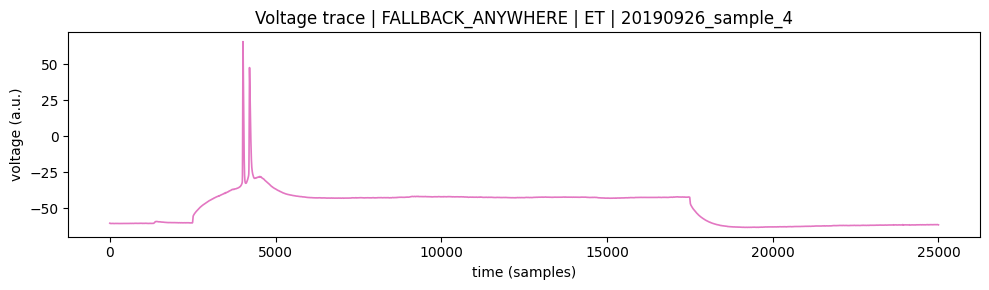

Saved: /content/umap_selected_cells_plots/ET/FALLBACK_ANYWHERE__20190926_sample_4/voltage.png


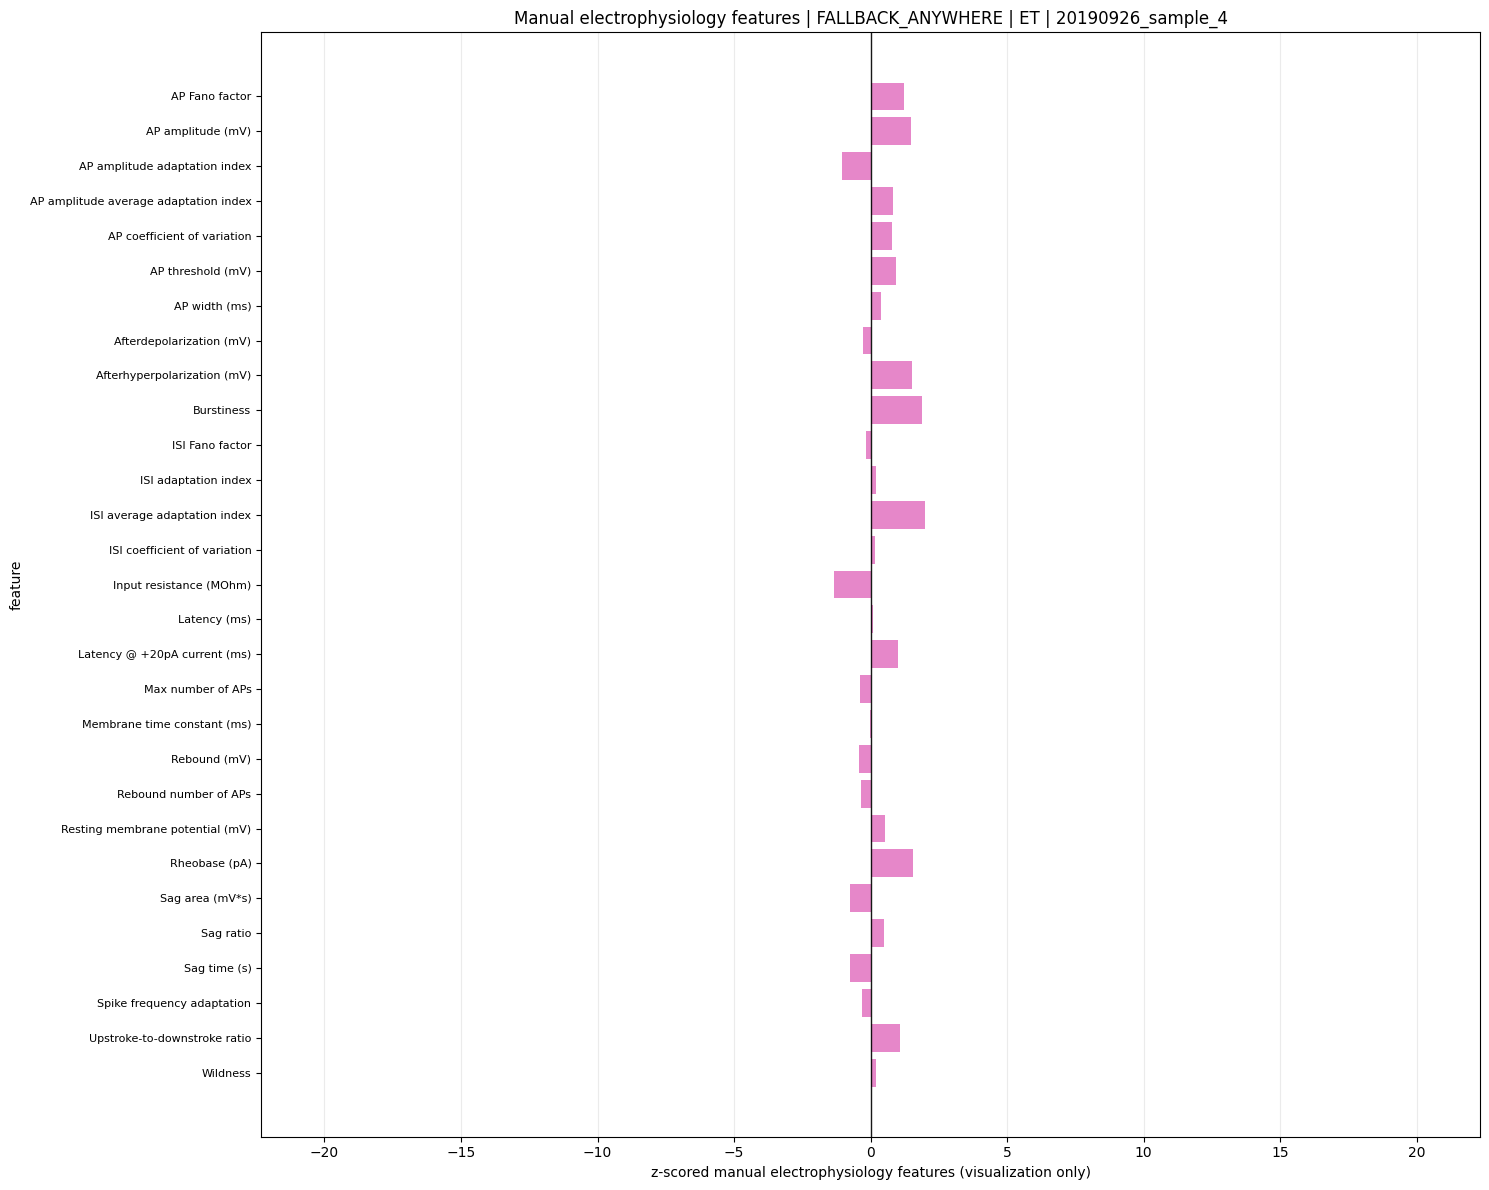

Saved: /content/umap_selected_cells_plots/ET/FALLBACK_ANYWHERE__20190926_sample_4/EPHYS_all_features_zscore.png


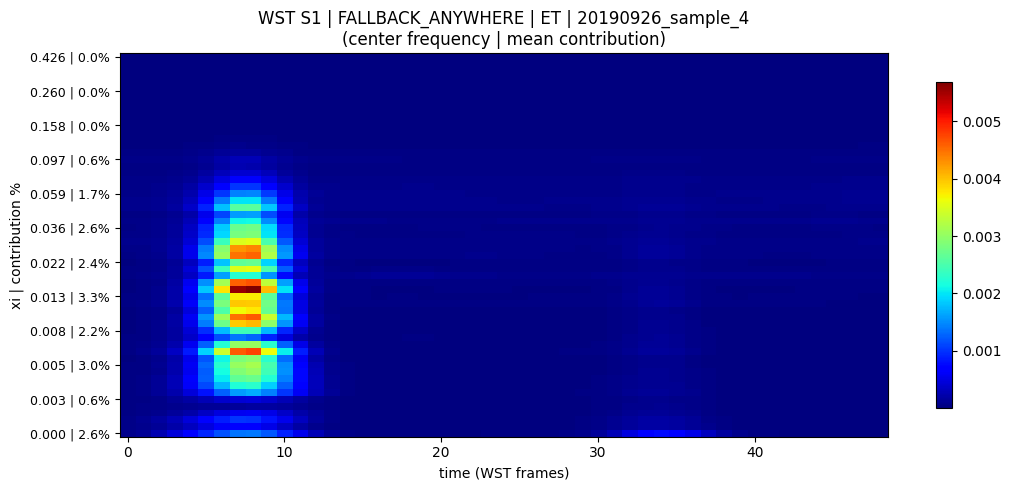

Saved: /content/umap_selected_cells_plots/ET/FALLBACK_ANYWHERE__20190926_sample_4/WST_S1.png


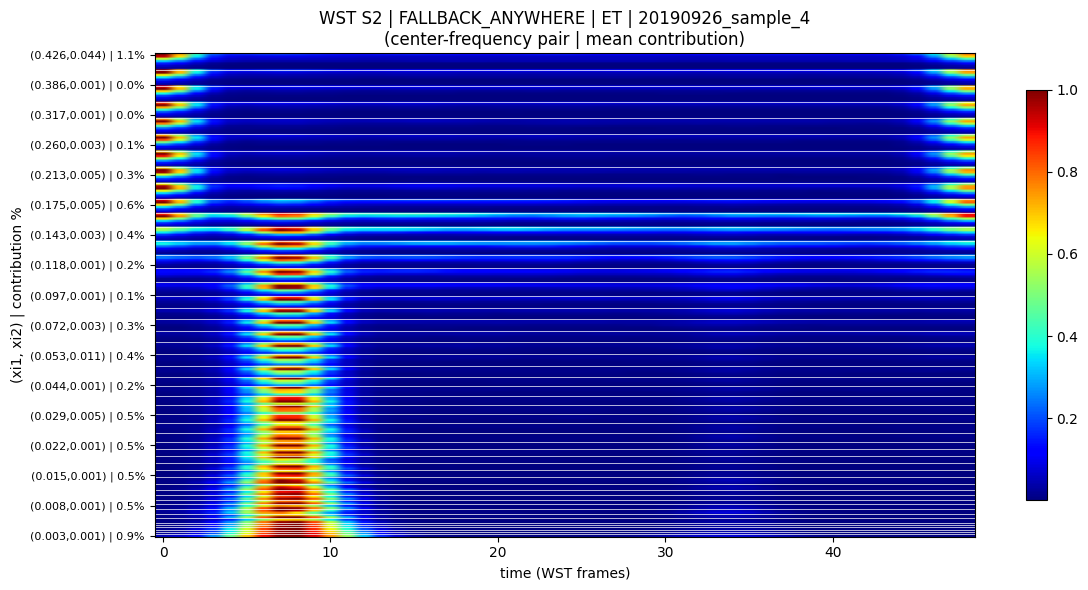

Saved: /content/umap_selected_cells_plots/ET/FALLBACK_ANYWHERE__20190926_sample_4/WST_S2.png
Completed cell folder: /content/umap_selected_cells_plots/ET/FALLBACK_ANYWHERE__20190926_sample_4


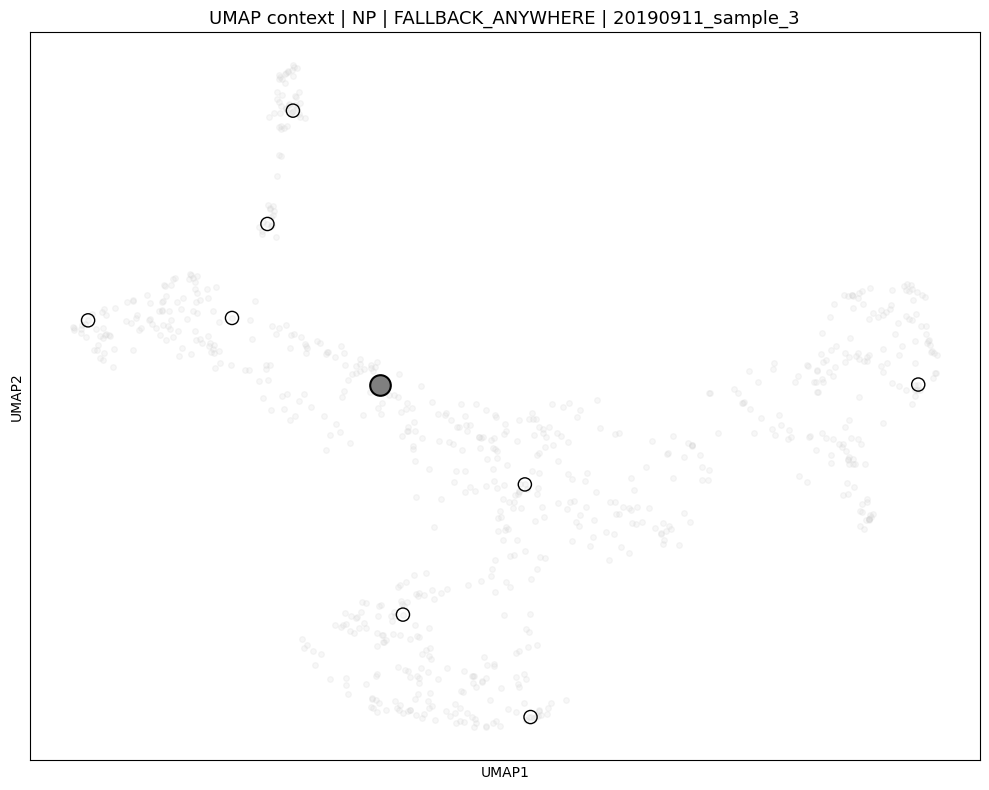

Saved: /content/umap_selected_cells_plots/NP/FALLBACK_ANYWHERE__20190911_sample_3/UMAP_selected_cell.png


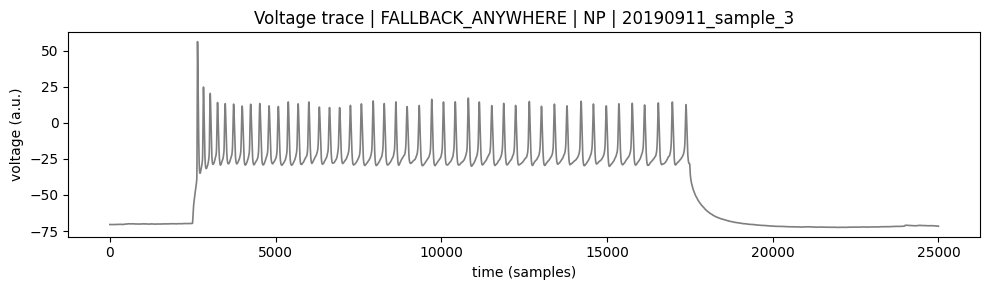

Saved: /content/umap_selected_cells_plots/NP/FALLBACK_ANYWHERE__20190911_sample_3/voltage.png


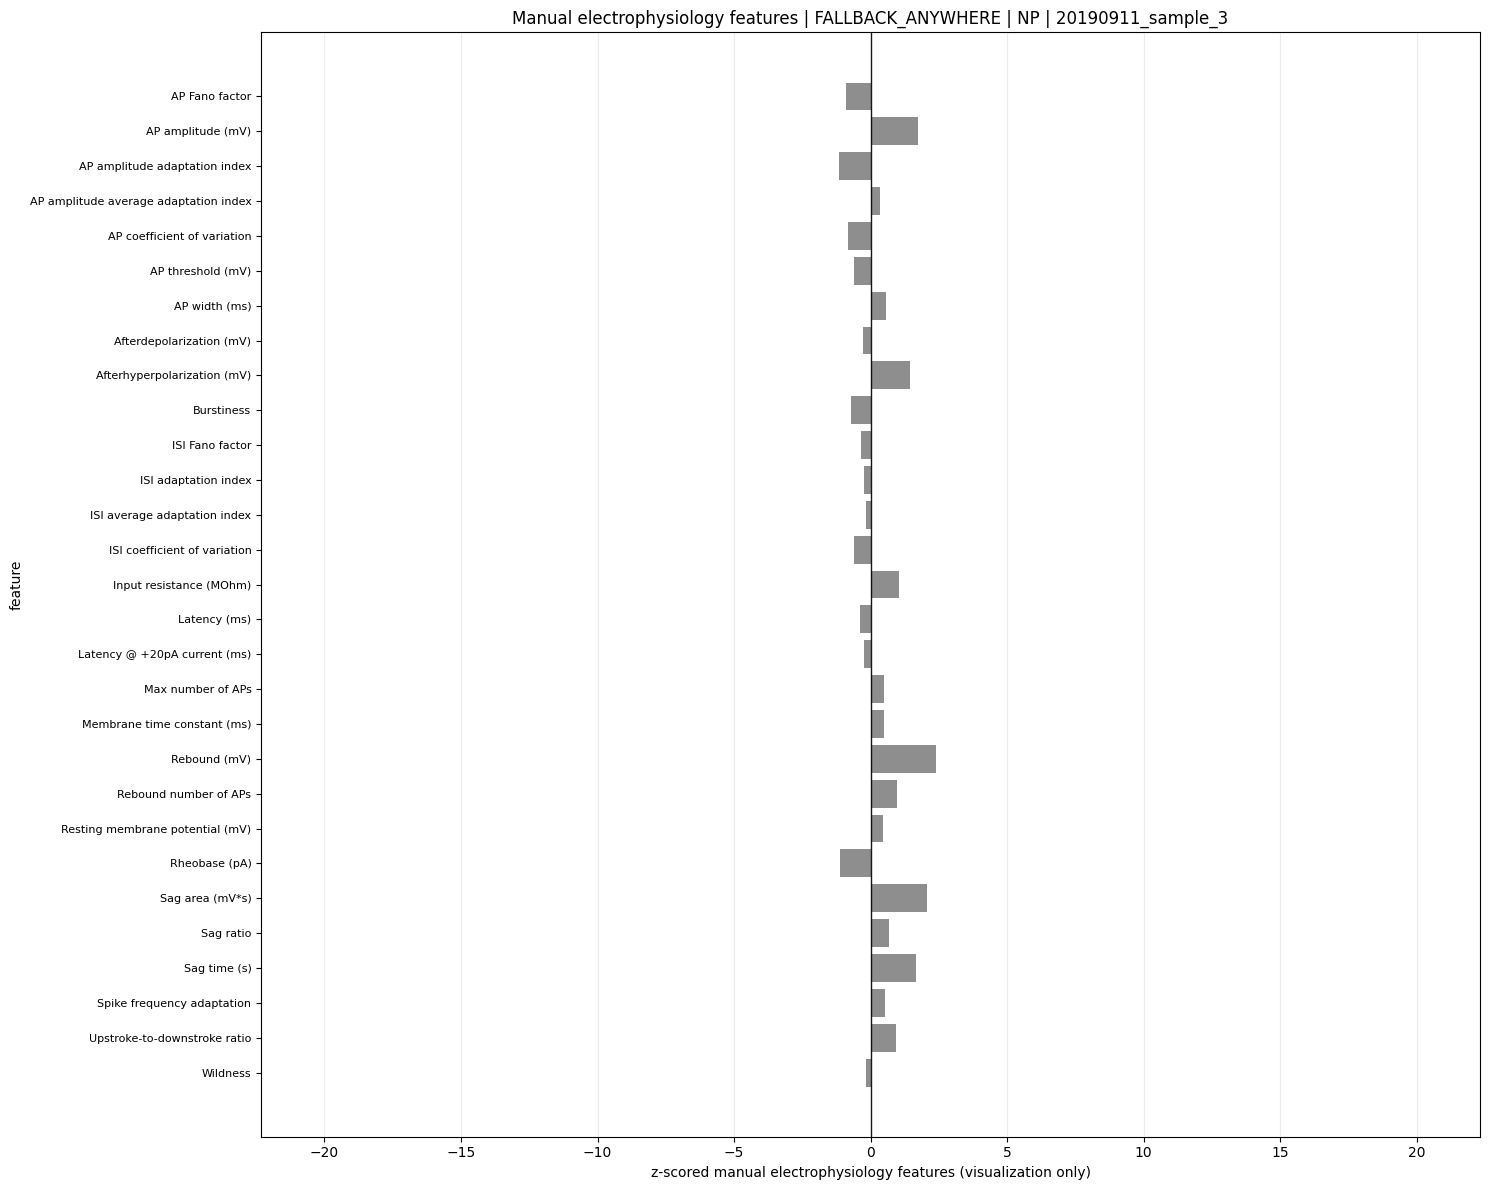

Saved: /content/umap_selected_cells_plots/NP/FALLBACK_ANYWHERE__20190911_sample_3/EPHYS_all_features_zscore.png


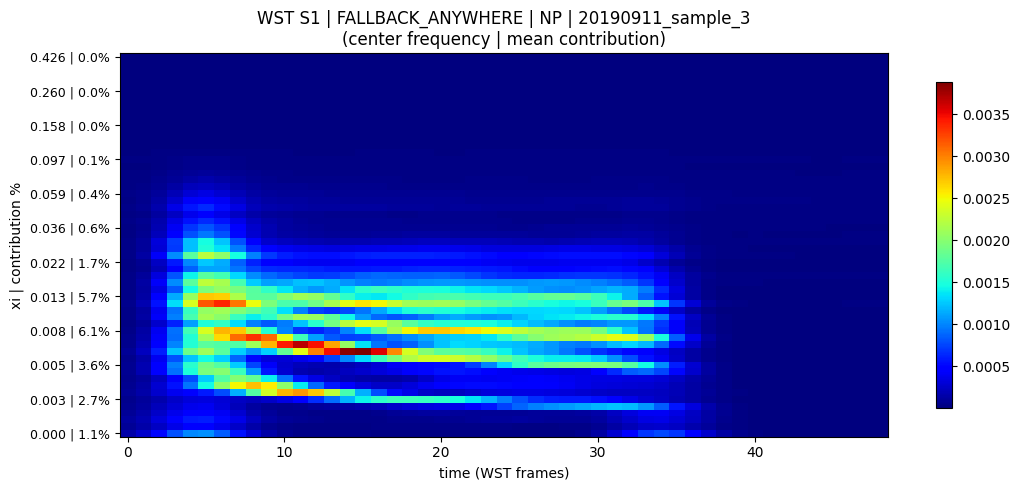

Saved: /content/umap_selected_cells_plots/NP/FALLBACK_ANYWHERE__20190911_sample_3/WST_S1.png


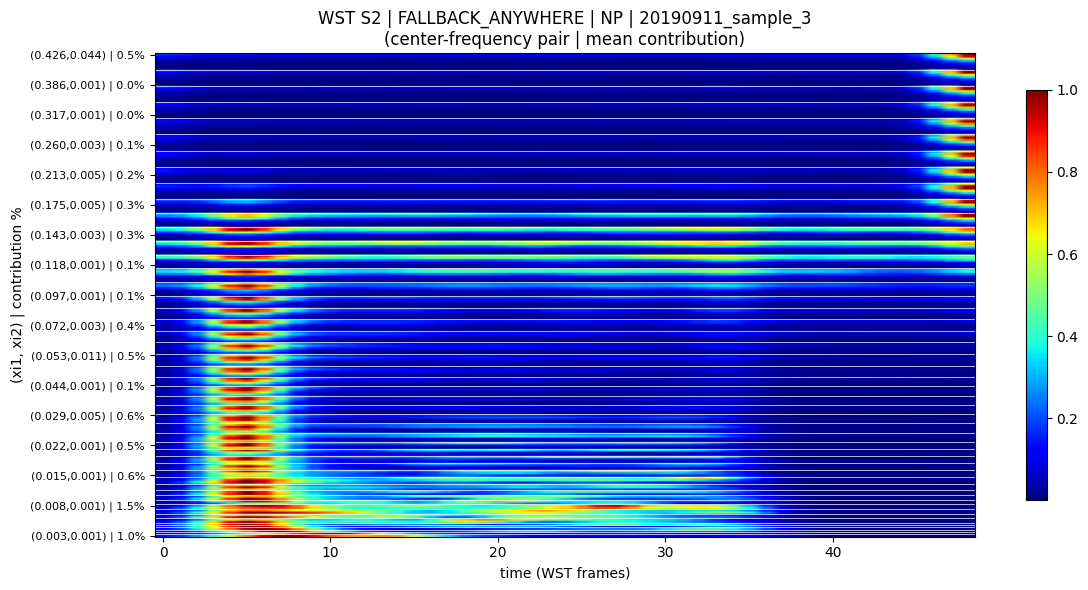

Saved: /content/umap_selected_cells_plots/NP/FALLBACK_ANYWHERE__20190911_sample_3/WST_S2.png
Completed cell folder: /content/umap_selected_cells_plots/NP/FALLBACK_ANYWHERE__20190911_sample_3


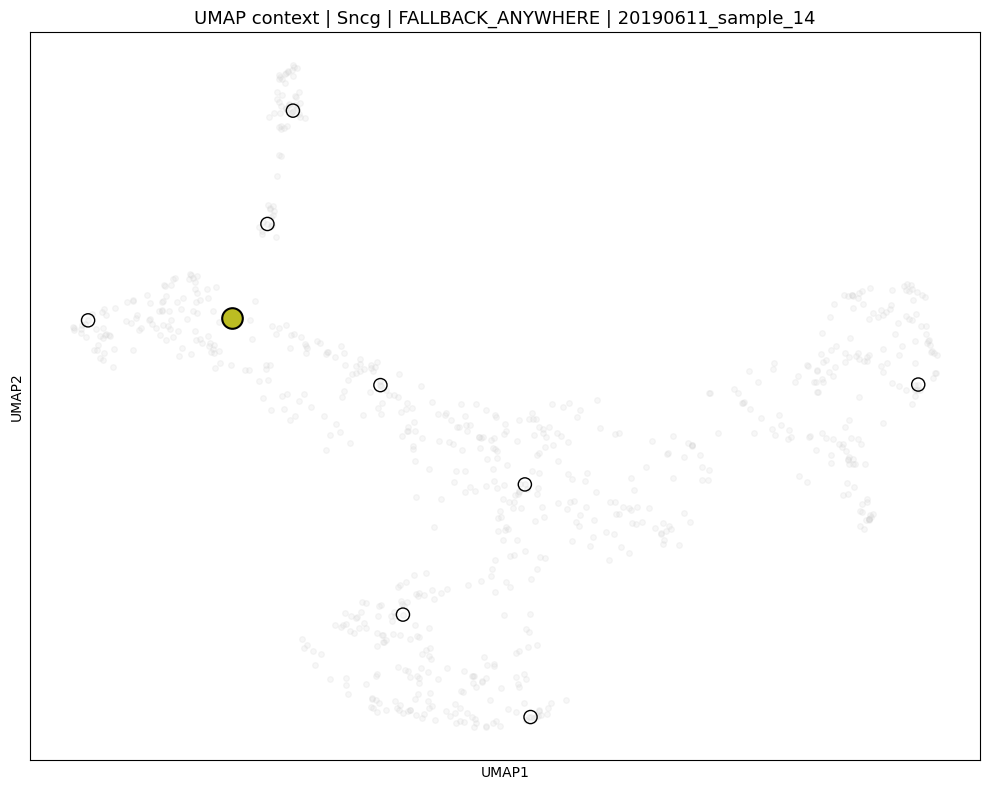

Saved: /content/umap_selected_cells_plots/Sncg/FALLBACK_ANYWHERE__20190611_sample_14/UMAP_selected_cell.png


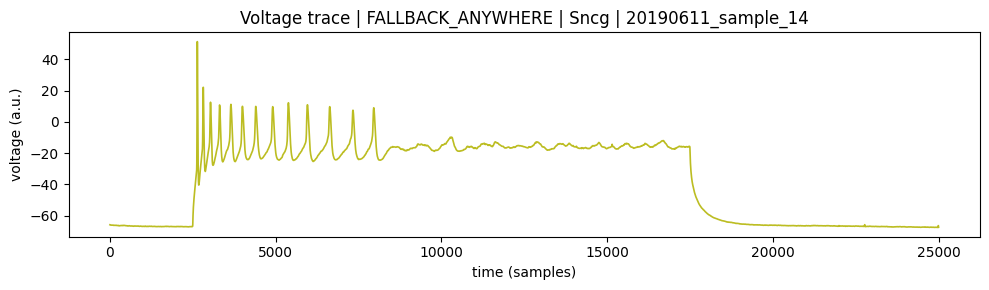

Saved: /content/umap_selected_cells_plots/Sncg/FALLBACK_ANYWHERE__20190611_sample_14/voltage.png


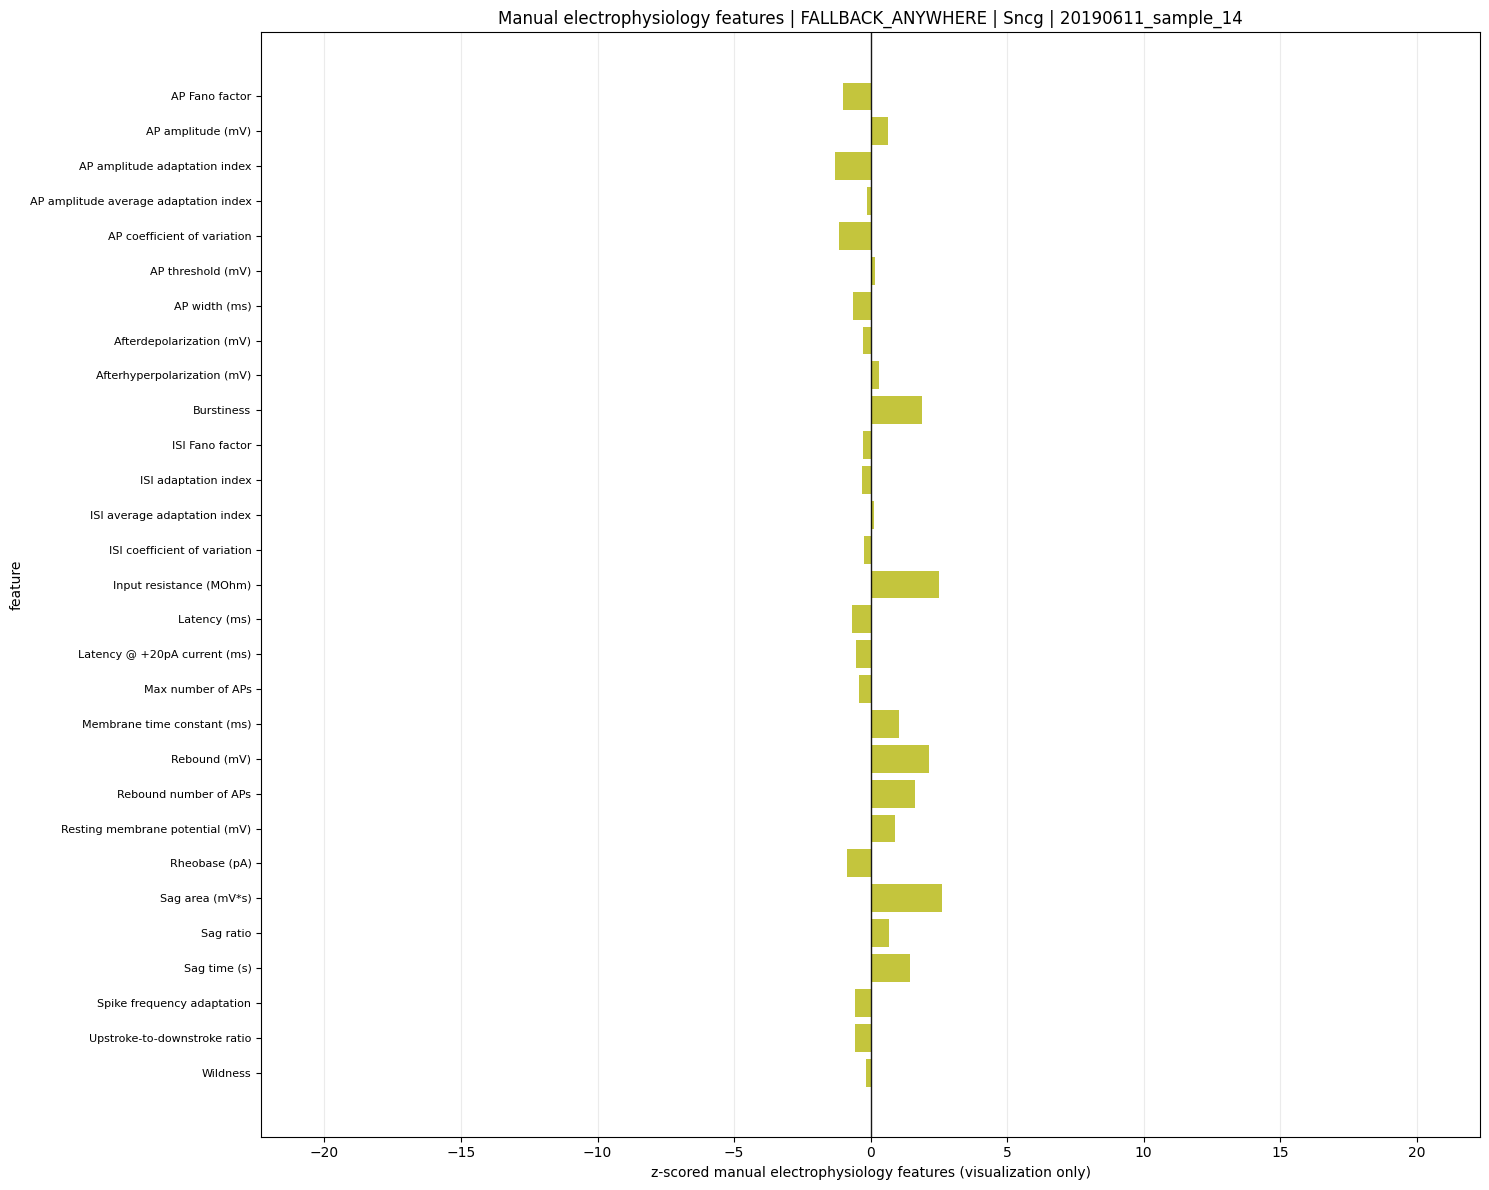

Saved: /content/umap_selected_cells_plots/Sncg/FALLBACK_ANYWHERE__20190611_sample_14/EPHYS_all_features_zscore.png


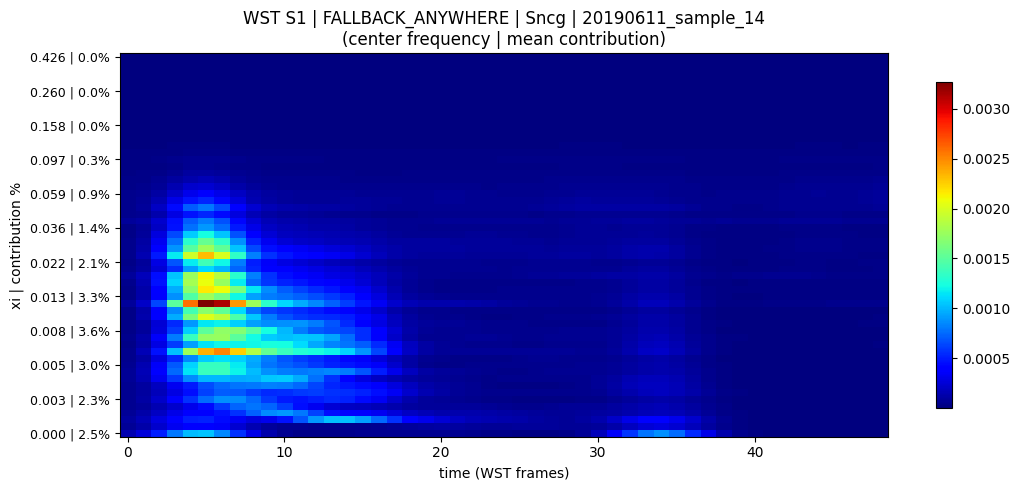

Saved: /content/umap_selected_cells_plots/Sncg/FALLBACK_ANYWHERE__20190611_sample_14/WST_S1.png


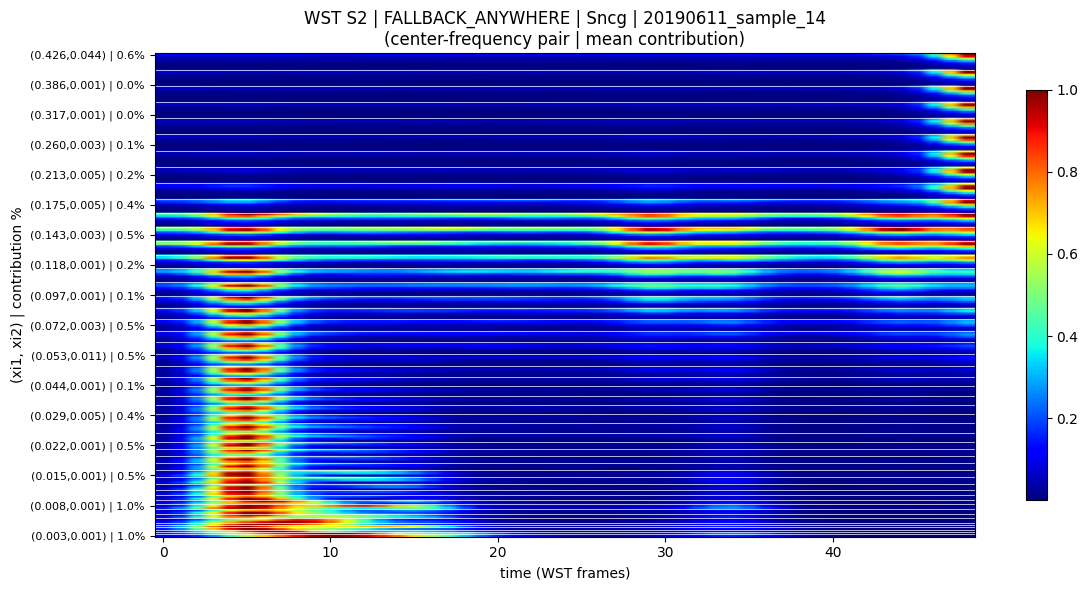

Saved: /content/umap_selected_cells_plots/Sncg/FALLBACK_ANYWHERE__20190611_sample_14/WST_S2.png
Completed cell folder: /content/umap_selected_cells_plots/Sncg/FALLBACK_ANYWHERE__20190611_sample_14

Pipeline completed successfully.
Root output folder: /content/umap_selected_cells_plots
Root files: ['UMAP_by_RNA_family.png', 'UMAP_selected_representatives.png', 'selected_representatives.csv']
Family directories: ['CT', 'ET', 'IT', 'Lamp5', 'NP', 'Pvalb', 'Sncg', 'Sst', 'Vip']


In [16]:
# ============================================================
# REPRESENTATIVE-CELL PIPELINE
# ============================================================
# Purpose
# -------
# 1) Build a UMAP from concatenated WST features (S1 + S2)
# 2) Merge WST embedding with RNA-family metadata
# 3) Intersect with manually extracted electrophysiology features
# 4) Select representative cells using local UMAP composition
# 5) For each selected cell:
#       - show/save UMAP context
#       - show/save raw voltage trace
#       - show/save one unified bar chart of manual ephys features
#       - show/save WST S1 heatmap
#       - show/save WST S2 heatmap
#
# Requested visualization changes
# -------------------------------
# - Every figure is both saved to disk and displayed inline
# - Manual ephys features are shown in ONE bar chart
# - Z-score is applied ONLY for visualizing that bar chart
# - All representatives use the same figure size, same feature order,
#   and same x-axis range for the bar chart
# - The same color is used across:
#       selected UMAP point
#       voltage trace
#       ephys bar chart
# ============================================================

import os
import re
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap

# ============================================================
# PATH CONFIGURATION
# ============================================================
CSV_WST_TRACES = "voltage___traces2345.csv"               # time x cells
NPZ_WST        = "/content/GPU_WST_S1S2_both.npz"         # names, S1, S2, xi1, xi_pairs
META_PATH      = "/content/m1_patchseq_meta_data (1).csv" # tab-delimited
EPHYS_PATH     = "/content/m1_patchseq_ephys_features.csv"
OUTDIR         = "/content/umap_selected_cells_plots"

# ============================================================
# OUTPUT / DISPLAY OPTIONS
# ============================================================
SHOW_PLOTS = True
SAVE_DPI   = 240
CLEAN_OUTDIR = False

# ============================================================
# UMAP CONFIGURATION
# ============================================================
N_NEIGHBORS = 25
MIN_DIST    = 0.10
RANDOM_SEED = 42

# ============================================================
# REPRESENTATIVE-SELECTION CONFIGURATION
# ============================================================
MAX_REPS   = 9
GRID_BINS  = 20

# Pure-bin criteria
PURITY_THR         = 0.80
MIN_BIN_COUNT_BASE = 6
MIN_BIN_COUNT_PURE = 10
MAX_PURE_FAMILIES  = 6

# Mixed-bin criteria
MIN_BIN_COUNT_MIXED = 14
MIXED_MAX_FRAC      = 0.65
MIN_FAM_IN_MIXED    = 4

# Spatial diversity on UMAP
MIN_DIST_FRAC_OF_RANGE = 0.10

# ============================================================
# WST AXIS LABEL CONFIGURATION
# ============================================================
S1_YTICKS_TARGET   = 10
S2_YTICKS_TARGET   = 15
LABEL_DECIMALS_XI  = 3
LABEL_DECIMALS_PCT = 1

# ============================================================
# EPHYS BAR-CHART CONFIGURATION
# ============================================================
EPHYS_FIGSIZE         = (15, 12)
EPHYS_LABEL_FONTSIZE  = 8
EPHYS_TITLE_FONTSIZE  = 12
EPHYS_GRID_ALPHA      = 0.25

# ============================================================
# OUTPUT DIRECTORY INITIALIZATION
# ============================================================
if CLEAN_OUTDIR and os.path.exists(OUTDIR):
    shutil.rmtree(OUTDIR)
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def finalize_figure(fig, output_path, show=SHOW_PLOTS, dpi=SAVE_DPI):
    """
    Save a matplotlib figure and optionally display it inline.
    """
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    print(f"Saved: {output_path}")


def wst_to_key(name: str):
    """
    Convert WST/NWB-style long cell name into canonical short_id.

    Example
    -------
    sub-..._ses-20190516-sample-5_...  ->  20190516_sample_5
    """
    if not isinstance(name, str):
        return None
    match = re.search(r"ses-(\d+)-sample-(\d+)", name.strip())
    if match:
        return f"{match.group(1)}_sample_{match.group(2)}"
    return None


def ephys_to_key(name: str):
    """
    Convert ephys feature cell ID into canonical short_id.

    Example
    -------
    20190516_sample_5  ->  20190516_sample_5
    """
    if not isinstance(name, str):
        return None
    match = re.search(r"(\d+)_sample_(\d+)", name.strip())
    if match:
        return f"{match.group(1)}_sample_{match.group(2)}"
    return None


def meta_to_key(cell_short: str):
    """
    Convert metadata Cell field into the same canonical key space.
    """
    return ephys_to_key(cell_short)


def safe_has_everything(row, name_to_trace, name_to_idx, ephys_row_by_key):
    """
    Check whether a representative cell has:
    - raw voltage trace
    - WST S1/S2 entry
    - manual ephys-feature row
    """
    sid = row["short_id"]
    wst_name = row["wst_name"]
    return (
        sid in ephys_row_by_key and
        wst_name in name_to_trace and
        wst_name in name_to_idx
    )


def shannon_entropy(counts):
    """
    Compute Shannon entropy from a vector of counts.
    """
    counts = np.asarray(counts, dtype=float)
    if counts.sum() <= 0:
        return 0.0
    p = counts / counts.sum()
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())


def pick_rep_near_centroid(df_sub, cx, cy):
    """
    Pick the cell closest to a local bin centroid in UMAP space.
    """
    d2 = (df_sub["UMAP1"].values - cx) ** 2 + (df_sub["UMAP2"].values - cy) ** 2
    return df_sub.iloc[int(np.argmin(d2))]


def min_dist_to_set(xy, chosen_xy):
    """
    Minimum Euclidean distance from one point to a set of selected points.
    """
    if len(chosen_xy) == 0:
        return np.inf
    delta = chosen_xy - xy[None, :]
    d2 = (delta ** 2).sum(axis=1)
    return float(np.sqrt(d2.min()))


def ensure_family_cell_folder(base_outdir, family_name, pick_type, short_id):
    """
    Create a clean output folder:
        OUTDIR/<RNA_family>/<pick_type>__<short_id>/
    """
    safe_family = re.sub(r"[^\w\-_\.]+", "_", str(family_name))
    safe_cell   = re.sub(r"[^\w\-_\.]+", "_", f"{pick_type}__{short_id}")

    family_dir = os.path.join(base_outdir, safe_family)
    cell_dir   = os.path.join(family_dir, safe_cell)

    os.makedirs(cell_dir, exist_ok=True)
    return family_dir, cell_dir


def contrib_percent_per_path(matrix_2d):
    """
    Compute average absolute contribution per scattering path,
    then convert to percentages.

    Input
    -----
    matrix_2d : shape (n_paths, n_time_frames)
    """
    contrib = np.mean(np.abs(matrix_2d), axis=1)
    total = float(contrib.sum())
    pct = (contrib / total * 100.0) if total > 0 else np.zeros_like(contrib)
    return contrib, pct


def compute_global_feature_zscores(df_numeric, feature_order):
    """
    Compute global per-feature z-scores across all common cells.
    These are used ONLY for visualization, not for selection.
    """
    mu = df_numeric[feature_order].mean(axis=0)
    sd = df_numeric[feature_order].std(axis=0)
    sd = sd.replace(0, np.nan)

    z = (df_numeric[feature_order] - mu) / sd
    z = z.fillna(0.0)
    return z


def plot_manual_feature_bar_chart(
    zscore_row,
    feature_order,
    bar_color,
    title_text,
    output_path,
    xlim_fixed
):
    """
    Plot one unified manual-feature bar chart for a single representative cell.

    Notes
    -----
    - Values are z-scored only for visualization.
    - Feature order is fixed globally.
    - Figure size and x-axis limits are fixed across cells.
    """
    y_pos = np.arange(len(feature_order))
    values = zscore_row[feature_order].astype(float).values

    fig, ax = plt.subplots(figsize=EPHYS_FIGSIZE)

    ax.barh(y_pos, values, color=bar_color, alpha=0.88)
    ax.axvline(0, color="black", linewidth=1.0, alpha=0.9)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(feature_order, fontsize=EPHYS_LABEL_FONTSIZE)
    ax.invert_yaxis()

    ax.set_xlim(xlim_fixed)
    ax.grid(axis="x", alpha=EPHYS_GRID_ALPHA)

    ax.set_title(title_text, fontsize=EPHYS_TITLE_FONTSIZE)
    ax.set_xlabel("z-scored manual electrophysiology features (visualization only)")
    ax.set_ylabel("feature")

    plt.tight_layout()
    finalize_figure(fig, output_path)


def plot_selected_cell_umap_context(
    merged_common,
    selected_df,
    row,
    point_color,
    output_path
):
    """
    Plot global UMAP in gray with all selected reps highlighted,
    and the current cell emphasized more strongly.
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    ax.scatter(
        merged_common["UMAP1"],
        merged_common["UMAP2"],
        s=16,
        alpha=0.18,
        color="lightgray"
    )

    for _, rr in selected_df.iterrows():
        sid = rr["short_id"]
        c = point_color if sid == row["short_id"] else "white"
        ec = "black"
        lw = 1.4 if sid == row["short_id"] else 1.0
        size = 180 if sid == row["short_id"] else 90

        ax.scatter(
            rr["UMAP1"],
            rr["UMAP2"],
            s=size,
            color=c if sid == row["short_id"] else "none",
            edgecolor=ec,
            linewidth=lw
        )

    ax.scatter(
        row["UMAP1"],
        row["UMAP2"],
        s=220,
        color=point_color,
        edgecolor="black",
        linewidth=1.5,
        zorder=5
    )

    ax.set_title(
        f"UMAP context | {row['RNA_family']} | {row['pick_type']} | {row['short_id']}",
        fontsize=13
    )
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    finalize_figure(fig, output_path)


# ============================================================
# 1) LOAD RAW VOLTAGE TRACES
# ============================================================
df_traces = pd.read_csv(CSV_WST_TRACES)

wst_trace_names = df_traces.columns[1:].astype(str).values
time_vector = df_traces.iloc[:, 0].values
trace_matrix = df_traces.iloc[:, 1:].to_numpy(dtype=np.float32)  # shape: (T, N)

name_to_trace = {
    cell_name: trace_matrix[:, i]
    for i, cell_name in enumerate(wst_trace_names)
}

print("Number of voltage traces:", len(wst_trace_names))

# ============================================================
# 2) LOAD WST FEATURES AND BUILD UMAP FROM S1 + S2
# ============================================================
npz = np.load(NPZ_WST, allow_pickle=True)

required_keys = {"S1", "S2", "names", "xi1", "xi_pairs"}
missing_keys = [k for k in required_keys if k not in npz.files]
if missing_keys:
    raise ValueError(
        f"NPZ file is missing keys: {missing_keys}. "
        f"Recreate the NPZ with names, S1, S2, xi1, and xi_pairs."
    )

S1 = npz["S1"]                       # (N, n1, T1)
S2 = npz["S2"]                       # (N, n2, T2)
wst_names_npz = npz["names"].astype(str)
xi1_sorted = npz["xi1"]              # (n1,)
xi_pairs_sorted = npz["xi_pairs"]    # (n2, 2)

print("Loaded WST data:")
print("  S1 shape:", S1.shape)
print("  S2 shape:", S2.shape)
print("  names   :", wst_names_npz.shape)
print("  xi1     :", xi1_sorted.shape)
print("  xi_pairs:", xi_pairs_sorted.shape)

name_to_idx = {name: i for i, name in enumerate(wst_names_npz)}

# S2 block separators based on parent frequency change
parent_change_rows = np.where(np.diff(xi_pairs_sorted[:, 0]) != 0)[0] + 1

# Concatenate flattened S1 and S2
N_cells = S1.shape[0]
flat_S1 = S1.reshape(N_cells, -1)
flat_S2 = S2.reshape(N_cells, -1)
wst_concat = np.concatenate([flat_S1, flat_S2], axis=1)

# Standardize before UMAP
wst_concat_std = StandardScaler().fit_transform(wst_concat)

# UMAP embedding
reducer = umap.UMAP(
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    n_components=2,
    random_state=RANDOM_SEED
)
embedding = reducer.fit_transform(wst_concat_std)

df_umap = pd.DataFrame({
    "wst_name": wst_names_npz,
    "short_id": [wst_to_key(n) for n in wst_names_npz],
    "UMAP1": embedding[:, 0],
    "UMAP2": embedding[:, 1],
})

print("UMAP embedding shape:", embedding.shape)

# ============================================================
# 3) LOAD RNA-FAMILY METADATA AND MERGE
# ============================================================
meta = pd.read_csv(META_PATH, sep="\t")

if "Cell" not in meta.columns:
    raise ValueError("Metadata file must contain a 'Cell' column.")

meta = meta.rename(columns={"Cell": "short_id"})
meta["short_id"] = meta["short_id"].astype(str).str.strip().apply(meta_to_key)

rna_family_col = None
for col in meta.columns:
    if col.strip().lower().replace(" ", "") == "rnafamily":
        rna_family_col = col
        break

if rna_family_col is None:
    raise ValueError("Could not find an 'RNA family' column in metadata.")

meta = meta[["short_id", rna_family_col]].rename(columns={rna_family_col: "RNA_family"})

merged = df_umap.merge(meta, on="short_id", how="left")
print("Merged UMAP + RNA metadata:", merged.shape)
print("Unlabeled cells:", merged["RNA_family"].isna().sum())

# ============================================================
# 4) LOAD MANUAL EPHYS FEATURES AND INTERSECT WITH WST
# ============================================================
ephys = pd.read_csv(EPHYS_PATH)

if "cell id" not in ephys.columns:
    raise ValueError("EPHYS file must contain a 'cell id' column.")

ephys["cell id"] = ephys["cell id"].astype(str).str.strip()
ephys["short_id"] = ephys["cell id"].apply(ephys_to_key)
ephys = ephys.loc[ephys["short_id"].notna()].reset_index(drop=True)

merged_valid = merged.loc[merged["short_id"].notna()].reset_index(drop=True)

common_keys = np.intersect1d(
    merged_valid["short_id"].values,
    ephys["short_id"].values
)

print("Common cells between WST and manual ephys:", len(common_keys))
if len(common_keys) == 0:
    raise RuntimeError("No overlap found between WST and ephys tables after key matching.")

merged_common = merged_valid.loc[merged_valid["short_id"].isin(common_keys)].reset_index(drop=True)
ephys_common = ephys.loc[ephys["short_id"].isin(common_keys)].reset_index(drop=True)

ephys_row_by_key = {
    sid: idx for idx, sid in enumerate(ephys_common["short_id"].values)
}

# Keep only labeled cells
df_labeled = merged_common.loc[merged_common["RNA_family"].notna()].reset_index(drop=True)
print("Labeled common cells:", len(df_labeled))

# Require full availability: trace + WST + manual features
mask_full = df_labeled.apply(
    lambda row: safe_has_everything(row, name_to_trace, name_to_idx, ephys_row_by_key),
    axis=1
)
df_labeled = df_labeled.loc[mask_full.values].reset_index(drop=True)
print("Labeled common cells with all modalities:", len(df_labeled))

if len(df_labeled) == 0:
    raise RuntimeError("No cells remain after enforcing trace + WST + manual ephys availability.")

# ============================================================
# 5) GLOBAL UMAP PLOT COLORED BY RNA FAMILY
# ============================================================
families = sorted(df_labeled["RNA_family"].astype(str).unique())

default_colors = plt.rcParams["axes.prop_cycle"].by_key().get(
    "color",
    ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9"]
)
family_to_color = {
    fam: default_colors[i % len(default_colors)]
    for i, fam in enumerate(families)
}

fig, ax = plt.subplots(figsize=(10, 8))
for fam in families:
    sub = df_labeled[df_labeled["RNA_family"].astype(str) == fam]
    ax.scatter(
        sub["UMAP1"],
        sub["UMAP2"],
        s=14,
        alpha=0.72,
        label=fam,
        color=family_to_color[fam]
    )

ax.set_title("UMAP colored by RNA family", fontsize=14)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_xticks([])
ax.set_yticks([])
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=True)

plt.tight_layout()
finalize_figure(fig, os.path.join(OUTDIR, "UMAP_by_RNA_family.png"))

# ============================================================
# 6) GRID-BASED LOCAL COMPOSITION ON UMAP
# ============================================================
x = df_labeled["UMAP1"].values
y = df_labeled["UMAP2"].values
fam = df_labeled["RNA_family"].astype(str).values

x_edges = np.linspace(x.min(), x.max(), GRID_BINS + 1)
y_edges = np.linspace(y.min(), y.max(), GRID_BINS + 1)

ix = np.clip(np.searchsorted(x_edges, x, side="right") - 1, 0, GRID_BINS - 1)
iy = np.clip(np.searchsorted(y_edges, y, side="right") - 1, 0, GRID_BINS - 1)

bin_map = {}
for i in range(len(df_labeled)):
    key = (int(ix[i]), int(iy[i]))
    bin_map.setdefault(key, []).append(i)

bin_rows = []
for (bx, by), indices in bin_map.items():
    n_bin = len(indices)
    if n_bin < MIN_BIN_COUNT_BASE:
        continue

    value_counts = pd.Series(fam[indices]).value_counts()
    dominant_family = str(value_counts.index[0])
    dominant_count = int(value_counts.iloc[0])
    purity = dominant_count / n_bin
    entropy = shannon_entropy(value_counts.values)
    cx = float(np.mean(x[indices]))
    cy = float(np.mean(y[indices]))

    bin_rows.append({
        "bx": bx,
        "by": by,
        "n": n_bin,
        "dom_family": dominant_family,
        "dom_count": dominant_count,
        "purity": purity,
        "entropy": entropy,
        "cx": cx,
        "cy": cy,
    })

bin_info = pd.DataFrame(bin_rows)
if len(bin_info) == 0:
    raise RuntimeError("No bins passed the minimum count threshold.")

all_families_present = sorted(df_labeled["RNA_family"].astype(str).unique())
family_totals = df_labeled["RNA_family"].astype(str).value_counts().to_dict()

umap_range = np.sqrt((x.max() - x.min()) ** 2 + (y.max() - y.min()) ** 2)
MIN_DIST_ABS = MIN_DIST_FRAC_OF_RANGE * umap_range

print("Families present:", all_families_present)
print("Minimum spatial separation on UMAP:", MIN_DIST_ABS)

# ============================================================
# 7) REPRESENTATIVE SELECTION
# ============================================================
selected = []
selected_families = set()
selected_short_ids = set()
chosen_xy = np.zeros((0, 2), dtype=float)

# ------------------------------------------------------------
# 7A) PURE-BIN REPRESENTATIVES
# ------------------------------------------------------------
pure_candidates = []

for family_name in all_families_present:
    total_count = family_totals.get(family_name, 0)
    min_count_this_family = MIN_BIN_COUNT_PURE if total_count >= 20 else MIN_BIN_COUNT_BASE

    df_bins = bin_info[
        (bin_info["dom_family"] == family_name) &
        (bin_info["purity"] >= PURITY_THR) &
        (bin_info["n"] >= min_count_this_family)
    ].copy()

    if len(df_bins) == 0:
        continue

    df_bins["score"] = df_bins["purity"] * np.sqrt(df_bins["n"]) * df_bins["dom_count"]
    best_bin = df_bins.sort_values("score", ascending=False).iloc[0]
    pure_candidates.append(best_bin)

pure_candidates = pd.DataFrame(pure_candidates)

if len(pure_candidates) > 0:
    pure_candidates = pure_candidates.sort_values("score", ascending=False)

    for _, bin_row in pure_candidates.iterrows():
        if len(selected) >= MAX_PURE_FAMILIES:
            break

        family_name = str(bin_row["dom_family"])
        if family_name in selected_families:
            continue

        indices = bin_map[(int(bin_row["bx"]), int(bin_row["by"]))]
        sub = df_labeled.iloc[indices].copy()
        sub = sub[sub["RNA_family"].astype(str) == family_name]

        if len(sub) == 0:
            continue

        rep = pick_rep_near_centroid(sub, float(bin_row["cx"]), float(bin_row["cy"]))
        if not safe_has_everything(rep, name_to_trace, name_to_idx, ephys_row_by_key):
            continue

        xy = np.array([rep["UMAP1"], rep["UMAP2"]], dtype=float)

        if len(chosen_xy) > 0 and min_dist_to_set(xy, chosen_xy) < MIN_DIST_ABS:
            d2 = (sub["UMAP1"].values - float(bin_row["cx"])) ** 2 + (sub["UMAP2"].values - float(bin_row["cy"])) ** 2
            order = np.argsort(d2)

            replacement = None
            for j in order:
                candidate = sub.iloc[int(j)]
                xy_candidate = np.array([candidate["UMAP1"], candidate["UMAP2"]], dtype=float)
                if min_dist_to_set(xy_candidate, chosen_xy) >= MIN_DIST_ABS:
                    replacement = candidate
                    xy = xy_candidate
                    break

            if replacement is not None:
                rep = replacement

        sid = rep["short_id"]
        if sid in selected_short_ids:
            continue

        rep = rep.copy()
        rep["pick_type"] = "PURE_BIN"
        rep["bin_purity"] = float(bin_row["purity"])
        rep["bin_n"] = int(bin_row["n"])
        rep["bin_entropy"] = float(bin_row["entropy"])

        selected.append(rep)
        selected_families.add(family_name)
        selected_short_ids.add(sid)
        chosen_xy = np.vstack([chosen_xy, xy[None, :]])

# ------------------------------------------------------------
# 7B) MIXED-BIN REPRESENTATIVES
# ------------------------------------------------------------
families_not_selected = [f for f in all_families_present if f not in selected_families]

mixed_bins = bin_info[
    (bin_info["n"] >= MIN_BIN_COUNT_MIXED) &
    (bin_info["purity"] <= MIXED_MAX_FRAC)
].copy()

if len(mixed_bins) > 0:
    mixed_bins["mixed_score"] = mixed_bins["entropy"] * np.sqrt(mixed_bins["n"])
    mixed_bins = mixed_bins.sort_values("mixed_score", ascending=False)

def best_mixed_bin_for_family(df_pool, mixed_bin_table, bin_lookup, family_name):
    best_row = None
    best_score = -np.inf

    for _, row in mixed_bin_table.iterrows():
        indices = bin_lookup[(int(row["bx"]), int(row["by"]))]
        sub_pool = df_pool.iloc[indices]
        count_family = int((sub_pool["RNA_family"].astype(str) == family_name).sum())

        if count_family < MIN_FAM_IN_MIXED:
            continue

        score = count_family * float(row["mixed_score"])
        if score > best_score:
            best_score = score
            best_row = row

    return best_row, best_score

for family_name in families_not_selected:
    if len(selected) >= MAX_REPS:
        break
    if len(mixed_bins) == 0:
        break

    chosen_bin, _ = best_mixed_bin_for_family(df_labeled, mixed_bins, bin_map, family_name)
    if chosen_bin is None:
        continue

    indices = bin_map[(int(chosen_bin["bx"]), int(chosen_bin["by"]))]
    sub = df_labeled.iloc[indices].copy()
    sub = sub[sub["RNA_family"].astype(str) == family_name]

    if len(sub) == 0:
        continue

    rep0 = pick_rep_near_centroid(sub, float(chosen_bin["cx"]), float(chosen_bin["cy"]))
    xy0 = np.array([rep0["UMAP1"], rep0["UMAP2"]], dtype=float)

    if len(chosen_xy) > 0 and min_dist_to_set(xy0, chosen_xy) < MIN_DIST_ABS:
        sub_xy = sub[["UMAP1", "UMAP2"]].to_numpy(float)
        dmins = np.array([min_dist_to_set(sub_xy[i], chosen_xy) for i in range(len(sub))])
        j_best = int(np.argmax(dmins))
        rep = sub.iloc[j_best]
        xy = sub_xy[j_best]
    else:
        rep = rep0
        xy = xy0

    if not safe_has_everything(rep, name_to_trace, name_to_idx, ephys_row_by_key):
        continue

    sid = rep["short_id"]
    if sid in selected_short_ids:
        continue

    rep = rep.copy()
    rep["pick_type"] = "MIXED_BIN"
    rep["bin_purity"] = float(chosen_bin["purity"])
    rep["bin_n"] = int(chosen_bin["n"])
    rep["bin_entropy"] = float(chosen_bin["entropy"])

    selected.append(rep)
    selected_families.add(family_name)
    selected_short_ids.add(sid)
    chosen_xy = np.vstack([chosen_xy, xy[None, :]])

# ------------------------------------------------------------
# 7C) FALLBACK REPRESENTATIVES
# ------------------------------------------------------------
if len(selected) < min(MAX_REPS, len(all_families_present)):
    remaining_families = [f for f in all_families_present if f not in selected_families]

    for family_name in remaining_families:
        if len(selected) >= MAX_REPS:
            break

        sub = df_labeled[df_labeled["RNA_family"].astype(str) == family_name].copy()
        if len(sub) == 0:
            continue

        sub_xy = sub[["UMAP1", "UMAP2"]].to_numpy(float)

        if len(chosen_xy) > 0:
            dmins = np.array([min_dist_to_set(sub_xy[i], chosen_xy) for i in range(len(sub))])
            j_best = int(np.argmax(dmins))
            rep = sub.iloc[j_best]
            xy = sub_xy[j_best]
        else:
            rep = sub.iloc[0]
            xy = sub_xy[0]

        sid = rep["short_id"]
        if sid in selected_short_ids:
            continue

        rep = rep.copy()
        rep["pick_type"] = "FALLBACK_ANYWHERE"
        rep["bin_purity"] = np.nan
        rep["bin_n"] = np.nan
        rep["bin_entropy"] = np.nan

        selected.append(rep)
        selected_families.add(family_name)
        selected_short_ids.add(sid)
        chosen_xy = np.vstack([chosen_xy, xy[None, :]])

if len(selected) == 0:
    raise RuntimeError("Selection ended empty. Relax thresholds or verify data consistency.")

selected_df = pd.DataFrame(selected).reset_index(drop=True)

if len(selected_df) > MAX_REPS:
    rank_map = {"PURE_BIN": 0, "MIXED_BIN": 1, "FALLBACK_ANYWHERE": 2}
    selected_df["_rank"] = selected_df["pick_type"].map(rank_map).fillna(9)
    selected_df = (
        selected_df
        .sort_values(["_rank", "bin_n"], ascending=[True, False])
        .head(MAX_REPS)
        .drop(columns=["_rank"])
        .reset_index(drop=True)
    )

print("\nSelected representatives:")
print(
    selected_df[
        ["pick_type", "RNA_family", "short_id", "wst_name", "UMAP1", "UMAP2", "bin_purity", "bin_n", "bin_entropy"]
    ]
)

selected_df.to_csv(os.path.join(OUTDIR, "selected_representatives.csv"), index=False)

# ============================================================
# 8) ASSIGN A CONSISTENT COLOR TO EACH SELECTED CELL
# ============================================================
selected_colors = {
    sid: default_colors[i % len(default_colors)]
    for i, sid in enumerate(selected_df["short_id"].values)
}

# ============================================================
# 9) GLOBAL UMAP: ALL CELLS GRAY, SELECTED REPS COLORED
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    merged_common["UMAP1"],
    merged_common["UMAP2"],
    s=18,
    alpha=0.20,
    color="lightgray"
)

for _, row in selected_df.iterrows():
    sid = row["short_id"]
    label = f"{row['RNA_family']} | {row['pick_type']} | {sid}"

    ax.scatter(
        row["UMAP1"],
        row["UMAP2"],
        s=150,
        color=selected_colors[sid],
        edgecolor="black",
        linewidth=1.2,
        label=label
    )

ax.set_title("UMAP with selected representative cells", fontsize=14)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_xticks([])
ax.set_yticks([])
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=True)

plt.tight_layout()
finalize_figure(fig, os.path.join(OUTDIR, "UMAP_selected_representatives.png"))

# ============================================================
# 10) PREPARE GLOBAL MANUAL-FEATURE VISUALIZATION MATRIX
# ============================================================
exclude_cols = {"cell id", "short_id", "wst_name"}
manual_numeric_features = [
    col for col in ephys_common.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(ephys_common[col])
]

print("\nNumber of numeric manual ephys features:", len(manual_numeric_features))

if len(manual_numeric_features) == 0:
    raise RuntimeError("No numeric manual ephys features were found.")

# Keep feature order fixed exactly as present in the original ephys table
feature_order = manual_numeric_features.copy()

# Compute global z-scores across all common cells
ephys_numeric_common = ephys_common[feature_order].astype(float).copy()
ephys_zscore_matrix = compute_global_feature_zscores(ephys_numeric_common, feature_order)

# Append short_id for direct row lookup
ephys_zscore_matrix = ephys_zscore_matrix.copy()
ephys_zscore_matrix["short_id"] = ephys_common["short_id"].values
ephys_zscore_by_key = {
    sid: i for i, sid in enumerate(ephys_zscore_matrix["short_id"].values)
}

# Fixed x-axis range across all representative bar charts
all_z_values = ephys_zscore_matrix[feature_order].to_numpy(dtype=float).ravel()
z_abs_max = np.nanmax(np.abs(all_z_values))
if not np.isfinite(z_abs_max) or z_abs_max == 0:
    z_abs_max = 1.0
EPHYS_XLIM = (-1.05 * z_abs_max, 1.05 * z_abs_max)

print("Fixed x-axis range for manual-feature bar charts:", EPHYS_XLIM)

# ============================================================
# 11) PER-REPRESENTATIVE FIGURES
# ============================================================
for _, row in selected_df.iterrows():
    short_id = row["short_id"]
    family_name = str(row["RNA_family"])
    wst_name = row["wst_name"]
    pick_type = row["pick_type"]
    cell_color = selected_colors[short_id]

    _, cell_dir = ensure_family_cell_folder(
        OUTDIR,
        family_name,
        pick_type,
        short_id
    )

    # --------------------------------------------------------
    # 11A) UMAP CONTEXT FOR THIS SPECIFIC CELL
    # --------------------------------------------------------
    umap_context_path = os.path.join(cell_dir, "UMAP_selected_cell.png")
    plot_selected_cell_umap_context(
        merged_common=merged_common,
        selected_df=selected_df,
        row=row,
        point_color=cell_color,
        output_path=umap_context_path
    )

    # --------------------------------------------------------
    # 11B) RAW VOLTAGE TRACE
    # --------------------------------------------------------
    voltage_trace = name_to_trace[wst_name]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(time_vector, voltage_trace, linewidth=1.2, color=cell_color)

    ax.set_title(
        f"Voltage trace | {pick_type} | {family_name} | {short_id}",
        fontsize=12
    )
    ax.set_xlabel("time (samples)")
    ax.set_ylabel("voltage (a.u.)")

    plt.tight_layout()
    finalize_figure(fig, os.path.join(cell_dir, "voltage.png"))

    # --------------------------------------------------------
    # 11C) MANUAL EPHYS FEATURES — ONE UNIFIED BAR CHART
    # --------------------------------------------------------
    z_idx = ephys_zscore_by_key[short_id]
    z_row = ephys_zscore_matrix.iloc[z_idx]

    ephys_bar_title = (
        f"Manual electrophysiology features | {pick_type} | {family_name} | {short_id}"
    )

    plot_manual_feature_bar_chart(
        zscore_row=z_row,
        feature_order=feature_order,
        bar_color=cell_color,
        title_text=ephys_bar_title,
        output_path=os.path.join(cell_dir, "EPHYS_all_features_zscore.png"),
        xlim_fixed=EPHYS_XLIM
    )

    # --------------------------------------------------------
    # 11D) WST S1 HEATMAP
    # --------------------------------------------------------
    wst_index = name_to_idx[wst_name]
    S1_i = S1[wst_index]
    _, pct_s1 = contrib_percent_per_path(S1_i)

    fig, ax = plt.subplots(figsize=(11, 5))
    im = ax.imshow(S1_i, aspect="auto", origin="upper", cmap="jet")

    n_paths_s1 = S1_i.shape[0]
    step_s1 = max(1, n_paths_s1 // S1_YTICKS_TARGET)
    tick_pos_s1 = np.arange(0, n_paths_s1, step_s1)

    tick_labels_s1 = [
        f"{xi1_sorted[p]:.{LABEL_DECIMALS_XI}f} | {pct_s1[p]:.{LABEL_DECIMALS_PCT}f}%"
        for p in tick_pos_s1
    ]

    ax.set_yticks(tick_pos_s1)
    ax.set_yticklabels(tick_labels_s1, fontsize=9)

    ax.set_title(
        f"WST S1 | {pick_type} | {family_name} | {short_id}\n"
        f"(center frequency | mean contribution)",
        fontsize=12
    )
    ax.set_xlabel("time (WST frames)")
    ax.set_ylabel("xi | contribution %")

    plt.colorbar(im, ax=ax, shrink=0.85)
    plt.tight_layout()
    finalize_figure(fig, os.path.join(cell_dir, "WST_S1.png"))

    # --------------------------------------------------------
    # 11E) WST S2 HEATMAP
    # --------------------------------------------------------
    S2_i = S2[wst_index].copy()

    # Normalize each parent block for visual readability only
    start = 0
    for break_row in list(parent_change_rows) + [S2_i.shape[0]]:
        block = S2_i[start:break_row]
        block_max = np.max(block)
        if block_max > 0:
            S2_i[start:break_row] = block / block_max
        start = break_row

    _, pct_s2 = contrib_percent_per_path(S2_i)

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(S2_i, aspect="auto", origin="upper", cmap="jet")

    for rr in parent_change_rows:
        ax.axhline(y=rr - 0.5, color="white", linewidth=0.5)

    n_paths_s2 = S2_i.shape[0]
    step_s2 = max(1, n_paths_s2 // S2_YTICKS_TARGET)
    tick_pos_s2 = np.arange(0, n_paths_s2, step_s2)

    tick_labels_s2 = [
        (
            f"({xi_pairs_sorted[r, 0]:.{LABEL_DECIMALS_XI}f},"
            f"{xi_pairs_sorted[r, 1]:.{LABEL_DECIMALS_XI}f})"
            f" | {pct_s2[r]:.{LABEL_DECIMALS_PCT}f}%"
        )
        for r in tick_pos_s2
    ]

    ax.set_yticks(tick_pos_s2)
    ax.set_yticklabels(tick_labels_s2, fontsize=8)

    ax.set_title(
        f"WST S2 | {pick_type} | {family_name} | {short_id}\n"
        f"(center-frequency pair | mean contribution)",
        fontsize=12
    )
    ax.set_xlabel("time (WST frames)")
    ax.set_ylabel("(xi1, xi2) | contribution %")

    plt.colorbar(im, ax=ax, shrink=0.85)
    plt.tight_layout()
    finalize_figure(fig, os.path.join(cell_dir, "WST_S2.png"))

    print(f"Completed cell folder: {cell_dir}")

# ============================================================
# 12) FINAL SUMMARY
# ============================================================
print("\nPipeline completed successfully.")
print("Root output folder:", OUTDIR)

root_files = [
    f for f in sorted(os.listdir(OUTDIR))
    if os.path.isfile(os.path.join(OUTDIR, f))
]
family_dirs = [
    d for d in sorted(os.listdir(OUTDIR))
    if os.path.isdir(os.path.join(OUTDIR, d))
]

print("Root files:", root_files)
print("Family directories:", family_dirs[:20])